# Stage 1: DNA, RNA, and Protein Representation Analysis

This notebook investigates what pretrained DNA, RNA, and protein encoders represent and how their representations relate to one another. It runs on any dataset in the `mbf.datasets` registry with any set of encoders from the `mbf.encoders` registry. The saved run uses nucleotide sequences and mRNA stability labels from `mRNA_Stability.csv`, with eight encoders: two or three per modality.

Each retained coding sequence supplies one input per encoder: the sequence in DNA letters for a DNA encoder, the same sequence in RNA letters for an RNA encoder, and its translated amino acid sequence for a protein encoder. All encoders remain frozen during the analysis. Their parameters are not updated using the pilot dataset.

| Modality | Encoder | Pretraining data | Reason for inclusion |
|---|---|---|---|
| DNA | Nucleotide Transformer 500M human-ref | Human reference genome | Reference DNA encoder in `REFERENCE_KEYS` |
| DNA | Nucleotide Transformer v2 100M multi-species | Genomes of many species | DNA encoder in [BioLangFusion](../Papers/BioLangFusion.pdf), Table 3 |
| DNA | DNABERT-2 | Genomes of many species | Multi-species DNA encoder with byte-pair-encoding tokens |
| RNA | RNA-FM | Non-coding RNA sequences from RNAcentral | Reference RNA encoder; RNA encoder in BioLangFusion |
| RNA | mRNA-FM | Messenger RNA coding sequences | RNA-FM variant pretrained on messenger RNA, with one token per codon |
| Protein | ESM-2 8M | UniRef50 protein sequences | Protein encoder in BioLangFusion, Table 3 |
| Protein | ESM-2 35M | UniRef50 protein sequences | Reference protein encoder |
| Protein | ESM-2 150M | UniRef50 protein sequences | Protein encoder in [IsoFormer](../Papers/Multi-Modal-Transfer-Learning.pdf) |

The inputs are derived from one coding sequence, so they carry the same underlying sequence information. The comparison therefore examines how pretrained encoders, trained on different corpora with different tokenizers and at different sizes, represent related biological information. This follows the modality definition used by [BioLangFusion](../Papers/BioLangFusion.pdf), Section 2.1, which gives the same coding sequence to DNA, RNA, and protein language models. The dataset carries no gene or transcript identifiers, so genomic DNA around each gene, such as promoters or introns, is not available here.

The registry records each dataset's setting. This notebook supports the derived setting, in which every input comes from one coding sequence; datasets whose rows carry separate DNA, transcript, and protein sequences need a registry entry for that setting.

## Research questions

- **Track A: Decodability.** Which properties can simple predictive models recover from each encoder's embedding?
- **Track B: Cross-modal geometry.** How similarly do the embedding spaces organize the same examples, compared for every pair of encoders, including two encoders of the same modality, and how much of that agreement remains after removing sequence composition?
- **Track C: Attention and diagnostics.** How does the selected attention summary of the nucleotide encoders relate to matches for RNA stability-associated sequence patterns, and do sample-level alignment and representational similarity relate to one another and to prediction?

## Role in the project

Stage 1 characterizes the representations available from the frozen encoders. Its observations inform the subsequent definition of alignment, development of fusion methods, and evaluation against single-modality baselines. Two encoders of the same modality read the same input type, so their agreement is the reference against which agreement across modalities is read.

The analyses generate evidence and hypotheses for those later stages. Choosing an alignment objective or fusion architecture requires further controlled comparisons, such as the trained fusion architectures of BioLangFusion and IsoFormer on the same inputs.

**Running the notebook.** Use `Code/` as the working directory. The first run downloads the checkpoints into the Hugging Face cache (about 5 GB in total) and saves each encoder's embeddings under `stage1_embeddings/`. Later runs reuse a saved matrix when the sample, checkpoint, revision, and token limit are unchanged. Nucleotide Transformer v2 and DNABERT-2 ship model code written for an earlier version of Transformers; `mbf.encoders` applies the small compatibility changes they need and pins both to a fixed checkpoint revision. The analysis code lives in the `mbf` package in `Code/mbf/`; the cells that call `show_source` display the functions an explanation describes.

---

## Setup

### Imports

Imports are grouped by their role in the notebook. The analysis functions come from the shared `mbf` package, so every result is computed with one implementation.

In [2]:
# Standard library
import itertools
import os

# Data handling and pretrained encoders
import numpy as np
import pandas as pd
import torch

# Shared project code in Code/mbf
from mbf import analysis, datasets, embeddings, encoders, sequences, splits
from mbf.notebook import show_source

### Analysis settings

These settings identify the dataset, the encoders, and the sample limits used in the pilot. Relative file paths assume the notebook runs with `Code` as its working directory.

`DATASET` names an entry in the `mbf.datasets` registry, and `N_ROWS` controls the number of rows sampled before sequence filtering. The 1,000-row sample keeps the embedding workload manageable. Filtering can reduce the retained sample. `CONTROL_DATASET` names the synonymous-recoding control.

`ENCODER_KEYS` selects encoders from the `mbf.encoders` registry; its order (DNA, RNA, protein) sets the row and column order of every table. `REFERENCE_KEYS` names one encoder per modality, used for the one-per-modality concatenation and the layer-wise heatmaps.

`N_FOLD_ASSIGNMENTS` sets how many further grouped fold assignments each probe summarizes after its pinned assignment; see [Evaluation and interpretation](#Evaluation-and-interpretation).

The encoder input limits are measured in tokens and recorded in the registry; the table printed below lists them. The structural-proxy crop is measured in nucleotides. A token covers a different number of letters for each encoder: most Nucleotide Transformer tokens cover six nucleotides, DNABERT-2's byte-pair tokens cover a variable number, RNA-FM tokens cover one nucleotide, mRNA-FM tokens cover one codon, and ESM-2 tokens cover one amino acid. RNA-FM's limit of 1,024 tokens includes two special tokens, so it sees at most the first 1,022 nucleotides of a sequence.

RNA-FM and mRNA-FM load through the `multimolecule` package, which `encoders.load_encoder` imports so that their model classes are registered with Transformers. `multimolecule` 0.2.1 imports with `transformers` 5.14.1 and 5.15.1 but raises an error with 5.16 and later, so this notebook expects:

```sh
python -m pip install "transformers==5.15.1" multimolecule einops umap-learn
```

`DEVICE` selects a CUDA GPU when available, then an Apple Silicon GPU through PyTorch's MPS backend, and otherwise the CPU. This affects execution time, particularly for embedding extraction and attention analysis.

In [3]:
SEED = 42
torch.manual_seed(SEED)

# Dataset from the mbf.datasets registry, and the pilot sample size before filtering
DATASET = "mrna_stability"
N_ROWS = 1000

# Synonymous-recoding control dataset
CONTROL_DATASET = "mrfp_expression"

# Encoders from the mbf.encoders registry; this order sets the row and column order of every table
ENCODER_KEYS = [
    "nt500m", "ntv2_100m", "dnabert2",   # DNA
    "rnafm", "mrnafm",                   # RNA
    "esm2_8m", "esm2_35m", "esm2_150m",  # protein
]
ENCODERS = [encoders.ENCODERS[key] for key in ENCODER_KEYS]
LABELS = {e.key: e.label for e in ENCODERS}
MODALITY = {e.key: e.modality for e in ENCODERS}

# One encoder per modality, in ENCODER_KEYS order
REFERENCE_KEYS = ["nt500m", "rnafm", "esm2_35m"]

# Probe evaluation: further grouped fold assignments summarized after the pinned one
N_FOLD_ASSIGNMENTS = 10

# Additional analysis limits
LAYERWISE_N_ROWS = 200      # rows sampled before filtering
STRUCTURE_N_ROWS = 200      # retained rows
STRUCTURE_CROP_LEN = 200    # nucleotides
ATTENTION_N_ROWS = 100      # first retained rows

# Layer-wise CKA heatmaps to draw; every pair is summarized in a table
LAYERWISE_PLOT_PAIRS = list(itertools.combinations(REFERENCE_KEYS, 2))

# Nucleotide encoders for the attention analysis
ATTENTION_ENCODERS = [k for k in ENCODER_KEYS if MODALITY[k] in ("DNA", "RNA")]

# Saved embeddings, one folder per dataset sample
EMBEDDING_DIR = os.path.join("stage1_embeddings", f"{DATASET}_n{N_ROWS}_seed{SEED}")
CONTROL_EMBEDDING_DIR = os.path.join("stage1_embeddings", f"{CONTROL_DATASET}_n{N_ROWS}_seed{SEED}")

DEVICE = encoders.select_device()
print("Using device:", DEVICE)

pd.DataFrame(
    [
        {"encoder": e.label, "modality": e.modality, "checkpoint": e.checkpoint,
         "input": e.alphabet, "token limit": e.max_len, "revision": e.revision or "latest"}
        for e in ENCODERS
    ]
).set_index("encoder")

Using device: mps


,modality,checkpoint,input,token limit,revision
encoder,,,,,
NT 500M human-ref,DNA,InstaDeepAI/nucleotide-transformer-500m-human-ref,dna,1000,latest
NT v2 100M multi-species,DNA,InstaDeepAI/nucleotide-transformer-v2-100m-mul...,dna,2048,f34324c6fde36a4f635f0f1f06cac5d25acd6798
DNABERT-2,DNA,zhihan1996/DNABERT-2-117M,dna,1024,7bce263b15377fc15361f52cfab88f8b586abda0
RNA-FM,RNA,multimolecule/rnafm,rna,1024,latest
mRNA-FM,RNA,multimolecule/mrnafm,rna,1024,latest
ESM-2 8M,protein,facebook/esm2_t6_8M_UR50D,protein,1024,latest
ESM-2 35M,protein,facebook/esm2_t12_35M_UR50D,protein,1024,latest
ESM-2 150M,protein,facebook/esm2_t30_150M_UR50D,protein,1024,latest


### Reproducibility

Sampling, stochastic analyses, and PyTorch initialization use `SEED`, currently set to `42`. Individual NumPy generators receive this seed when constructed. Probe folds are assigned from `SEED` and each sequence string, so they are identical on every machine; see [Evaluation and interpretation](#Evaluation-and-interpretation).

PyTorch initialization is seeded before loading the encoders. Evaluation mode and disabled gradient tracking are handled when the encoders are loaded and used.

Reproducing an experiment also requires the same data, model revisions, package versions, and analysis settings. A fixed seed alone does not guarantee identical results across environments.

---

## Data

This section loads the sample used by every analysis, applies the sequence filters, and audits the full file for comparisons with published results.

### Sequence checks and translation

These helpers in `mbf.sequences` prepare the sequence forms that the encoders read: the coding sequence in DNA letters for DNA encoders, the same sequence in RNA letters for RNA encoders, and an amino acid sequence for protein encoders. `datasets.is_retained` combines the length and start check with a minimum translated length of five amino acids, and `encoders.encoder_input` selects the form for each encoder from its `alphabet` in the registry.

#### Checking the sequence length and start

`is_in_frame_and_starts_correctly(seq)` converts the string to uppercase, removes surrounding whitespace, and returns `True` only when its length is divisible by three and it begins with `ATG` or `AUG`. These are the DNA-letter and RNA-letter forms of the start codon accepted by this notebook.

Codons contain three nucleotides, so the length check is:

$$
L \bmod 3 = 0.
$$

In this notation:

- $L$ is the normalized string length, counted in nucleotide characters.
- $\bmod$ gives the remainder after integer division.
- The divisor 3 is the number of nucleotides per codon; a remainder of 0 means the length can be divided into complete groups of three.

**Connection to the code.** This equation is the Boolean test `len(seq) % 3 == 0` inside `is_in_frame_and_starts_correctly`; `%` is Python's remainder operator. The function combines that test with `seq.startswith(("ATG", "AUG"))` using `and`, so both must hold.

A 12-nucleotide sequence contains four complete codons and passes the length check; a 13-nucleotide sequence has one nucleotide left over and fails it. Passing the length check alone is insufficient: the starting letters must also match.

This is a preliminary filter. It does not validate the nucleotide alphabet, check for a terminal stop codon, or establish that the input is a complete biological coding sequence.

#### Translating the sequence

`translate_cds(seq)` returns an amino acid string using Biopython's default standard genetic code. CDS stands for coding sequence. With `to_stop=True`, translation ends at the first in-frame stop codon, and the stop symbol is omitted. If there is no stop codon, all complete codons are translated. The call does not enable Biopython's separate `cds=True` validation. See the [Biopython translation documentation](https://biopython.org/docs/latest/api/Bio.Seq.html#Bio.Seq.Seq.translate).

Before translation, `len(seq) % 3` gives the number of trailing characters outside a complete codon. Subtracting that remainder identifies where to end the slice: an input of length 13 would be trimmed to length 12. In the current callers, surrounding whitespace has already been removed and the preceding length check requires a multiple of three, so this trimming normally removes nothing. It remains part of the helper's behavior when called independently.

#### Converting between RNA and DNA letters

`rna_to_dna(seq)` returns an uppercase string with every `U` replaced by `T`; for example, `AUGGCU` becomes `ATGGCT`. `dna_to_rna(seq)` performs the reverse replacement, so `ATGGCT` becomes `AUGGCU`. Both change only the alphabet used to represent the nucleotide sequence. Neither translates the sequence into a protein or computes a complementary strand.

The notebook uses the DNA-letter form as input to DNA encoders and in Track C's motif comparisons, and the RNA-letter form as input to RNA encoders. The CSV sequences are written in RNA letters, so `dna_to_rna` leaves them unchanged; it makes the RNA encoders' input explicit rather than relying on the file's alphabet. RNA-FM's tokenizer would also convert any T to U. Supporting both `ATG` and `AUG` in the initial check accommodates either input convention; it does not establish that both conventions occur in the CSV data.

In [4]:
show_source(
    sequences.is_in_frame_and_starts_correctly, sequences.translate_cds,
    sequences.rna_to_dna, sequences.dna_to_rna, datasets.is_retained, encoders.encoder_input,
)

```python
def is_in_frame_and_starts_correctly(seq):
    """Check for a length divisible by three and an ATG or AUG start."""
    seq = seq.upper().strip()
    return len(seq) % 3 == 0 and seq.startswith(("ATG", "AUG"))
```

```python
def translate_cds(seq):
    """Translate complete codons using the standard code, up to the first stop."""
    trimmed_seq = seq[: len(seq) - (len(seq) % 3)]
    return str(Seq(trimmed_seq).translate(to_stop=True))
```

```python
def rna_to_dna(seq):
    """Return an uppercase sequence with U replaced by T."""
    return seq.upper().replace("U", "T")
```

```python
def dna_to_rna(seq):
    """Return an uppercase sequence with T replaced by U."""
    return seq.upper().replace("T", "U")
```

```python
def is_retained(seq):
    """Apply the Stage 1 filters to one uppercase, stripped coding sequence.

    A sequence is kept when its length is a multiple of three, it starts with ATG or
    AUG, and it translates to at least five amino acids.
    """
    return is_in_frame_and_starts_correctly(seq) and len(translate_cds(seq)) >= 5
```

```python
def encoder_input(encoder, seq):
    """Return the string an encoder reads for one retained coding sequence."""
    if encoder.alphabet == "dna":
        return rna_to_dna(seq)
    if encoder.alphabet == "rna":
        return dna_to_rna(seq)
    return translate_cds(seq)
```

### Sampling and retained rows

The cell below loads the sample used by every analysis. `datasets.load_dataset`:

1. Loads the dataset's file and drops rows missing a sequence.
2. Samples `N_ROWS` rows without replacement using `SEED`. The current setting requests 1,000 rows before the filters. With the same input rows, row order, and software environment, the seed makes this sample repeatable. See the [pandas sampling documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).
3. Removes surrounding whitespace, converts each sequence to uppercase, and keeps the rows that pass `is_retained`, in sample order. It counts the rows each filter removed; a row that fails the length/start check is not translated or counted again.

`kept_seqs` holds the retained sequences and `labels` their stability values in the same order. `kept_seqs` is the input to every encoder and the grouping key for every probe, so identical sequences never fall on both sides of a cross-validation split. `dataset.rows` keeps the original file index and columns of the retained rows. This sampling step does not use the CSV's `Split` column; it does not establish separate training, validation, or test sets.

In [5]:
show_source(datasets.load_dataset, datasets.sample_rows, datasets.retain)

```python
def load_dataset(key, n_rows=None, seed=42, data_dir="."):
    """Load a registered dataset, sample it, and keep the rows that pass the Stage 1 filters."""
    return retain(DATASETS[key], sample_rows(key, n_rows, seed, data_dir))
```

```python
def sample_rows(key, n_rows=None, seed=42, data_dir="."):
    """Return a registered dataset's rows with a sequence, sampled before any filtering.

    With n_rows, n_rows rows are drawn without replacement using seed; otherwise every
    row is returned. data_dir is the directory holding the files, the Code directory by
    default.
    """
    spec = DATASETS[key]
    df = pd.read_csv(os.path.join(data_dir, spec.path)).dropna(subset=[spec.sequence_column])
    return df if n_rows is None else df.sample(n=n_rows, random_state=seed)
```

```python
def retain(spec, df):
    """Apply the Stage 1 filters to sampled rows, keeping their order."""
    sequences = [str(value).strip().upper() for value in df[spec.sequence_column]]
    in_frame = np.array([is_in_frame_and_starts_correctly(s) for s in sequences], dtype=bool)
    keep = np.array([is_retained(s) for s in sequences], dtype=bool)
    rows = df[keep]
    return Dataset(
        spec=spec,
        rows=rows,
        sequences=[s for s, kept in zip(sequences, keep) if kept],
        labels=rows[spec.label_column].to_numpy(),
        n_sampled=len(df),
        dropped={
            "failed the length or start check": int((~in_frame).sum()),
            "translated to fewer than five amino acids": int((in_frame & ~keep).sum()),
        },
    )
```

In [6]:
dataset = datasets.load_dataset(DATASET, n_rows=N_ROWS, seed=SEED)
kept_seqs, labels = dataset.sequences, dataset.labels

print(
    f"Retained {len(kept_seqs)} of {dataset.n_sampled} sampled rows "
    f"({len(set(kept_seqs))} distinct sequences)."
)
for reason, count in dataset.dropped.items():
    print(f"  Dropped {count} rows that {reason}.")

Retained 981 of 1000 sampled rows (964 distinct sequences).
  Dropped 19 rows that failed the length or start check.
  Dropped 0 rows that translated to fewer than five amino acids.


**Results.** Of the 1,000 sampled rows, 19 failed the length/start check and none translated to fewer than five amino acids, leaving 981 retained rows that contain 964 distinct sequences. The retained count is the same for every encoder because the filters depend only on the sequence.

### Dataset audit for published comparisons

Published fusion results on mRNA stability depend on which rows, splits, and labels were used. Before comparing this notebook's numbers with a paper, the cell below summarizes the full dataset file with `datasets.audit`, not only the 1,000-row sample.

It reports four properties:

1. The number of rows and distinct sequence strings.
2. The rows assigned to each value of the supplied `Split` column, and how many distinct sequences appear in more than one split.
3. How many sequences occur more than once and how many of those carry different `Value` labels. The median standard deviation of labels within one repeated sequence estimates how much the label varies for an identical input.
4. The share of rows at most 1,000 nucleotides long, which indicates how often RNA-FM, limited to 1,022 nucleotides, receives a truncated sequence.

[BioLangFusion](../Papers/BioLangFusion.pdf), Appendix A.2 and Table 2, reports 41,123 raw and 23,929 used mRNA stability sequences with the CodonBERT splits. Differences from those counts would mean the file here is a different version or was filtered differently, so published numbers would not be directly comparable.

In [7]:
show_source(datasets.audit)

```python
def audit(key, data_dir=".", length_limit=1000):
    """Summarize properties of the whole file that matter for comparisons with published results.

    Reports rows and distinct sequences, rows per published split and the distinct
    sequences shared by each pair of splits, repeated sequences and how many carry
    differing labels, the median label SD within a repeated sequence, and the share of
    rows no longer than length_limit nucleotides.
    """
    spec = DATASETS[key]
    df = pd.read_csv(os.path.join(data_dir, spec.path))
    seqs = df[spec.sequence_column].astype(str).str.strip().str.upper()
    summary = {"Rows": len(df), "Distinct sequences": seqs.nunique()}
    if spec.split_column is not None:
        splits = df[spec.split_column]
        summary["Rows per split"] = splits.value_counts().to_dict()
        sets = {name: set(seqs[splits == name]) for name in splits.unique()}
        for a, b in itertools.combinations(sorted(sets), 2):
            summary[f"Distinct sequences in both {a} and {b}"] = len(sets[a] & sets[b])
    by_sequence = df.assign(seq=seqs).groupby("seq")[spec.label_column].agg(["count", "nunique", "std"])
    repeated = by_sequence[by_sequence["count"] > 1]
    summary["Repeated sequences"] = len(repeated)
    summary["Repeated sequences with differing labels"] = int((repeated["nunique"] > 1).sum())
    summary["Median label SD within a repeated sequence"] = repeated["std"].median()
    summary[f"Share of rows with at most {length_limit:,} nucleotides"] = (seqs.str.len() <= length_limit).mean()
    return pd.Series(summary, name=spec.label, dtype=object)
```

In [8]:
datasets.audit(DATASET).to_frame()

,mRNA stability
Rows,65356
Distinct sequences,29949
Rows per split,"{'train': 45749, 'test': 9804, 'val': 9803}"
Distinct sequences in both test and train,5392
Distinct sequences in both test and val,2347
Distinct sequences in both train and val,5443
Repeated sequences,12844
Repeated sequences with differing labels,12775
Median label SD within a repeated sequence,0.487024
"Share of rows with at most 1,000 nucleotides",0.366133


**Results.**

| Property | Value |
|---|---|
| Rows; distinct sequences | 65,356; 29,949 |
| Rows per supplied split | train 45,749; validation 9,803; test 9,804 |
| Distinct sequences shared by test and train | 5,392 |
| Distinct sequences shared by test and validation | 2,347 |
| Distinct sequences shared by train and validation | 5,443 |
| Repeated sequences; with differing labels | 12,844; 12,775 |
| Median label SD within a repeated sequence | 0.487 |
| Rows at most 1,000 nucleotides | 36.6% |

**Interpretation.** This file is not the version BioLangFusion used. It has 65,356 rows, while that paper reports 41,123 raw and 23,929 used sequences. Its supplied splits also share thousands of identical sequences between test and train, so a model evaluated on the supplied test split would be scored partly on sequences it trained on. Published stability numbers are therefore not directly comparable with results from this file, and any benchmark on it should group identical sequences, as this notebook does.

Almost every repeated sequence carries more than one label, with a typical spread of about 0.49 for the same input. This measurement noise limits how much variance any model can explain. Finally, about two thirds of the rows are longer than 1,000 nucleotides, so encoders limited to about 1,000 single-nucleotide tokens, such as RNA-FM, see only the start of most sequences.

---

## Encoders and embeddings

### Loading an encoder

`encoders.load_encoder(encoder, device)` loads the tokenizer and pretrained encoder for one registry entry at its recorded revision, moves the model to `DEVICE`, and returns the tokenizer and model together. Checkpoints that load with the Transformers auto classes use them directly. Nucleotide Transformer v2 and DNABERT-2 ship their own model code, written for an earlier Transformers version; `load_encoder` builds those models from their configuration, loads the checkpoint weights, and raises an error if any weight other than the unused pooler fails to match. Importing the package does not load an encoder. Each analysis loads an encoder when it needs one and releases it afterwards with `encoders.free_memory`, so only one model occupies memory at a time.

`model.eval()` switches layers with distinct training and evaluation behavior, such as dropout, into evaluation mode. It does not disable gradient tracking or set the model's parameters to `requires_grad=False`. The separate `@torch.no_grad()` decorator on `embed` disables gradient tracking during embedding extraction, avoiding the memory cost of recording operations for a backward pass. The encoders remain unchanged because this workflow does not perform training updates. See the PyTorch documentation for [evaluation mode](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module.eval) and [gradient tracking](https://docs.pytorch.org/docs/2.14/generated/torch.no_grad.html).

In [9]:
show_source(encoders.Encoder, encoders.load_encoder, encoders.free_memory)

```python
@dataclass(frozen=True)
class Encoder:
    """A frozen pretrained encoder and the input it reads.

    alphabet: "dna" (U replaced by T), "rna" (T replaced by U), or "protein"
    (translated coding sequence). loader: "auto" for checkpoints that load with
    the Transformers auto classes, "remote_esm" for Nucleotide Transformer v2,
    and "remote_dnabert2" for DNABERT-2.
    """

    key: str
    label: str
    modality: str
    checkpoint: str
    alphabet: str
    max_len: int
    loader: str = "auto"
    revision: str | None = None
```

```python
def load_encoder(encoder, device, eager_attention=False):
    """Return (tokenizer, model) for an Encoder, on device and in evaluation mode."""
    import multimolecule  # noqa: F401  (registers the RNA-FM and mRNA-FM classes with Transformers)
    from transformers import AutoModel, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(
        encoder.checkpoint, trust_remote_code=True, revision=encoder.revision
    )
    if encoder.loader == "auto":
        kwargs = {"attn_implementation": "eager"} if eager_attention else {}
        model = AutoModel.from_pretrained(
            encoder.checkpoint, trust_remote_code=True, revision=encoder.revision, **kwargs
        )
    else:
        apply_transformers5_compat()
        model = _load_remote_model(encoder)
    return tokenizer, model.to(device).eval()
```

```python
def free_memory():
    """Release cached memory after a model is deleted, before loading the next one."""
    import torch

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
```

### Interpreting the loading messages

Loading through the Transformers auto classes can print reports about checkpoint weights that do not match the instantiated model. For the ESM-based checkpoints, Nucleotide Transformer 500M and the three ESM-2 models, these reports typically list the following statuses:

| Parameter names in the report | Status | Interpretation |
|---|---|---|
| `lm_head.*` | `UNEXPECTED` | The checkpoint contains language-modeling prediction-head weights that the loaded base encoder does not use. |
| `pooler.dense.weight` and `pooler.dense.bias` | `MISSING` | The instantiated model expects these pooler parameters, but they are absent from the checkpoint and were newly initialized. |

These messages describe different situations: unused checkpoint weights and model parameters initialized without checkpoint values. See the Transformers [loading-warning definitions](https://huggingface.co/docs/transformers/main_classes/model).

`embeddings.embed` computes its own mean over the first model output, `last_hidden_state`. It does not use the model's separate `pooler_output`, and the base encoder does not use the listed language-modeling head weights. This explains why those particular head and pooler messages do not identify missing weights in the hidden-state path used to produce these embeddings. See the [ESM output definitions](https://huggingface.co/docs/transformers/main/en/model_doc/esm).

RNA-FM's report lists the same two kinds of entries. Its `UNEXPECTED` weights are `lm_head.*`, the masked-token prediction head, and `ss_head.*`, a secondary-structure prediction head included in the `multimolecule` checkpoint. Its `MISSING` weights are again `pooler.dense.*`. None of these components is used by `embed`. mRNA-FM loads through the same package, and its report reads the same way. These reports are therefore consistent with pretrained weights along the hidden-state path used here.

Nucleotide Transformer v2 and DNABERT-2 are built by `load_encoder` itself rather than by the auto classes, so they print no such report. Instead, `load_encoder` compares the checkpoint's weights with the model and raises an error if anything other than the unused pooler is missing or unexpected. A completed load confirms only that the weights match; successful embedding extraction and downstream analysis must be checked separately.

### Encoder loading check

Each encoder is loaded once and applied to the first retained sequence. The table records the embedding width, the first tokens of that sequence, the longest tokenized input in the sample, and how many retained sequences exceed the encoder's token limit. Truncation keeps the start of a sequence; the encoder never sees the remainder.

In [10]:
check_rows = []
for encoder in ENCODERS:
    tokenizer, model = encoders.load_encoder(encoder, DEVICE)
    example = encoders.encoder_input(encoder, kept_seqs[0])
    vector = embeddings.embed(example, tokenizer, model, encoder.max_len, DEVICE)
    example_ids = tokenizer(example, truncation=True, max_length=encoder.max_len)["input_ids"]
    full_lengths = [len(tokenizer(encoders.encoder_input(encoder, s))["input_ids"]) for s in kept_seqs]
    check_rows.append({
        "encoder": encoder.label,
        "embedding width": vector.shape[0],
        "first tokens": " ".join(tokenizer.convert_ids_to_tokens(example_ids[:5])),
        "longest input (tokens)": max(full_lengths),
        "sequences truncated": sum(n > encoder.max_len for n in full_lengths),
    })
    del model, tokenizer
    encoders.free_memory()

pd.DataFrame(check_rows).set_index("encoder")

W1002 13:45:40.477000 38372 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transforme

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/rnafm
Key                                 | Status     | 
------------------------------------+------------+-
ss_head.decoder.bias                | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (25

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,embedding width,first tokens,longest input (tokens),sequences truncated
encoder,,,,
NT 500M human-ref,1280,<cls> ATGTCA TCCAAA CAAGAA ATAATG,513,0
NT v2 100M multi-species,512,<cls> ATGTCA TCCAAA CAAGAA ATAATG,513,0
DNABERT-2,768,[CLS] ATG TCA TCCAAA CAAGAAA,628,0
RNA-FM,640,<cls> A U G U,3059,610
mRNA-FM,1280,<cls> AUG UCA UCC AAA,1021,0
ESM-2 8M,320,<cls> M S S K,1020,0
ESM-2 35M,480,<cls> M S S K,1020,0
ESM-2 150M,640,<cls> M S S K,1020,0


**Results.** The encoders produce embeddings from 320 to 1,280 features wide, and each tokenizer splits the first sequence as expected: six-nucleotide tokens for both Nucleotide Transformer models, byte-pair tokens of varying length for DNABERT-2, single nucleotides for RNA-FM, codons for mRNA-FM, and amino acids for the three ESM-2 models.

Only RNA-FM truncates retained sequences: 610 of the 981 need more than its 1,024 tokens, because it reads one token per nucleotide. Every other encoder fits the longest retained sequence within its limit; mRNA-FM needs at most 1,021 tokens because each covers three nucleotides. RNA-FM therefore reads only the start of most sequences, while the other seven encoders read each retained sequence in full.

### Producing a sequence embedding

`embeddings.embed(seq, tokenizer, model, max_len, device)` tokenizes one sequence, moves the resulting input tensors to the device, and runs the encoder. `truncation=True` limits the tokenized input to `max_len`. Token counts follow the model's tokenizer and need not equal the number of nucleotides or amino acids in the original sequence. This function processes one sequence at a time and does not request padding. See the Transformers documentation for [padding and truncation](https://huggingface.co/docs/transformers/main/en/pad_truncation).

The encoder returns a final hidden-state vector for each token. The `last_hidden_state` array has shape `(1, T, d)`: one sequence, `T` token positions, and `d` embedding features per position. This follows the Transformers [model-output convention](https://huggingface.co/docs/transformers/main_classes/output).

Mean pooling averages the token vectors to produce one vector for the sequence:

$$
\mathbf{z}
=
\frac{1}{T}
\sum_{t=1}^{T}
\mathbf{h}_{t}.
$$

In this notation:

- $T$ is the number of token positions returned after tokenization and truncation, including any special tokens.
- $t$ identifies one of those positions, from 1 through $T$ in the equation; tensor positions are indexed from 0 through `T - 1`.
- $\mathbf{h}_{t}$, read as "bold h sub t," is the final hidden-state vector at position $t$. Bold symbols represent vectors.
- $d$ is the number of features in each token vector and in the pooled sequence vector.
- $\mathbf{z}$ is the resulting sequence embedding.
- $\sum$ means to add the vectors across token positions. Dividing by $T$ takes their average, feature by feature.

For example, token vectors $(1, 3)$ and $(5, 7)$ would average to the sequence vector $(3, 5)$. This is an illustrative calculation, not a model output.

**Connection to the code.** The equation describes `token_embeddings.mean(dim=1)` inside `embeddings.embed`; it is a direct average of the encoder output, not an additional fitted model. The surrounding operations prepare and return that vector.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `out[0]` | Model output → `(1, T, d)` | Supplies the vectors $\mathbf h_t$, the `last_hidden_state`, and retains the one-sequence batch axis. |
| `token_embeddings.mean(dim=1)` | `(1, T, d)` → `(1, d)` | Compute $\mathbf z$ by averaging over the token axis. |
| `.squeeze()` | `(1, d)` → `(d,)` | Remove the singleton batch axis for these encoder widths. |
| `.float().cpu().numpy()` | `(d,)` → `(d,)` | Return the vector as a 32-bit NumPy array on the CPU. |

`out[0]` selects the first model output, which is `last_hidden_state` for every encoder used here; DNABERT-2's model code returns a tuple rather than a named output, so the code indexes it by position. Sequences with different token counts therefore produce vectors of the same size for a given encoder. The pooled output no longer retains separate token positions.

#### Current pooling choice

The mean includes every returned token position, including special tokens added by the tokenizer. The pooling operation does not use a separate mask to exclude positions. This documents the current representation definition; excluding special tokens or changing the weighting would change the embeddings and require a separate methodological decision.

In [11]:
show_source(embeddings.embed)

```python
@torch.no_grad()
def embed(seq, tokenizer, model, max_len, device):
    """Mean-pool one sequence's final hidden state into a NumPy vector."""
    inputs = tokenizer(seq, return_tensors="pt", truncation=True, max_length=max_len).to(device)
    out = model(**inputs)
    token_embeddings = out[0]  # (1, T, d): last_hidden_state for every encoder used here
    return token_embeddings.mean(dim=1).squeeze().float().cpu().numpy()
```

### Embedding the sample with every encoder

Each retained sequence is converted to the encoder's input, embedded with `embed`, and the vectors are stacked into one matrix per encoder, with one row per retained sequence in `kept_seqs` order. `embeddings.embed_with_cache` saves each encoder's matrix in `EMBEDDING_DIR` with its checkpoint, revision, token limit, and a fingerprint of the ordered input sequences. A saved matrix is reused only when all of these match, so changing the sample or an encoder setting recomputes only the affected encoders. The saved files are local outputs and are not tracked in Git.

`EMBEDDINGS` maps each encoder key to its matrix, and `PAIRS` lists every pair of encoders in `ENCODER_KEYS` order. Later cells loop over these so that every analysis treats the encoders identically. The table after the cell reports each matrix's shape: one row per retained sequence and one column per feature of the encoder's hidden state. A width that differs from the loading check above would mean a different checkpoint was loaded.

In [12]:
show_source(embeddings.embed_with_cache)

```python
def embed_with_cache(encoder, seqs, cache_dir, device, progress_every=200):
    """Embed seqs with one encoder, reusing a saved matrix when it matches.

    The cache file records the checkpoint, revision, token limit, and a fingerprint of
    the ordered input sequences; any mismatch triggers recomputation.
    """
    os.makedirs(cache_dir, exist_ok=True)
    path = os.path.join(cache_dir, f"{encoder.key}.npz")
    fingerprint = sequences_fingerprint(seqs)
    expected = {
        "checkpoint": encoder.checkpoint,
        "revision": encoder.revision or "",
        "max_len": encoder.max_len,
        "fingerprint": fingerprint,
    }
    if os.path.exists(path):
        saved = np.load(path, allow_pickle=False)
        if all(str(saved[k]) == str(v) for k, v in expected.items()):
            return saved["embeddings"], True

    tokenizer, model = load_encoder(encoder, device)
    vectors = []
    for i, seq in enumerate(seqs, start=1):
        vectors.append(embed(encoder_input(encoder, seq), tokenizer, model, encoder.max_len, device))
        if progress_every and i % progress_every == 0:
            print(f"    {encoder.key}: {i}/{len(seqs)}")
    del model, tokenizer
    free_memory()
    embeddings = np.vstack(vectors)
    np.savez(path, embeddings=embeddings, device=device, **expected)
    return embeddings, False
```

In [13]:
EMBEDDINGS = {}
for encoder in ENCODERS:
    X, reused = embeddings.embed_with_cache(encoder, kept_seqs, EMBEDDING_DIR, DEVICE)
    EMBEDDINGS[encoder.key] = X
    status = "loaded from saved file" if reused else "computed and saved"
    print(f"{encoder.label}: {status}")

PAIRS = list(itertools.combinations(ENCODER_KEYS, 2))
NAMED_EMBEDDINGS = {LABELS[k]: EMBEDDINGS[k] for k in ENCODER_KEYS}

pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "rows": [EMBEDDINGS[k].shape[0] for k in ENCODER_KEYS],
     "embedding width": [EMBEDDINGS[k].shape[1] for k in ENCODER_KEYS]},
    index=[LABELS[k] for k in ENCODER_KEYS],
)

NT 500M human-ref: loaded from saved file
NT v2 100M multi-species: loaded from saved file
DNABERT-2: loaded from saved file
RNA-FM: loaded from saved file
mRNA-FM: loaded from saved file
ESM-2 8M: loaded from saved file
ESM-2 35M: loaded from saved file
ESM-2 150M: loaded from saved file


,modality,rows,embedding width
NT 500M human-ref,DNA,981,1280
NT v2 100M multi-species,DNA,981,512
DNABERT-2,DNA,981,768
RNA-FM,RNA,981,640
mRNA-FM,RNA,981,1280
ESM-2 8M,protein,981,320
ESM-2 35M,protein,981,480
ESM-2 150M,protein,981,640


**Results.** Every matrix has 981 rows, one per retained sequence, and the width found in the loading check.

---

## Representation analysis

With matched embeddings from every encoder available, Stage 1 examines what these representations make accessible to downstream analyses. The encoders remain fixed; the analyses fit probes, compare representation spaces, or inspect model behavior.

| Track | Main question |
|---|---|
| A: Decodability | Can a linear probe predict stability or a sequence property from an embedding? |
| B: Cross-modal geometry | How do the representation spaces relate pair by pair, and how do simple combined representations perform? |
| C: Interpretability | What do attention patterns, sequence motifs, and alignment diagnostics suggest about model behavior? |

The first comparison establishes a single-encoder stability baseline for every encoder.

### Track A: Decodability

#### Linear probing

A linear probe tests whether a target can be predicted from an embedding with a simple fitted model. The main inputs are embeddings produced by the frozen encoders; the probe functions also accept simpler feature matrices, such as sequence length. Fitting a probe does not update the encoders.

`analysis.probe_scores(X, y, groups=None, continuous=True, seed=42)` receives an embedding matrix `X` with shape `(n, p)` and a target array `y` with shape `(n,)`. There are `n` example rows and `p` features per row, and the targets must follow the same row order. `continuous` selects regression or classification, `groups`, when supplied, gives one group identifier per row, and `seed` selects the fold assignment; the default is the pinned assignment. It returns the five held-out fold scores and does not return a fitted model. `analysis.probe_assignment_means` repeats the evaluation over further fold assignments, and `analysis.probe_table` reports both for several embeddings and targets.

##### Standardization and model choice

**1. Estimate feature means and scales on the outer training rows.**

`StandardScaler` is inside `Pipeline([("scale", StandardScaler()), ("model", model)])`. Each outer fold fits its own scaler on that fold's training rows. For a finite feature, its training mean is:

$$
\mu_j = \frac{1}{m}\sum_{i\in\mathcal T}x_{ij}.
$$

In this notation:

- $X$ is the complete input matrix with shape $(n,p)$; $x_{ij}$ is its scalar entry in row $i$, feature column $j$.
- $i$ identifies an example, and $j$ identifies a feature from 1 through $p$. These equations count from 1; Python counts from 0.
- $\mathcal T$ is the set of row indices used for the current outer training fold; $i\in\mathcal T$ means that row $i$ belongs to that set.
- $m$ is the number of rows in $\mathcal T$.
- $\mu_j$, read as "mu sub j," is the mean of feature $j$ on those training rows.
- $\sum_{i\in\mathcal T}$ adds the indicated feature values over training rows. Dividing by $m$ takes their average.

For a feature with nonzero variance, the scale is:

$$
s_j = \sqrt{\frac{1}{m}\sum_{i\in\mathcal T}(x_{ij}-\mu_j)^2}.
$$

In this notation:

- $s_j$ is feature $j$'s training standard deviation. The subscript identifies a feature, not a fold.
- $x_{ij}-\mu_j$ is the feature value's deviation from its training mean; the exponent $2$ squares that deviation.
- $\sqrt{\phantom{x}}$ takes the square root after averaging the squared deviations.
- $m$, $\mathcal T$, $i$, $j$ and $\mu_j$ retain the meanings above. Dividing by $m$, rather than $m-1$, matches `StandardScaler`'s `ddof=0` convention.

**2. Apply those same training statistics to training and held-out rows.**

$$
z_{ij}=\frac{x_{ij}-\mu_j}{s_j}.
$$

In this notation:

- $z_{ij}$ is the standardized feature value for row $i$, column $j$; the standardized matrix has the same shape as its input subset.
- $x_{ij}$ may now come from a training row or a held-out row. In both cases, $\mu_j$ and $s_j$ come only from the outer training set.
- The division expresses the deviation in units of that feature's training standard deviation.

For example, training feature values `(2, 4)` give a mean of 3 and a scale of 1. A held-out value of 6 is then standardized to `(6 - 3) / 1 = 3`, using those same training statistics. These are illustrative values.

For a constant training feature, the scaler uses a scale factor of one instead of dividing by zero. These equations explain library operations performed by `StandardScaler`; the notebook does not implement separate loops for them. See [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

**3. Choose the model for the target.**

- A continuous target, such as a stability measurement, uses `RidgeCV(alphas=np.logspace(-3, 5, 20))` and is evaluated with $R^2$, defined below.
- A categorical target uses `LogisticRegression(max_iter=2000)` and is evaluated with accuracy: the fraction of held-out labels predicted correctly. The equations below describe the continuous-target branch; they are not the logistic-regression objective.

For a continuous target, a candidate ridge model predicts a weighted sum of standardized features plus an intercept:

$$
\hat y_i=\beta_0+\sum_{j=1}^{p}\beta_j z_{ij}.
$$

In this notation:

- $\hat y_i$, read as "y hat sub i," is the predicted target for example $i$; the hat distinguishes a prediction from the observed target $y_i$.
- $\beta_0$, read as "beta zero," is a scalar intercept.
- $\beta_j$ is the fitted coefficient multiplying standardized feature $j$.
- $p$ is the number of features, and $\sum_{j=1}^{p}$ adds their weighted contributions. The product $\beta_j z_{ij}$ is ordinary scalar multiplication.

For a fixed penalty strength, ridge regression balances training error against coefficient size:

$$
L_\alpha(\beta_0,\boldsymbol\beta)
=\sum_{i\in\mathcal T}(y_i-\hat y_i)^2
+\alpha\sum_{j=1}^{p}\beta_j^2.
$$

In this notation:

- $L_\alpha$ names the scalar objective at penalty strength $\alpha$; it is explanatory notation, not a function defined in this notebook.
- $\boldsymbol\beta=(\beta_1,\ldots,\beta_p)$ is the coefficient vector with shape $(p,)$. Bold type denotes a vector; the ellipsis means the intervening coefficients.
- $y_i-\hat y_i$ is the prediction error for training row $i$; the first sum adds its square over $\mathcal T$.
- $\alpha$, read as "alpha," is a positive scalar controlling the penalty. The second sum adds the squared feature coefficients and multiplies their total by $\alpha$.
- The intercept $\beta_0$ is not included in the penalty. Standardizing the features makes their scales comparable when penalizing their coefficients.

The fitted coefficients for that fixed penalty minimize this objective:

$$
(\beta_0^*,\boldsymbol\beta^*)
=\underset{\beta_0,\boldsymbol\beta}{\operatorname{argmin}}
L_\alpha(\beta_0,\boldsymbol\beta).
$$

In this notation:

- $\operatorname{argmin}$ means "choose the parameter values that make the objective smallest." It returns the intercept and coefficients, not the minimum objective value.
- The quantities below $\operatorname{argmin}$ identify the parameters being varied; $\alpha$ is held fixed in this equation.
- The superscript $*$ labels the selected parameters. It does not mean multiplication.

These are the [ridge regression objective](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) and its mathematical minimization, performed inside scikit-learn. They are not a literal `argmin` call in `probe_scores`. `RidgeCV` also chooses the penalty from the code's 20 candidates, evenly spaced on a logarithmic scale from $10^{-3}$ to $10^5$. ISLR calls this tuning parameter $\lambda$ ("lambda"); scikit-learn calls it `alpha`. ISLR, Sections 6.2.1 and 6.2.3, discuss scaling and selecting the penalty.

##### Evaluation and interpretation

**1. Hold out complete sequence groups for the outer evaluation.**

Every probe call below currently supplies `groups=kept_seqs`, or `groups=structure_groups` for the matching structure subsample. `splits.grouped_folds` assigns each sequence group to exactly one of five held-out folds from a hash of the group's string:

$$
f(g)=H(\mathrm{seed}\,{:}\,g) \bmod 5.
$$

In this notation:

- $g$ is one group identifier, here a normalized sequence string, and $f(g)$ is its held-out fold, an integer from 0 through 4.
- $\mathrm{seed}\,{:}\,g$ is the text formed by the seed, a colon, and $g$.
- $H$ is the SHA-256 hash of that text, read as a nonnegative integer. See [Python's hashlib](https://docs.python.org/3/library/hashlib.html).
- $\bmod 5$ keeps the remainder after division by five.

**Interpretation.** Identical retained sequence strings receive the same fold, so they stay together across the outer train/test boundary. The fold depends only on the seed and the string, so every machine and library version produces the same assignment, and a sequence keeps its fold in any sample that contains it. Fold sizes vary slightly around one fifth of the groups, and a fold with no rows raises an error. The pinned assignment uses `SEED`. scikit-learn's [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html) is not used because it orders groups of equal size with NumPy's default sort, which is not stable, so its folds can differ between library versions and machines; see [NumPy's sort documentation](https://numpy.org/doc/stable/reference/generated/numpy.sort.html).

For each outer fold, `cross_val_score` fits the pipeline on the other four folds and evaluates its predictions on the held-out fold. Within that outer training subset, `RidgeCV` selects an alpha using its default efficient leave-one-out procedure, with negative mean squared error as its selection score. This internal model selection differs from the outer $R^2$ evaluation. See [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html).

The fallback `groups=None` branch uses `cross_val_score(..., cv=5)`. For the target types handled here, that means unshuffled `KFold` for regression or unshuffled `StratifiedKFold` for classification. This fallback does not enforce sequence groups. See [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

**2. Compare held-out regression errors with a mean-target reference.**

First find the held-out fold's observed target mean:

$$
\bar y_{\mathcal F}=\frac{1}{h}\sum_{i\in\mathcal F}y_i.
$$

In this notation:

- $\mathcal F$ is the set of held-out row indices for the current outer fold, and $h$ is its number of rows.
- $y_i$ is the observed target for held-out row $i$.
- $\bar y_{\mathcal F}$, read as "y bar for fold F," is the mean of those observed targets. The bar denotes an average.
- $\sum_{i\in\mathcal F}$ adds over held-out rows; division by $h$ gives the average.

For a fold whose targets vary, its score is:

$$
R^2=1-\frac{\sum_{i\in\mathcal F}(y_i-\hat y_i)^2}
{\sum_{i\in\mathcal F}(y_i-\bar y_{\mathcal F})^2}.
$$

In this notation:

- $R^2$ names the coefficient of determination; the superscript is part of its conventional name, not a direction to square an already calculated score.
- $\hat y_i$ is the prediction made without fitting on fold $\mathcal F$.
- The numerator adds squared prediction errors; the denominator adds squared errors for the reference that predicts the held-out mean $\bar y_{\mathcal F}$.
- Subtracting their ratio from one gives a score of one for perfect prediction and zero when the two error totals match.

The fold mean is used to define the score, not to train the model. A negative score means the model's errors exceed that reference error. Held-out $R^2$ can therefore be negative even though ISLR's introductory discussion considers a fitted least-squares model with an intercept. Constant targets require separate handling; see [scikit-learn's scoring documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html).

**3. Summarize the five outer scores.**

`scores.mean()` gives their arithmetic mean. `scores.std()` uses `ddof=0`, so it divides the sum of squared deviations by five before taking a square root. The reported mean and fold standard deviation describe variation across these folds. It is not a confidence interval or a standard error, and the mean gives each fold equal weight even if their row counts differ.

**4. Repeat the evaluation with further fold assignments.**

One assignment is a single partition of the groups, and on a sample of this size the five-fold mean can change noticeably with which sequences share a fold. `analysis.probe_assignment_means` therefore repeats steps 1 to 3 with seeds 0 through `N_FOLD_ASSIGNMENTS - 1`, and `probe_table` reports the mean and standard deviation (`ddof=0`) of the resulting five-fold means. The pinned result is the one reported and compared across analyses and stages; the summary shows how much it depends on the partition. Every assignment reuses the same rows, so the summary is not a confidence interval or a standard error.

A probe assesses information accessible to this model under this evaluation procedure. A weak score alone does not establish that the embedding contains no useful information.

##### Current evaluation limitation

The current pipeline prevents outer held-out rows from setting the scaler statistics, and grouping prevents identical sequence strings from crossing the outer train/test boundary. See scikit-learn's [data-leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

The internal alpha-selection procedure has a narrower boundary: the scaler is fit once on the whole outer training subset before `RidgeCV` performs its internal leave-one-out calculation, and this code does not supply sequence groups to that internal calculation. This follows from the helper's ordering and the documented [Pipeline fitting sequence](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.fit). Thus preprocessing is not refit for each internal held-out row, and internal model selection is not grouped by sequence. Outer held-out rows remain excluded from fitting; the pipeline should not be described as refitting preprocessing and enforcing groups at every level of cross-validation. The numerical effect of changing the internal procedure has not been measured here.

The CSV contains 65,356 rows but 29,949 distinct sequences, and 8,928 sequence groups occur in more than one supplied `Split`. In the retained sample, 981 rows represent 964 distinct sequences. The current group policy addresses exact duplicate strings in the outer folds; it does not establish independence among related sequences. The cause of repetition, source-label mapping, and appropriate evaluation unit still need the provenance audit noted in the original explanation. No deduplication is performed by the probes.

##### Statistical and course references

- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning with Applications in R*, second edition: Section 3.1.3, p. 70 ($R^2$); Sections 5.1.2-5.1.3, pp. 200 and 203-204 (leave-one-out and k-fold cross-validation); Section 6.2.1, pp. 237-239 (ridge regression and scaling); Section 6.2.3, p. 250 (tuning). The original explanation records consultation of the local June 2023 corrected PDF. The [authors' book site](https://www.statlearning.com/) provides the book.
- UCF Machine Learning, *Week 04_Validation*, slides 5, 7, and 9: separating fitting, model selection, and evaluation, and rotating the held-out fold.
- UCF Machine Learning, *Data Preprocessing for Machine Learning*, slide 5: the role of feature scaling.
- UCF Capstone general lecture, *Overfitting and Regularization* (Yousefi, 2020), slides 19-20: the ridge penalty and selecting its strength by cross-validation.

The course decks provide explanatory context; linked library documentation explains the API behavior, and the code cell specifies the arguments passed here. CKA's definition comes from its research reference. Library documentation alone does not identify the environment or producing run of a saved result.

In [14]:
show_source(splits.grouped_folds, analysis.probe_scores, analysis.probe_assignment_means, analysis.probe_table)

```python
def grouped_folds(groups, n_splits=5, seed=42):
    """Return (train, test) row indices with each group in exactly one held-out fold.

    A group's fold is the SHA-256 hash of the seed and its string, modulo n_splits, so the
    assignment is the same on every machine and library version, identical sequences
    always share a fold, and a sequence keeps its fold in any sample that contains it.
    These are the folds probe_scores uses when it receives groups.
    """
    fold_of_row = np.array([
        int(hashlib.sha256(f"{seed}:{g}".encode()).hexdigest(), 16) % n_splits
        for g in groups
    ])
    folds = [
        (np.flatnonzero(fold_of_row != k), np.flatnonzero(fold_of_row == k))
        for k in range(n_splits)
    ]
    if any(len(test) == 0 for _, test in folds):
        raise ValueError("A fold received no rows; use more groups or fewer folds.")
    return folds
```

```python
def probe_scores(X, y, groups=None, continuous=True, seed=42):
    """Return the five held-out fold scores of a standardized linear probe.

    Continuous targets use RidgeCV over 20 log-spaced penalties and R^2. With `groups`
    (the retained sequence strings), grouped_folds with this seed keeps identical
    sequences in one fold; the default seed is the pinned assignment.
    """
    if continuous:
        model, scoring = RidgeCV(alphas=np.logspace(-3, 5, 20)), "r2"
    else:
        model, scoring = LogisticRegression(max_iter=2000), "accuracy"
    pipeline = Pipeline([("scale", StandardScaler()), ("model", model)])
    if groups is not None:
        return cross_val_score(pipeline, X, y, cv=grouped_folds(groups, seed=seed), scoring=scoring)
    return cross_val_score(pipeline, X, y, cv=5, scoring=scoring)
```

```python
def probe_assignment_means(X, y, groups, n_assignments=10, continuous=True):
    """Return the five-fold mean probe score for each of n_assignments fold assignments.

    The assignments use seeds 0 through n_assignments - 1. They reuse the same rows, so
    the spread of these means shows how much a result depends on the partition; it is
    not a standard error.
    """
    return np.array([
        probe_scores(X, y, groups=groups, continuous=continuous, seed=s).mean()
        for s in range(n_assignments)
    ])
```

```python
def probe_table(embeddings, targets, groups, n_assignments=10):
    """Return probe R^2 for every (embedding, target) combination.

    embeddings: {name: matrix}; targets: {target name: vector}. For each target, the
    table gives the mean and fold SD on the pinned folds, then the mean and SD of the
    five-fold means over n_assignments further fold assignments (omitted when 0).
    """
    rows = []
    for name, X in embeddings.items():
        row = {"encoder": name}
        for target, y in targets.items():
            scores = probe_scores(X, y, groups=groups)
            row[f"{target} R2"] = scores.mean()
            row[f"{target} SD"] = scores.std()
            if n_assignments:
                means = probe_assignment_means(X, y, groups, n_assignments)
                row[f"{target} R2, {n_assignments} assignments"] = means.mean()
                row[f"{target} SD, {n_assignments} assignments"] = means.std()
        rows.append(row)
    return pd.DataFrame(rows).set_index("encoder")
```

#### Stability prediction with linear probes

This is the Stage 1 preview of the single-modality baselines. One probe per encoder assesses stability prediction from that encoder's embedding, using the same retained examples and `labels` in corresponding order. The probes are fitted on these representations; the encoders are not fine-tuned.

Each probe uses ridge regression and reports the mean $R^2$ and standard deviation of five outer-fold scores on the pinned folds, then the mean and standard deviation of the five-fold means over `N_FOLD_ASSIGNMENTS` further fold assignments. See [Linear probing](#Linear-probing) above for the equations, symbols, and evaluation procedure.

Every probe receives the same `groups=kept_seqs`. The `grouped_folds` assignment therefore keeps all rows with the same normalized sequence string together and uses matching outer folds for every encoder, provided their row order matches. This grouping is based on exact string identity; it does not establish separation between biologically related but nonidentical sequences. The folds come from `SEED` and the sequence strings, so this cell needs no additional seed. ISLR Section 5.1.3 and the course's Week 04 Validation slides 5, 7, and 9 provide the cross-validation context; their source details are listed in [Statistical and course references](#Statistical-and-course-references) above.

In [15]:
stability_probes = analysis.probe_table(
    NAMED_EMBEDDINGS, {"Stability": labels}, groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS
)
stability_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
stability_probes.round(3)

,modality,Stability R2,Stability SD,"Stability R2, 10 assignments","Stability SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.032,0.043,0.046,0.006
NT v2 100M multi-species,DNA,0.080,0.032,0.074,0.011
DNABERT-2,DNA,0.054,0.031,0.057,0.008
RNA-FM,RNA,0.052,0.032,0.046,0.008
mRNA-FM,RNA,0.127,0.032,0.110,0.012
ESM-2 8M,protein,0.127,0.044,0.131,0.006
ESM-2 35M,protein,0.114,0.049,0.123,0.005
ESM-2 150M,protein,0.144,0.035,0.142,0.005


**Results.**

| Encoder | Modality | $R^2$, pinned folds (fold SD) | $R^2$, 10 further assignments (SD) |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.032 (0.043) | 0.046 (0.006) |
| NT v2 100M multi-species | DNA | 0.080 (0.032) | 0.074 (0.011) |
| DNABERT-2 | DNA | 0.054 (0.031) | 0.057 (0.008) |
| RNA-FM | RNA | 0.052 (0.032) | 0.046 (0.008) |
| mRNA-FM | RNA | 0.127 (0.032) | 0.110 (0.012) |
| ESM-2 8M | Protein | 0.127 (0.044) | 0.131 (0.006) |
| ESM-2 35M | Protein | 0.114 (0.049) | 0.123 (0.005) |
| ESM-2 150M | Protein | 0.144 (0.035) | 0.142 (0.005) |

**Interpretation.** The protein encoders carry the most linearly accessible stability signal, explaining about 12% to 14% of label variance, and ESM-2 150M scores highest. Size matters little within the protein family: ESM-2 8M scores at least as well as ESM-2 35M. Among the nucleotide encoders, mRNA-FM stands apart at 0.11 to 0.13, close to the protein encoders, while the four encoders that read single nucleotides, six-nucleotide tokens, or byte-pair tokens reach 0.03 to 0.08. mRNA-FM reads one token per codon and was pretrained on messenger RNA coding sequences, so each of its tokens fixes an amino acid as well as the synonymous codon. A codon-level representation can therefore carry much of what the protein encoders see; this is a consistent explanation, not a tested mechanism.

The weakest probes, Nucleotide Transformer 500M and RNA-FM, have pinned fold standard deviations larger than their means, so their folds disagree about the size of a small signal; over the further assignments their means settle near 0.05. The nucleotide encoders read the letters of the sequence directly, so their lower scores do not reflect missing input. Two properties of their pooled embeddings are candidate explanations: composition dominates them (see the [GC-content probes](#GC-content-prediction) and the [composition control](#Composition-control)), and RNA-FM reads only the first 1,022 nucleotides. Neither explanation is tested by this probe.

All scores are low in absolute terms. Part of that ceiling comes from the labels themselves: in the full file, identical sequences carry different stability values with a median within-sequence standard deviation of 0.487 (see the [dataset audit](#Dataset-audit-for-published-comparisons)). The [current evaluation limitations](#Current-evaluation-limitation) apply to every probe.

#### Sequence-length baseline

This baseline predicts stability from one feature: the full input-sequence length in nucleotides. Comparing it with the encoder probes asks how much predictive value is available from this simple sequence property alone. The inputs are the retained sequences and their stability `labels`.

`dataset.lengths` measures each retained sequence after the normalization and filters described in [Sampling and retained rows](#Sampling-and-retained-rows). For each retained row, the feature is:

$$
X_{i1} = |s_i|.
$$

In this notation:

- $n$ is the number of retained examples.
- $i$ identifies a retained example, from 1 through $n$ in the equation; Python indexes the corresponding rows from 0 through `n - 1`.
- $s_i$ is that example's normalized nucleotide string.
- $|s_i|$ means the number of characters in that string, measured here as nucleotide-sequence length. These bars indicate string length, not a vector norm.
- $X$ is the length-feature matrix, stored as `seq_lengths`, with shape `(n, 1)`.
- $X_{i1}$ is the value in row $i$ of its only feature column. The subscript 1 identifies that column; Python calls it column 0.

For example, `ATG | GCC | AAA | GCT | TTT` has five codons and a length feature of 15. The spaces and separators only show the codons; they are not part of the input string. Translation determines whether a row is retained but does not shorten the sequence being measured. This is the full nucleotide length, rather than translated protein length, token count, or the truncated length seen by an encoder.

`Dataset.lengths` uses Python's `len` for each retained sequence, and NumPy's `.reshape(-1, 1)` makes the lengths a single-column feature matrix. Its rows follow `kept_seqs`, so they correspond to `labels` by construction.

The call reuses `probe_table`: it fits ridge regression and reports the mean and standard deviation of five outer-fold $R^2$ scores on the pinned folds, then the summary over further fold assignments. Passing `groups=kept_seqs` groups exact repeated sequence strings within the same outer fold. See [Linear probing](#Linear-probing) for the model and evaluation procedure, and the [current evaluation limitations](#Current-evaluation-limitation) for interpretation. The length calculation is deterministic and needs no additional seed.

In [16]:
seq_lengths = dataset.lengths
analysis.probe_table(
    {"Sequence length only": seq_lengths}, {"Stability": labels},
    groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS,
).round(3)

,Stability R2,Stability SD,"Stability R2, 10 assignments","Stability SD, 10 assignments"
encoder,,,,
Sequence length only,0.003,0.009,0.004,0.003


**Results.** Sequence length alone gives a mean $R^2$ of 0.003 on the pinned folds, with a fold standard deviation of 0.009, and 0.004 over the further assignments.

**Interpretation.** Length has essentially no linear predictive value for stability in this sample, so the encoder probes above are not length effects in disguise. Nonlinear length effects or interactions with composition are not ruled out by this check. The [current evaluation limitations](#Current-evaluation-limitation) apply.

#### GC-content prediction

These probes ask how well each encoder's embedding predicts the GC fraction of its source nucleotide sequence. The inputs are the matched embedding matrices and the corresponding strings in `kept_seqs`. The target is calculated directly from each string; it is not the dataset's stability label used in the preceding probes.

For one nonempty sequence, add the G and C counts and divide by its full length:

$$
\mathrm{GC}(s) = \frac{N_G(s) + N_C(s)}{L(s)}.
$$

In this notation:

- $s$ is one normalized, uppercase nucleotide string from `kept_seqs`.
- $n$ is the number of retained examples; the resulting target array `seq_gc` has shape `(n,)`.
- $N_G(s)$ counts the G characters in that string; $N_C(s)$ counts the C characters. The subscripts identify the base being counted, not positions in the sequence.
- $L(s)$ is the number of characters in the full string, measured here as nucleotide-sequence length.
- $\mathrm{GC}(s)$ is the resulting GC fraction: one scalar between zero and one.
- The parentheses mean that the count, length, or fraction is calculated for sequence $s$. Adding the two counts gives the number of G-or-C positions; dividing by the length gives their fraction of all positions.

For example, `GCAU` contains two G-or-C bases among four nucleotides, giving $2/4 = 0.5$, or 50% GC. This illustrates `gc_content`; the four-base string would not pass the dataset's retention filters.

**Connection to the code.** `sequences.gc_content` implements the equation using Python string `.count()` and `len()`. It expects a nonempty uppercase string and does not independently validate the nucleotide alphabet. All characters contribute to the denominator, while only uppercase G and C contribute to the numerator. The calculation uses the full retained sequence, including any sequence after the first translated stop; it is not cropped to an encoder's input limit.

`kept_seqs` also supplies the later GC3, structure, and attention analyses, and every embedding matrix follows its order.

The list comprehension applies `gc_content` once per retained string, and NumPy stores those values as `seq_gc` with shape `(n,)`, where `n` is the number of retained examples. `probe_table` fits one probe per encoder in `EMBEDDINGS` with this same target array, and `groups=kept_seqs` keeps exact repeated sequence strings within the same outer fold. See [Linear probing](#Linear-probing) for the ridge model, cross-validation, and ISLR references. Computing GC content is deterministic and needs no additional seed. The [current evaluation limitations](#Current-evaluation-limitation) still apply.

In [17]:
show_source(sequences.gc_content, sequences.gc3_content)

```python
def gc_content(seq):
    """Return the G-or-C fraction of a nonempty uppercase sequence."""
    return (seq.count("G") + seq.count("C")) / len(seq)
```

```python
def gc3_content(seq):
    """Return the GC fraction at third positions of complete codons."""
    return gc_content(seq[2::3])
```

In [18]:
seq_gc = np.array([sequences.gc_content(s) for s in kept_seqs])

gc_probes = analysis.probe_table(
    NAMED_EMBEDDINGS, {"GC": seq_gc}, groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS
)
gc_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
gc_probes.round(3)

,modality,GC R2,GC SD,"GC R2, 10 assignments","GC SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.985,0.002,0.986,0.000
NT v2 100M multi-species,DNA,0.991,0.002,0.991,0.000
DNABERT-2,DNA,0.990,0.001,0.991,0.000
RNA-FM,RNA,0.951,0.012,0.952,0.001
mRNA-FM,RNA,0.951,0.004,0.951,0.002
ESM-2 8M,protein,0.679,0.033,0.679,0.004
ESM-2 35M,protein,0.686,0.035,0.685,0.004
ESM-2 150M,protein,0.708,0.028,0.710,0.004


**Results.**

| Encoder | Modality | Mean $R^2$ for GC content | Fold SD |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.985 | 0.002 |
| NT v2 100M multi-species | DNA | 0.991 | 0.002 |
| DNABERT-2 | DNA | 0.990 | 0.001 |
| RNA-FM | RNA | 0.951 | 0.012 |
| mRNA-FM | RNA | 0.951 | 0.004 |
| ESM-2 8M | Protein | 0.679 | 0.033 |
| ESM-2 35M | Protein | 0.686 | 0.035 |
| ESM-2 150M | Protein | 0.708 | 0.028 |

The means over the further fold assignments differ from these by at most 0.002.

**Interpretation.** Every nucleotide embedding encodes GC content almost perfectly, so composition is one of the most linearly accessible properties of these pooled vectors. The two RNA encoders score slightly below the three DNA encoders for different apparent reasons: RNA-FM sees only the first 1,022 nucleotides while the target uses the full sequence, and mRNA-FM reads every codon but represents codons rather than individual bases.

The protein encoders never see a nucleotide, yet recover about two thirds of the variance in GC content. Amino acids differ in how GC-rich their codons are; alanine, glycine, and proline codons are GC-rich, while lysine, asparagine, and phenylalanine codons are AT-rich. A protein's amino-acid composition therefore predicts much of its coding sequence's GC content through the genetic code. This is a consistent explanation, not a demonstrated mechanism.

Predicting GC content does not establish stability prediction. The standard deviations describe variation among five fold scores; they are not confidence intervals. The [current evaluation limitations](#Current-evaluation-limitation) remain relevant.

#### GC3 prediction

This probe asks whether the embeddings make third-position nucleotide composition linearly recoverable. Its inputs are the matched embedding matrices and the corresponding strings in `kept_seqs`. GC3 is the fraction of complete codons whose third base is G or C. It is related to synonymous codon usage, but it is not a complete measure of codon bias, codon optimality, or translation efficiency. There is no universal 50% GC3 reference against which bias can be declared.

Group the sequence into codons starting at its first base, count the G and C bases at third positions, and divide by the number of complete codons:

$$
\mathrm{GC3}(s)
= \frac{N_{G,3}(s) + N_{C,3}(s)}{N_{\mathrm{codons}}(s)}.
$$

In this notation:

- $s$ is one normalized, uppercase nucleotide string from `kept_seqs`.
- $n$ is the number of retained examples; the resulting target array `seq_gc3` has shape `(n,)`.
- $N_{G,3}(s)$ counts complete codons in $s$ whose third base is G; $N_{C,3}(s)$ counts those whose third base is C.
- The G or C in each subscript identifies the base; the 3 identifies its position within a codon. It is not an exponent.
- $N_{\mathrm{codons}}(s)$ is the number of complete groups of three bases, starting from the sequence's first base. An incomplete trailing codon is excluded.
- $\mathrm{GC3}(s)$ is the resulting fraction: one scalar between zero and one, defined here for a sequence with at least one complete codon.
- The parentheses identify the sequence being measured. The numerator adds the two third-position counts; the denominator counts all complete codons, each of which contributes one third base.

For example, `AUG | GCC | AAA` has third bases `G, C, A`, so GC3 is $2/3$, approximately 0.667. Separators only show codon boundaries. This is an example of the helper calculation; the translated sequence is too short to pass the dataset's retention filters.

**Connection to the code.** `sequences.gc3_content` selects the third bases using Python slicing, then calls `sequences.gc_content`. It does not call a separate codon-bias library.

| Code operation | Result | Connection to the calculation |
|---|---|---|
| `third_positions = seq[2::3]` | One string containing third-position bases | Python indices 2, 5, 8, and so on correspond to nucleotide positions 3, 6, 9. |
| `gc_content(third_positions)` | One scalar fraction | Count G and C in that string and divide by its length, which is the number of complete codons. |
| `np.array([gc3_content(s) for s in kept_seqs])` | Target array `seq_gc3`, shape `(n,)` | Calculate one value for each of the `n` retained examples, preserving their order. |

The slice's first 2 is a zero-based starting index; the 3 is the step between selected indices. Its omitted stop means to continue to the end of the string. An incomplete trailing codon has no third base to select. See [Python's slicing rules](https://docs.python.org/3/builtins/stdtypes.html#common-sequence-operations). The helper expects an uppercase sequence with at least one complete codon and adds no normalization or alphabet validation.

The calculation uses the full retained input sequence, including complete codons after any translated stop or beyond the encoder's input limit. `kept_seqs` supplies the same retained order as in the preceding GC analysis; the earlier filters do not establish experimentally verified complete coding sequences. The probes reuse the existing [linear-probe procedure](#Linear-probing), with `groups=kept_seqs` keeping exact repeated sequence strings within the same outer fold. The GC3 calculation is deterministic and needs no additional seed.

GC3 should also be distinguished from other codon-usage measures. The Codon Adaptation Index uses a reference set, whereas measures such as [Wright's effective number of codons (1990)](https://pubmed.ncbi.nlm.nih.gov/2110097/) can be calculated from a sequence alone. This cell calculates GC3 only.

Finally, NumPy's `np.corrcoef(seq_gc, seq_gc3)` calculates the [Pearson correlation](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between the two target arrays across retained examples. It returns a `(2, 2)` correlation matrix; `[0, 1]` selects the entry comparing overall GC with GC3, using Python's zero-based indexing. This describes their linear association, not a probe $R^2$ or representation-alignment score. Strong association indicates overlap between the composition targets; it does not establish whether GC3 adds predictive value beyond overall GC. The [current evaluation limitations](#Current-evaluation-limitation) still apply to the probes.

In [19]:
seq_gc3 = np.array([sequences.gc3_content(s) for s in kept_seqs])

gc3_probes = analysis.probe_table(
    NAMED_EMBEDDINGS, {"GC3": seq_gc3}, groups=kept_seqs, n_assignments=N_FOLD_ASSIGNMENTS
)
print(f"Pearson correlation between overall GC content and GC3: {np.corrcoef(seq_gc, seq_gc3)[0, 1]:.3f}")

assignments = f"GC3 R2, {N_FOLD_ASSIGNMENTS} assignments"
pd.DataFrame({
    "modality": [MODALITY[k] for k in ENCODER_KEYS],
    "GC R2": gc_probes["GC R2"],
    "GC3 R2": gc3_probes["GC3 R2"],
    "change": gc3_probes["GC3 R2"] - gc_probes["GC R2"],
    "GC3 SD": gc3_probes["GC3 SD"],
    assignments: gc3_probes[assignments],
}).round(3)

Pearson correlation between overall GC content and GC3: 0.922


,modality,GC R2,GC3 R2,change,GC3 SD,"GC3 R2, 10 assignments"
encoder,,,,,,
NT 500M human-ref,DNA,0.985,0.968,-0.018,0.005,0.969
NT v2 100M multi-species,DNA,0.991,0.986,-0.005,0.003,0.986
DNABERT-2,DNA,0.990,0.948,-0.042,0.005,0.950
RNA-FM,RNA,0.951,0.917,-0.033,0.012,0.919
mRNA-FM,RNA,0.951,0.946,-0.005,0.007,0.946
ESM-2 8M,protein,0.679,0.379,-0.300,0.046,0.379
ESM-2 35M,protein,0.686,0.387,-0.299,0.058,0.389
ESM-2 150M,protein,0.708,0.436,-0.272,0.058,0.440


**Results.** Overall GC content and GC3 have a Pearson correlation of 0.922 in this sample.

| Encoder | Modality | Mean $R^2$ for GC | Mean $R^2$ for GC3 | Change | GC3 fold SD |
|---|---|---:|---:|---:|---:|
| NT 500M human-ref | DNA | 0.985 | 0.968 | $-0.018$ | 0.005 |
| NT v2 100M multi-species | DNA | 0.991 | 0.986 | $-0.005$ | 0.003 |
| DNABERT-2 | DNA | 0.990 | 0.948 | $-0.042$ | 0.005 |
| RNA-FM | RNA | 0.951 | 0.917 | $-0.033$ | 0.012 |
| mRNA-FM | RNA | 0.951 | 0.946 | $-0.005$ | 0.007 |
| ESM-2 8M | Protein | 0.679 | 0.379 | $-0.300$ | 0.046 |
| ESM-2 35M | Protein | 0.686 | 0.387 | $-0.299$ | 0.058 |
| ESM-2 150M | Protein | 0.708 | 0.436 | $-0.272$ | 0.058 |

**Interpretation.** The nucleotide encoders lose little when the target moves from overall GC to third-position GC, because they receive every codon; mRNA-FM, whose tokens are codons, and Nucleotide Transformer v2 lose almost nothing. The protein encoders lose 0.27 to 0.30 of their score. Translation discards which synonymous codon was used, and third positions carry most synonymous variation, so a protein embedding can reach GC3 only through its correlation with amino-acid composition. The remaining 0.38 to 0.44 is consistent with the strong correlation between GC and GC3 in these sequences rather than with recovery of codon choice.

This contrast is the clearest evidence in Track A that the nucleotide embeddings carry information the protein embeddings cannot: synonymous codon usage. The standard deviations describe variation among five fold scores; they are not significance tests. The [current evaluation limitations](#Current-evaluation-limitation) apply.

#### Secondary-structure proxy: Nussinov pairing fraction

This probe predicts a simplified folding score: the largest fraction of nucleotides that can participate in permitted, noncrossing pairs within a sequence prefix. Its targets come from cropped strings in `kept_seqs`; its features are the already computed DNA, RNA, or protein embeddings for the same selected rows. The Nussinov-style calculation maximizes a pair count. It does not estimate thermodynamic free energy or measure an experimental structure. See [Nussinov and Jacobson (1980)](https://pubmed.ncbi.nlm.nih.gov/6161375/).

**Pairing rules.** `sequences.can_pair` accepts A-U, G-C, and G-U in either order, plus A-T and G-T for DNA-letter inputs. Each position can participate in at most one pair. Nested pairs are allowed; crossing pairs are excluded. Inputs are already uppercase in this pipeline; the helpers do not independently normalize or validate the sequence.

A permitted pair must leave enough positions between its two bases:

$$
k - i - 1 \geq m.
$$

In this notation:

- $n$ is the length of the sequence prefix passed to `nussinov_pairing_fraction`.
- $i$ and $k$ identify positions in that prefix, with $k$ after $i$. These equations use Python's zero-based positions, from 0 through $n-1$.
- $k-i-1$ counts positions strictly between the two proposed partners.
- $m$ is `min_loop`, expected to be a nonnegative integer and defaulting to 3.
- $\geq$ means "greater than or equal to": the pair must enclose at least $m$ positions. Those positions need not all be unpaired; nested pairs may occupy the enclosed interval.

**Dynamic program.** `sequences.nussinov_pairing_fraction` implements the calculation directly with loops and a table of solved intervals. It does not call a folding library. Shorter intervals are solved before longer ones so their counts are available when needed.

Let $D(i,j)$ be the largest permitted pair count in the inclusive interval from position $i$ through $j$. The first choice is to leave $i$ unpaired. The other choices pair $i$ with an eligible position $k$, then combine the best counts inside that pair and after it. When at least one eligible partner exists, the comparison is:

$$
D(i,j)
= \max\left\{
D(i+1,j),
\max_{k \in \mathcal{K}(i,j)}
\left[1 + D(i+1,k-1) + D(k+1,j)\right]
\right\}.
$$

In this notation:

- $j$ is the final position of the interval, also using zero-based indexing.
- $D(i,j)$ is one nonnegative integer, stored as `max_pairs[i][j]`. The full `max_pairs` table is a Python list of lists with `n` rows and `n` columns.
- $\mathcal{K}(i,j)$ is the set of eligible partners for position $i$: positions $k$ no later than $j$ that satisfy the minimum separation and for which `can_pair(seq[i], seq[k])` is true.
- $k \in \mathcal{K}(i,j)$ means that $k$ belongs to that set.
- $\max$ selects the largest count among the alternatives. The inner maximum considers each eligible partner; the outer maximum compares the best such pairing with leaving $i$ unpaired.
- $D(i+1,j)$ is the best count after leaving position $i$ unpaired.
- Inside the brackets, 1 counts the new pair between $i$ and $k$, $D(i+1,k-1)$ counts the best pairs inside it, and $D(k+1,j)$ counts the best pairs after it.
- Parentheses specify interval endpoints; brackets and braces group the quantities being added or compared. They are not additional arrays.

If there is no eligible partner, only the unpaired choice applies. Empty intervals and intervals too short for an eligible pair contribute zero. Combining separate inside and remaining intervals prevents crossings and reuse of a position. The routine finds the optimal count but does not reconstruct a list of pairs.

The recurrence is carried out by these operations:

| Code operation | Role in the recurrence |
|---|---|
| The `span` loop and `j = i + span` | Visit intervals in increasing endpoint distance, so shorter intervals are already solved. |
| `best_pair_count = max_pairs[i + 1][j]` | Start with the option that leaves position $i$ unpaired. |
| The `k` loop and `can_pair(seq[i], seq[k])` | Consider eligible partners with the required separation and base-pair rule. |
| `inside_pairs + 1 + remaining_pairs` | Add the best inner count, the new pair, and the best remaining count. The conditional expressions supply zero for empty intervals. |
| The comparison and `max_pairs[i][j] = best_pair_count` | Retain the largest candidate and store the answer for the interval. |

**Pairing fraction.** For a nonempty input, the entry covering its entire prefix gives the maximum pair count:

$$
P_{\max} = D(0,n-1).
$$

In this notation:

- $P_{\max}$ is the largest permitted number of pairs in the supplied prefix; the subscript "max" labels the optimal count.
- $D(0,n-1)$ covers all prefix positions, from the first at 0 to the last at $n-1$.

Each pair uses two nucleotides. The returned fraction is therefore:

$$
f_{\mathrm{paired}} = \frac{2P_{\max}}{n}.
$$

In this notation:

- $f_{\mathrm{paired}}$ is the paired-nucleotide fraction, a scalar between zero and one. The subscript labels what the fraction measures.
- $2P_{\max}$ is the number of paired nucleotide positions; division by $n$ compares it with all positions in the supplied prefix.

For example, `AAAAU` with `min_loop=3` permits positions 0 and 4 to pair. They enclose $4-0-1=3$ positions, meeting the separation rule. The best count is one pair, so the returned fraction is $2/5=0.4$. This illustrates the folding helper, not a sequence that passes the dataset's retention filters. Inputs too short to contain an eligible pair, including an empty input, return zero before the division.

**Sampling and probe inputs.** The calculation takes $O(n^3)$ time and $O(n^2)$ memory. The $O$, read as “big O,” describes an upper bound on how resource use grows with prefix length $n$, rather than an exact time or byte count. Here the loops give cubic worst-case work and the stored table grows quadratically. The current settings sample 200 retained row indices without replacement and score up to the first 200 nucleotides of each selected sequence. Distinct row indices need not contain distinct sequences. The [sampling call](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html) requires at least the requested number of retained rows.

`default_rng(SEED)` uses the existing seed. Repeating the selection assumes unchanged retained rows, row order, settings, and compatible software behavior. Sorting the selected indices restores retained input order. The same indices select rows from every embedding matrix, keeping them aligned with the one-dimensional `pairing_scores` target array. `structure_groups` contains the selected full sequence strings and keeps exact repeated strings within the same outer probe fold.

Only the target calculation uses the cropped prefix. The cell reuses existing embeddings for those rows; it does not re-encode the prefixes. A supplied prefix is not necessarily a verified 5′ UTR or the full transcript. The probes use the existing [linear-probe procedure](#Linear-probing) and its [evaluation limitations](#Current-evaluation-limitation).

**Minimum-separation rule.** The candidate-pair loop enforces the minimum separation for every pair, as the recurrence above requires.

In [20]:
show_source(sequences.can_pair, sequences.nussinov_pairing_fraction)

```python
def can_pair(a, b):
    """Return whether two uppercase bases form an allowed RNA or T-equivalent pair."""
    pair = {a, b}
    return pair in ({"A", "U"}, {"A", "T"}, {"G", "C"}, {"G", "U"}, {"G", "T"})
```

```python
def nussinov_pairing_fraction(seq, min_loop=3):
    """Return the maximum paired-nucleotide fraction under noncrossing pairing.

    Expect an uppercase sequence and a nonnegative integer min_loop.
    Each pair must enclose at least min_loop sequence positions.
    """
    n = len(seq)
    if n < min_loop + 2:
        return 0.0

    # Each entry covers the inclusive interval from i through j.
    max_pairs = [[0] * n for _ in range(n)]
    for span in range(min_loop + 1, n):
        for i in range(0, n - span):
            j = i + span

            # First consider leaving position i unpaired.
            best_pair_count = max_pairs[i + 1][j]

            # Then consider eligible partners, enforcing the minimum separation.
            for k in range(i + min_loop + 1, j + 1):
                if can_pair(seq[i], seq[k]):
                    inside_pairs = max_pairs[i + 1][k - 1] if k - 1 >= i + 1 else 0
                    remaining_pairs = max_pairs[k + 1][j] if k + 1 <= j else 0
                    candidate_pairs = inside_pairs + 1 + remaining_pairs
                    if candidate_pairs > best_pair_count:
                        best_pair_count = candidate_pairs

            max_pairs[i][j] = best_pair_count

    return (2 * max_pairs[0][n - 1]) / n
```

In [21]:
rng = np.random.default_rng(SEED)
structure_idx = np.sort(rng.choice(len(kept_seqs), size=STRUCTURE_N_ROWS, replace=False))
pairing_scores = np.array(
    [sequences.nussinov_pairing_fraction(kept_seqs[i][:STRUCTURE_CROP_LEN]) for i in structure_idx]
)
structure_groups = [kept_seqs[i] for i in structure_idx]

print(
    f"Nussinov pairing fraction on {STRUCTURE_N_ROWS} rows, "
    f"using up to {STRUCTURE_CROP_LEN} nucleotides per sequence."
)
structure_probes = analysis.probe_table(
    {LABELS[k]: EMBEDDINGS[k][structure_idx] for k in ENCODER_KEYS},
    {"Pairing fraction": pairing_scores},
    groups=structure_groups,
    n_assignments=N_FOLD_ASSIGNMENTS,
)
structure_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
structure_probes.round(3)

Nussinov pairing fraction on 200 rows, using up to 200 nucleotides per sequence.


,modality,Pairing fraction R2,Pairing fraction SD,"Pairing fraction R2, 10 assignments","Pairing fraction SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.038,0.084,0.054,0.029
NT v2 100M multi-species,DNA,0.060,0.083,0.048,0.041
DNABERT-2,DNA,0.046,0.148,0.073,0.033
RNA-FM,RNA,0.142,0.084,0.134,0.019
mRNA-FM,RNA,0.098,0.045,0.124,0.015
ESM-2 8M,protein,0.130,0.071,0.087,0.029
ESM-2 35M,protein,0.088,0.052,0.078,0.028
ESM-2 150M,protein,0.098,0.103,0.075,0.025


**Results.** Nussinov pairing fraction on 200 rows, computed from the first 200 nucleotides:

| Encoder | Modality | $R^2$, pinned folds (fold SD) | $R^2$, 10 further assignments (SD) |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.038 (0.084) | 0.054 (0.029) |
| NT v2 100M multi-species | DNA | 0.060 (0.083) | 0.048 (0.041) |
| DNABERT-2 | DNA | 0.046 (0.148) | 0.073 (0.033) |
| RNA-FM | RNA | 0.142 (0.084) | 0.134 (0.019) |
| mRNA-FM | RNA | 0.098 (0.045) | 0.124 (0.015) |
| ESM-2 8M | Protein | 0.130 (0.071) | 0.087 (0.029) |
| ESM-2 35M | Protein | 0.088 (0.052) | 0.078 (0.028) |
| ESM-2 150M | Protein | 0.098 (0.103) | 0.075 (0.025) |

**Interpretation.** Every encoder carries a small amount of linear information about this structural proxy. The two RNA encoders have the highest means over the further assignments, about 0.13, which fits pretraining on RNA, but with 200 rows the pinned fold standard deviations (0.045 to 0.148) are as large as the differences between encoders, and the partition alone moves the means by several hundredths.

The proxy itself is partly compositional: G-C and G-U pairs make GC-rich sequences able to form more pairs, and the protein encoders score at least as well as the DNA encoders while seeing no nucleotides. The scores are therefore consistent with composition carrying much of the recoverable signal, although this probe does not control for it. A weak linear probe does not show that an encoder lacks RNA-structure information, and this crude maximum-pairing score is not a folding-energy estimate. The [current evaluation limitations](#Current-evaluation-limitation) remain relevant.

---

### Track B: Cross-modal geometry

#### Stability prediction from concatenated embeddings

Track B begins with a predictive baseline before its geometry comparisons. This baseline gives the stability probe two or three representations of each example and asks whether they improve prediction over each representation alone.

**Concatenation appends feature columns.** For one DNA, one RNA, and one protein encoder:

$$
X_{\mathrm{concat}}
=
\left[X_{\mathrm{DNA}} \;\; X_{\mathrm{RNA}} \;\; X_{\mathrm{protein}}\right].
$$

In this notation:

- $X_{\mathrm{DNA}}$ is a DNA encoder's embedding matrix, such as `EMBEDDINGS["nt500m"]`, with shape `(n, p)`.
- $X_{\mathrm{RNA}}$ is an RNA encoder's embedding matrix, such as `EMBEDDINGS["rnafm"]`, with shape `(n, q)`.
- $X_{\mathrm{protein}}$ is a protein encoder's embedding matrix, such as `EMBEDDINGS["esm2_35m"]`, with shape `(n, r)`.
- $n$ is the number of retained examples. All matrices must contain the same examples in the same row order.
- $p$, $q$, and $r$ are the numbers of DNA, RNA, and protein features per row, respectively; they need not be equal.
- The square brackets place the matrices side by side, joining their columns. They do not denote multiplication or an average.
- $X_{\mathrm{concat}}$ is the combined matrix, with shape `(n, p + q + r)`. The subscript “concat” names the concatenated result.

The code forms every pairwise combination of encoders by joining only those two matrices, then the larger combinations in the group table: all encoders of each modality, one encoder per modality (`REFERENCE_KEYS`), and all encoders together. For one example, concatenating a DNA vector `[0.2, 0.4]` and a protein vector `[0.7]` produces `[0.2, 0.4, 0.7]`. The number of examples stays the same; each row now contains both sets of features. This operation does not align their coordinates.

**Connection to the code.** For each combination, `np.hstack([EMBEDDINGS[k] for k in keys])` performs this concatenation, and the result goes to the existing [linear probe](#Linear-probing). The pairwise matrices use the pinned folds; the group table also reports the summary over further fold assignments. The first matrix gives each pairwise concatenation's held-out $R^2$, and the second its difference from the better of the two encoders alone. A positive difference indicates linearly accessible stability information that neither encoder provides by itself. The embedding matrices and the stability labels must correspond to the same examples in the same row order; matching dimensions alone do not establish that correspondence. This cell assumes usable, aligned labels and follows the [current evaluation limitations](#Current-evaluation-limitation).

All inputs are derived deterministically from the same coding sequence, rather than being independent measurements. Their pretrained encoders may nonetheless expose complementary predictive features. A reliable gain under a controlled evaluation could support that complementarity, but would not by itself establish biological synergy. Concatenation itself is deterministic and introduces no learned fusion layer. Standardizing every feature before the ridge penalty also gives a wider encoder more total weight in the combined probe.

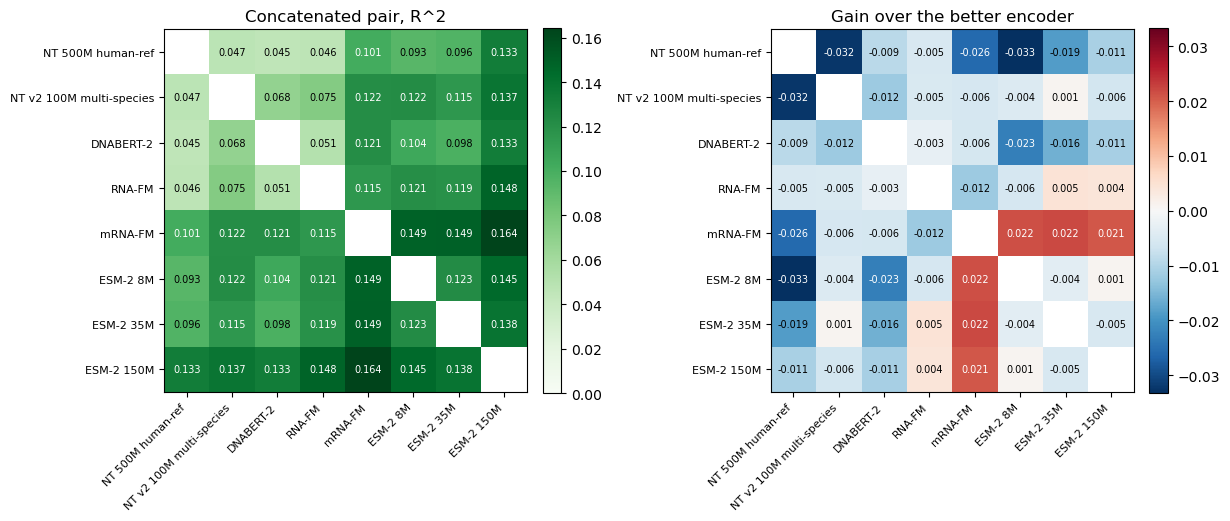

In [22]:
single_r2 = {k: stability_probes.loc[LABELS[k], "Stability R2"] for k in ENCODER_KEYS}


def concatenated(keys):
    """Return the listed encoders' embeddings placed side by side."""
    return np.hstack([EMBEDDINGS[k] for k in keys])


pair_concat = analysis.pairwise_matrix(
    ENCODER_KEYS,
    lambda a, b: analysis.probe_scores(concatenated([a, b]), labels, groups=kept_seqs).mean(),
)
pair_gain = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: pair_concat.loc[a, b] - max(single_r2[a], single_r2[b])
)
analysis.plot_matrices(
    {"Concatenated pair, R^2": pair_concat, "Gain over the better encoder": pair_gain},
    LABELS,
    diverging={"Gain over the better encoder"},
    fmt="{:.3f}",
)

**Check across fold assignments.** The pairwise gains above come from the pinned folds alone. The next cell repeats every pairwise comparison over the `N_FOLD_ASSIGNMENTS` further fold assignments. For each assignment, the gain is the concatenation's five-fold mean minus the better single encoder's five-fold mean on the same folds. The table reports the mean, minimum, and maximum gain and the number of assignments with a positive gain, sorted by mean gain. Every pair is included, so no pair is selected on its pinned result.

In [23]:
single_means = {
    k: analysis.probe_assignment_means(EMBEDDINGS[k], labels, kept_seqs, N_FOLD_ASSIGNMENTS)
    for k in ENCODER_KEYS
}
gain_rows = []
for a, b in PAIRS:
    combined = analysis.probe_assignment_means(concatenated([a, b]), labels, kept_seqs, N_FOLD_ASSIGNMENTS)
    gain = combined - np.maximum(single_means[a], single_means[b])
    gain_rows.append({
        "pair": f"{LABELS[a]} + {LABELS[b]}",
        "comparison": f"within {MODALITY[a]}" if MODALITY[a] == MODALITY[b] else "across modalities",
        "pinned gain": pair_gain.loc[a, b],
        "mean gain": gain.mean(),
        "min gain": gain.min(),
        "max gain": gain.max(),
        "assignments with a gain": int((gain > 0).sum()),
    })

pair_gains = pd.DataFrame(gain_rows).set_index("pair").sort_values("mean gain", ascending=False)
pair_gains.round(3)

,comparison,pinned gain,mean gain,min gain,max gain,assignments with a gain
pair,,,,,,
mRNA-FM + ESM-2 35M,across modalities,0.022,0.022,0.014,0.031,10
mRNA-FM + ESM-2 150M,across modalities,0.021,0.015,0.007,0.025,10
mRNA-FM + ESM-2 8M,across modalities,0.022,0.012,0.004,0.023,10
NT 500M human-ref + DNABERT-2,within DNA,-0.009,0.008,0.001,0.022,10
DNABERT-2 + RNA-FM,across modalities,-0.003,0.006,-0.011,0.015,9
RNA-FM + ESM-2 35M,across modalities,0.005,0.006,-0.007,0.012,9
NT v2 100M multi-species + ESM-2 35M,across modalities,0.001,0.005,-0.007,0.013,8
NT 500M human-ref + RNA-FM,across modalities,-0.005,0.005,-0.001,0.013,8
ESM-2 8M + ESM-2 150M,within protein,0.001,0.004,-0.001,0.009,8


In [24]:
group_sets = {
    f"All {m} encoders": [k for k in ENCODER_KEYS if MODALITY[k] == m] for m in ("DNA", "RNA", "protein")
}
group_sets["One per modality: " + ", ".join(LABELS[k] for k in REFERENCE_KEYS)] = REFERENCE_KEYS
group_sets["All encoders"] = ENCODER_KEYS
group_sets = {name: keys for name, keys in group_sets.items() if len(keys) > 1}

group_probes = analysis.probe_table(
    {name: concatenated(keys) for name, keys in group_sets.items()},
    {"Stability": labels},
    groups=kept_seqs,
    n_assignments=N_FOLD_ASSIGNMENTS,
)
group_probes["best member alone"] = [max(single_r2[k] for k in keys) for keys in group_sets.values()]
group_probes["difference"] = group_probes["Stability R2"] - group_probes["best member alone"]
group_probes.round(3)

,Stability R2,Stability SD,"Stability R2, 10 assignments","Stability SD, 10 assignments",best member alone,difference
encoder,,,,,,
All DNA encoders,0.062,0.033,0.069,0.010,0.080,-0.018
All RNA encoders,0.115,0.046,0.102,0.013,0.127,-0.012
All protein encoders,0.136,0.045,0.139,0.004,0.144,-0.008
"One per modality: NT 500M human-ref, RNA-FM, ESM-2 35M",0.109,0.069,0.123,0.005,0.114,-0.005
All encoders,0.124,0.085,0.145,0.004,0.144,-0.020


**Results.** On the pinned folds, the best pair, mRNA-FM with ESM-2 150M, reaches $R^2$ 0.164, and 7 of the 28 pairs exceed the better of their two encoders, by at most 0.022. Over the further fold assignments, four pairs gain under every assignment:

| Pair | Mean gain | Range of gains | Assignments with a gain |
|---|---:|---:|---:|
| mRNA-FM + ESM-2 35M | $+0.022$ | $+0.014$ to $+0.031$ | 10 of 10 |
| mRNA-FM + ESM-2 150M | $+0.015$ | $+0.007$ to $+0.025$ | 10 of 10 |
| mRNA-FM + ESM-2 8M | $+0.012$ | $+0.004$ to $+0.023$ | 10 of 10 |
| NT 500M human-ref + DNABERT-2 | $+0.008$ | $+0.001$ to $+0.022$ | 10 of 10 |

The other 24 pairs have mean gains from $-0.015$ to $+0.006$ and lose under at least one assignment.

Larger concatenations:

| Combination | $R^2$, pinned (fold SD) | $R^2$, further assignments | Best member alone, pinned | Difference, pinned |
|---|---:|---:|---:|---:|
| All DNA encoders | 0.062 (0.033) | 0.069 | 0.080 | $-0.018$ |
| All RNA encoders | 0.115 (0.046) | 0.102 | 0.127 | $-0.012$ |
| All protein encoders | 0.136 (0.045) | 0.139 | 0.144 | $-0.008$ |
| One per modality (NT 500M human-ref, RNA-FM, ESM-2 35M) | 0.109 (0.069) | 0.123 | 0.114 | $-0.005$ |
| All encoders | 0.124 (0.085) | 0.145 | 0.144 | $-0.020$ |

**Interpretation.** Pairing mRNA-FM with a protein encoder is the only combination that adds a meaningful amount of linearly accessible stability information under every fold assignment, about 0.01 to 0.02 of label variance on top of the better encoder. mRNA-FM reads synonymous codon choice, which the protein encoders cannot see, while the protein encoders bring representations learned from protein sequence variation, so the two may carry complementary signal; this probe shows the gain but does not identify its source. Apart from these pairs, only Nucleotide Transformer 500M with DNABERT-2 gains under every assignment, by less than 0.01 on average.

Larger concatenations do not help. Each adds hundreds to thousands of columns for 981 rows, and the ridge probe cannot use the extra features: concatenating all eight encoders at best matches ESM-2 150M alone. Standardizing every feature before the ridge penalty also gives a wider encoder more total weight in a combined probe.

These results are concatenation baselines. They do not rule out complementarity that a nonlinear or position-aware fusion model could exploit, and they do not show that such a model would help. The mRNA-FM and protein pairing is the clearest candidate for that test.

#### Final-layer representation similarity: linear CKA

Linear centered kernel alignment (CKA) compares the final-layer mean-pooled representations of the same retained examples, one pair of encoders at a time, for every pair in `PAIRS`. Corresponding rows refer to the same example, while the feature counts can differ.

Each calculation uses two separate embedding matrices, not their concatenation. It asks whether relationships between examples are similar across the two representations. The helper centers each feature across rows, computes dot products within and between the representations, and normalizes the comparison. The equation and notation are explained in [Linear centered kernel alignment](#Linear-centered-kernel-alignment) below.

Unlike the predictive probes, this calculation does not fit a prediction model or use stability labels. The probes ask which target properties a simple model can recover; CKA asks how similarly two representations organize the same examples.

Pairs within one modality are the reference for pairs across modalities. Two nucleotide encoders read the same letters, and two protein encoders read the same amino acids, so their CKA shows how similar two encoders are when only pretraining, tokenization, and model size differ. DNA and RNA encoders also read the same sequence, in two alphabets.

##### Linear centered kernel alignment

`analysis.linear_cka(X, Y)` compares representations of the same examples. `X` has shape `(n, p)` and `Y` has shape `(n, q)`: their feature counts may differ, but corresponding rows must identify the same example. Capital `Y` here is a second embedding matrix, distinct from the lowercase probe target `y` above.

**1. Center each feature across examples.**

For feature $j$ of the first representation, calculate its mean:

$$
\bar x_j=\frac{1}{n}\sum_{i=1}^{n}x_{ij}.
$$

In this notation:

- $n$ is the shared number of example rows; $p$ and $q$ are the numbers of features in $X$ and $Y$, respectively.
- $x_{ij}$ is the scalar entry of $X$ in example row $i$, feature column $j$.
- $\bar x_j$ is the mean of that feature across all $n$ rows. The bar denotes an average.
- $\sum_{i=1}^{n}$ adds the feature values across rows; division by $n$ takes their average.

Subtract that mean from each value in the feature:

$$
(X_c)_{ij}=x_{ij}-\bar x_j.
$$

In this notation:

- $X_c$ is the centered matrix, still of shape $(n,p)$; the subscript $c$ labels centering.
- $(X_c)_{ij}$ selects its entry at row $i$, column $j$.
- $x_{ij}$ and $\bar x_j$ have the meanings above: each row loses the same mean for feature $j$.

The code applies the same two operations independently to `Y` to obtain $Y_c$, with shape $(n,q)$. It subtracts each representation's own column means. Unlike the probe's standardization, CKA centering does not divide by feature standard deviations.

**2. Measure feature dot-product matrices with the Frobenius norm.**

The Frobenius norm combines all entries of a matrix into a scalar size:

$$
\|A\|_F=\sqrt{\sum_{a=1}^{r}\sum_{b=1}^{s}A_{ab}^{\,2}}.
$$

In this notation:

- $A$ is any real-valued matrix of shape $(r,s)$, and $A_{ab}$ is its entry in row $a$, column $b$.
- $r$ and $s$ are its row and column counts; $a$ and $b$ index those entries.
- The two summations add over every row and column. The exponent $2$ squares each entry, and the square root converts the total to a norm.
- $\|\cdot\|_F$ names the Frobenius norm. The subscript $F$ identifies the norm; it does not denote an evaluation fold here.

For example, the matrix with rows $(1,2)$ and $(2,4)$ has norm $\sqrt{1^2+2^2+2^2+4^2}=5$. Its squared Frobenius norm is $25$. These are illustrative values, not encoder results. NumPy implements this matrix norm with `np.linalg.norm(..., ord="fro")`; see [NumPy's norm definition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html).

**3. Normalize the cross-representation quantity.**

$$
\operatorname{CKA}(X,Y)
=\frac{\|Y_c^\top X_c\|_F^2}
{\|X_c^\top X_c\|_F\,\|Y_c^\top Y_c\|_F}.
$$

In this notation:

- $\operatorname{CKA}(X,Y)$ is the scalar linear CKA value returned by `linear_cka` for the two input matrices.
- $X_c$ and $Y_c$ are the centered matrices defined above.
- $\top$, written `.T` in NumPy, means transpose: exchange rows and columns.
- Juxtaposing matrices, as in $Y_c^\top X_c$, means matrix multiplication, written `@` in NumPy. Each output entry sums products along the shared dimension.
- $Y_c^\top X_c$ has shape $(q,p)$ and contains dot products between centered features in the two representations.
- $X_c^\top X_c$ has shape $(p,p)$, and $Y_c^\top Y_c$ has shape $(q,q)$. They contain feature dot products within each representation.
- $\|\cdot\|_F$ has the definition above. The numerator squares that norm; the denominator multiplies two unsquared scalar norms.

**Connection to the code.**

This is a direct NumPy calculation in `linear_cka`; no model is fitted. The table follows its operations in their actual order.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `X.mean(axis=0, keepdims=True)` | `(n, p)` → `(1, p)` | Calculate each feature mean $\bar x_j$, retaining a row dimension. |
| `X - X.mean(axis=0, keepdims=True)` | `(n, p)` → `(n, p)` | Subtract those means from every example to form $X_c$. The `Y` assignment similarly forms $Y_c$. |
| `Y_centered.T @ X_centered` | `(q, n)` and `(n, p)` → `(q, p)` | Form the cross-representation feature dot products. |
| `np.linalg.norm(..., ord="fro") ** 2` | `(q, p)` → scalar | Square their Frobenius norm to obtain `numerator`. |
| `X_centered.T @ X_centered`, then its Frobenius norm | `(p, n)` and `(n, p)` → `(p, p)` → scalar | Obtain `norm_x`; the corresponding `Y` operation gives `norm_y` through a `(q, q)` matrix. |
| `numerator / (norm_x * norm_y)` | Three scalars → scalar | Return the normalized CKA value. |

The `...` stands for the matrix product in the preceding row. NumPy broadcasts the `(1, p)` or `(1, q)` mean row during subtraction, applying it to every example row.

This feature-based calculation is equivalent to comparing the centered example-similarity matrices $X_cX_c^\top$ and $Y_cY_c^\top$, each of shape $(n,n)$. An entry in either matrix is the dot product between two centered example embeddings. The common normalization factor from the Hilbert-Schmidt independence criterion (HSIC) cancels in the CKA ratio, so the code names the unnormalized top term `numerator`.

For nonzero centered representations, linear CKA lies between zero and one in exact arithmetic. It is unchanged by orthogonal transformations, such as rotations and reflections, or by nonzero uniform scaling of either representation. Arbitrary changes of basis or separate scaling of individual features can change it. See [Kornblith et al. (2019), Section 3 and Table 1](https://proceedings.mlr.press/v97/kornblith19a/kornblith19a.pdf).

If either centered representation is entirely zero, the denominator is zero and CKA is undefined; this helper has no special handling for that case. High CKA describes representational similarity. It does not by itself establish good target prediction or a benefit from combining the modalities.

In [25]:
show_source(analysis.linear_cka, analysis.pairwise_matrix)

```python
def linear_cka(X, Y):
    """Return linear CKA for representations with matching example rows."""
    X_centered = X - X.mean(axis=0, keepdims=True)
    Y_centered = Y - Y.mean(axis=0, keepdims=True)
    numerator = np.linalg.norm(Y_centered.T @ X_centered, ord="fro") ** 2
    norm_x = np.linalg.norm(X_centered.T @ X_centered, ord="fro")
    norm_y = np.linalg.norm(Y_centered.T @ Y_centered, ord="fro")
    return numerator / (norm_x * norm_y)
```

```python
def pairwise_matrix(names, function):
    """Return a symmetric DataFrame of function(a, b) over every pair of names.

    The diagonal is left empty because each metric compares two different encoders.
    """
    matrix = pd.DataFrame(np.nan, index=names, columns=names)
    for a, b in itertools.combinations(names, 2):
        value = function(a, b)
        matrix.loc[a, b] = matrix.loc[b, a] = value
    return matrix
```

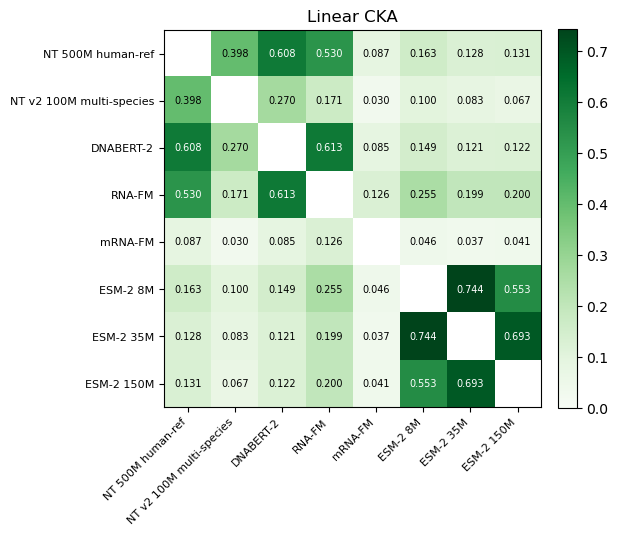

In [26]:
similarity = {
    "Linear CKA": analysis.pairwise_matrix(
        ENCODER_KEYS, lambda a, b: analysis.linear_cka(EMBEDDINGS[a], EMBEDDINGS[b])
    ),
}
analysis.plot_matrices({"Linear CKA": similarity["Linear CKA"]}, LABELS, fmt="{:.3f}")

**Results.** Linear CKA ranges from 0.030 to 0.744 across the 28 pairs:

| Group of pairs | Linear CKA |
|---|---:|
| Within protein (three ESM-2 models) | 0.553 to 0.744 |
| Within DNA | 0.270 to 0.608 |
| Within RNA (RNA-FM and mRNA-FM) | 0.126 |
| DNA with RNA-FM | 0.171 to 0.613 |
| mRNA-FM with DNA or protein | 0.030 to 0.087 |
| DNA or RNA-FM with protein | 0.067 to 0.255 |

**Interpretation.** Agreement follows tokenization and training more than the modality label. Nucleotide Transformer 500M, DNABERT-2, and RNA-FM read the same sequence as six-nucleotide tokens, byte-pair tokens, and single nucleotides, and they organize the sequences similarly (0.530 to 0.613) whether they are called DNA or RNA encoders. mRNA-FM, which reads codons, shares little global structure with any other encoder, including RNA-FM, the other RNA encoder. The two Nucleotide Transformer models agree only moderately (0.398) despite sharing a tokenizer, so pretraining corpus and model version also shape the geometry. The three ESM-2 models, which share architecture, tokenizer, and training data and differ in size, agree most.

Agreement between nucleotide and protein encoders is low throughout. CKA is a descriptive similarity on a zero-to-one scale, not a percentage of shared information or a significance result, and low CKA does not establish that two representations hold distinct useful information.

#### Layerwise representation similarity: linear CKA

The final-layer comparison gives one summary of representation similarity. This analysis asks whether that similarity changes with encoder depth by comparing every returned hidden state of one encoder with every returned hidden state of another, for every pair of encoders. A hidden state is the model's numerical representation at a particular point in its computation; it still contains one vector per token before pooling.

**1. Build one embedding matrix per returned state.**

The code first samples up to `LAYERWISE_N_ROWS = 200` rows, with `SEED`, from the same pre-filter sample used above, then applies the existing sequence filters with `datasets.retain`. Thus, 200 is a limit before filtering, not a guaranteed number of retained rows; 194 of the 200 sampled rows pass the filters. For each retained row, `embeddings.embed_all_layers` requests all hidden states in one forward pass per encoder and averages each state over the token axis. DNABERT-2's model code does not return all hidden states on request, so its states are captured with forward hooks on its embedding module and each transformer layer. Pooling still includes the returned special-token positions and uses the configured token limits.

For these outputs, index 0 denotes the embedding output before the first transformer block; indices 1 onward denote successive transformer-block outputs. An encoder with $L$ transformer blocks therefore returns $L+1$ states; Nucleotide Transformer 500M, for example, has 24 blocks and returns 25. The cell prints the count for every encoder. Index 0 is therefore not an additional transformer block. See the [Transformers hidden-state output convention](https://huggingface.co/docs/transformers/main_classes/output#transformers.modeling_outputs.BaseModelOutput).

`embeddings.embed_layers` stacks the pooled vectors from corresponding retained rows into one matrix per hidden-state index, and `layer_matrices` maps each encoder key to its list of matrices. Every matrix for one encoder has shape `(n, d)`, where $n$ is the number of rows retained in this sampled analysis and $d$ is that encoder's feature width. The same row always denotes the same example across all matrices.

**2. Compare each state of one encoder with each state of another.**

For one encoder pair, such as a DNA encoder and a protein encoder:

$$
C_{ij} = \operatorname{CKA}\!\left(X^{(i)}, Y^{(j)}\right).
$$

In this notation:

- $n$ is the number of examples retained for this layerwise sample. It can differ from the main dataset's retained count.
- $X^{(i)}$ is the first encoder's embedding matrix at hidden-state index $i$, stored as `layer_matrices[a][i]` for the first encoder `a` of the pair. $Y^{(j)}$ is the second encoder's matrix at state $j$, stored as `layer_matrices[b][j]`.
- The parenthesized superscripts identify states; they are not powers.
- $i$ runs over the first encoder's states and $j$ over the second encoder's states. These indices match the Python code directly.
- $\operatorname{CKA}$ names the scalar similarity calculated by `analysis.linear_cka`. The [linear CKA derivation](#Linear-centered-kernel-alignment) explains its centering and normalization.
- $C$ is the pair's full comparison matrix, stored as `layer_cka[(a, b)]`, with one row per state of the first encoder and one column per state of the second; $C_{ij}$ is its entry at row $i$ and column $j$.

For example, in the DNA-protein matrix, $C_{2,3}$ compares the pooled DNA vectors after DNA transformer block 2 with the pooled protein vectors after protein transformer block 3, across the same retained examples. It is one score for two whole matrices, not a comparison between example rows 2 and 3.

**Connection to the code.** For each pair in `PAIRS`, `analysis.layerwise_cka` calls `linear_cka` once for each state pair and stores the result. `analysis.layerwise_summary` reports each matrix's largest entry and its final-state pair, `matrix[-1, -1]`; Python index `-1` selects the last state on each axis. With eight encoders there are 28 matrices, so the table summarizes all of them and heatmaps are drawn for `LAYERWISE_PLOT_PAIRS`. These are descriptive comparisons of representations, not fitted cross-modal projections or evidence that a particular layer pair improves prediction.

**Check the role of the second encoder's embedding output.** A maximum at state 0 of an encoder occurs before any transformer block has processed its token representations. For each pair, `layerwise_summary` also repeats the maximum search after excluding state 0 of the second encoder in the pair.

The slice `matrix[:, 1:]` keeps every state of the first encoder, including its state 0, and only states 1 onward of the second. Adding 1 to the returned column index maps the sliced matrix back to the original state numbering. This asks whether another high-scoring pair remains after removing that embedding output; it does not restrict both encoders to transformer-block outputs.

In [27]:
show_source(embeddings.embed_all_layers, embeddings.embed_layers, analysis.layerwise_cka, analysis.layerwise_summary)

```python
@torch.no_grad()
def embed_all_layers(seq, encoder, tokenizer, model, device):
    """Mean-pool every returned hidden state for one sequence.

    Every encoder contributes its embedding-layer output followed by each transformer
    layer. DNABERT-2's own all-layer option fails, so its states are captured with
    forward hooks on the embedding module and each encoder layer.
    """
    inputs = tokenizer(
        encoder_input(encoder, seq), return_tensors="pt", truncation=True, max_length=encoder.max_len
    ).to(device)
    if encoder.loader == "remote_dnabert2":
        captured = []
        modules = [model.embeddings] + list(model.encoder.layer)
        hooks = [m.register_forward_hook(lambda _m, _i, out: captured.append(out)) for m in modules]
        try:
            model(**inputs)
        finally:
            for hook in hooks:
                hook.remove()
        layers = captured
    else:
        layers = model(**inputs, output_hidden_states=True).hidden_states
    return [h.reshape(-1, h.shape[-1]).mean(dim=0).float().cpu().numpy() for h in layers]
```

```python
def embed_layers(encoder, seqs, device):
    """Return one (n, d) matrix per hidden state for the given retained sequences.

    The encoder is loaded, applied to each sequence with embed_all_layers, and released.
    """
    tokenizer, model = load_encoder(encoder, device)
    per_sequence = [embed_all_layers(s, encoder, tokenizer, model, device) for s in seqs]
    del model, tokenizer
    free_memory()
    return [np.vstack([states[k] for states in per_sequence]) for k in range(len(per_sequence[0]))]
```

```python
def layerwise_cka(layers_a, layers_b):
    """Return the matrix of linear CKA between every hidden state of two encoders.

    Row i is state i of the first encoder and column j state j of the second; state 0
    is the embedding output before the first transformer block.
    """
    return np.array([[linear_cka(A, B) for B in layers_b] for A in layers_a])
```

```python
def layerwise_summary(matrix):
    """Return the maximum CKA and its states, the maximum without the second encoder's
    state 0, and the final-state CKA for one layer-wise matrix."""
    i, j = np.unravel_index(matrix.argmax(), matrix.shape)
    i1, j1 = np.unravel_index(matrix[:, 1:].argmax(), matrix[:, 1:].shape)
    return {
        "maximum": matrix.max(), "at states": f"{i}, {j}",
        "maximum without second state 0": matrix[:, 1:].max(), "at states (without)": f"{i1}, {j1 + 1}",
        "final states": matrix[-1, -1],
    }
```

In [28]:
sampled_rows = datasets.sample_rows(DATASET, N_ROWS, SEED)
layer_dataset = datasets.retain(
    dataset.spec, sampled_rows.sample(n=min(LAYERWISE_N_ROWS, len(sampled_rows)), random_state=SEED)
)
print(
    f"Layer-wise subsample: {len(layer_dataset.sequences)} of {layer_dataset.n_sampled} "
    "sampled rows pass the filters."
)

layer_matrices = {}
for encoder in ENCODERS:
    layer_matrices[encoder.key] = embeddings.embed_layers(encoder, layer_dataset.sequences, DEVICE)
    print(f"{encoder.label}: {len(layer_matrices[encoder.key])} hidden states")

layer_cka = {(a, b): analysis.layerwise_cka(layer_matrices[a], layer_matrices[b]) for a, b in PAIRS}
layerwise_table = pd.DataFrame(
    [{"pair": f"{LABELS[a]} / {LABELS[b]}", **analysis.layerwise_summary(m)} for (a, b), m in layer_cka.items()]
).set_index("pair")
layerwise_table.round(3)

Layer-wise subsample: 194 of 200 sampled rows pass the filters.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NT 500M human-ref: 25 hidden states
NT v2 100M multi-species: 23 hidden states


/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 569
  warnings.warn(
/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:433: UserWarning: Increasing alibi size from 569 to 594
  warnings.warn(


...

ESM-2 35M: 13 hidden states


Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 150M: 31 hidden states


,maximum,at states,maximum without second state 0,at states (without),final states
pair,,,,,
NT 500M human-ref / NT v2 100M multi-species,0.834,"0, 13",0.834,"0, 13",0.427
NT 500M human-ref / DNABERT-2,0.884,"0, 1",0.884,"0, 1",0.676
NT 500M human-ref / RNA-FM,0.764,"14, 1",0.764,"14, 1",0.596
NT 500M human-ref / mRNA-FM,0.916,"0, 1",0.916,"0, 1",0.105
NT 500M human-ref / ESM-2 8M,0.415,"1, 1",0.415,"1, 1",0.234
NT 500M human-ref / ESM-2 35M,0.400,"16, 0",0.359,"0, 1",0.187
NT 500M human-ref / ESM-2 150M,0.417,"16, 0",0.373,"16, 2",0.178
NT v2 100M multi-species / DNABERT-2,0.906,"11, 1",0.906,"11, 1",0.293
NT v2 100M multi-species / RNA-FM,0.804,"7, 10",0.804,"7, 10",0.178


**Read the full matrices.** Each heatmap shows one encoder pair in `LAYERWISE_PLOT_PAIRS`. Each tile shows one $C_{ij}$ value: the vertical axis selects the first encoder's hidden-state index, and the horizontal axis selects the second encoder's. The color bar gives the CKA score, and the panels share one color scale so their values can be compared. Inspecting a whole matrix shows whether elevated similarity is concentrated in a few pairs or spread across several depths; a single maximum cannot describe that pattern on its own.

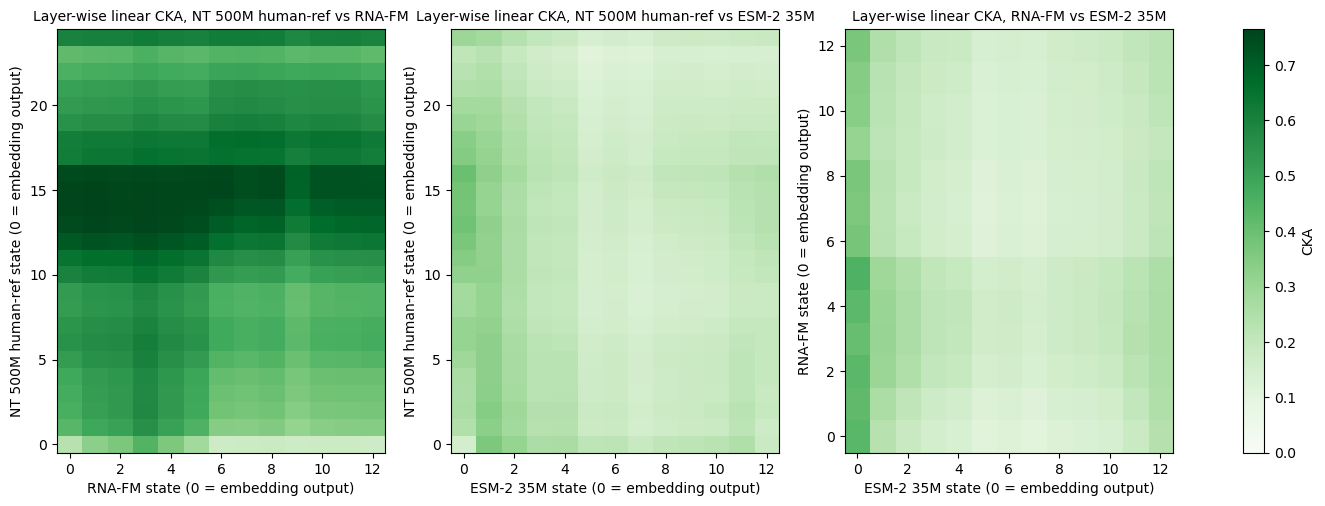

In [29]:
analysis.plot_layerwise({pair: layer_cka[pair] for pair in LAYERWISE_PLOT_PAIRS}, LABELS)

**Results.** The layer-wise subsample keeps 194 of the 200 sampled rows. For the three pairs drawn above:

| Pair | Maximum CKA (states) | Maximum without the second encoder's state 0 (states) | Final-state CKA in this subsample |
|---|---|---|---:|
| NT 500M human-ref / RNA-FM | 0.764 (14, 1) | 0.764 (14, 1) | 0.596 |
| NT 500M human-ref / ESM-2 35M | 0.400 (16, 0) | 0.359 (0, 1) | 0.187 |
| RNA-FM / ESM-2 35M | 0.451 (5, 0) | 0.306 (3, 1) | 0.225 |

Across all 28 pairs in the table, the maximum involves state 0, 1, or 2 of at least one encoder in 27 pairs. The three pairs of mRNA-FM with a protein encoder peak at 0.650 to 0.689, at mRNA-FM state 2 and protein state 1 or 3, above every other nucleotide-protein pair (at most 0.497), while their final-state values are the lowest of any nucleotide-protein pair (0.052 to 0.068). The three ESM-2 models agree almost perfectly at state 0 (0.982 to 0.994) and at 0.590 to 0.815 at their final states.

**Interpretation.** The heatmap for Nucleotide Transformer 500M and RNA-FM shows a dark horizontal band at Nucleotide Transformer states of about 12 to 16 that spans every RNA-FM state. Agreement between these two encoders is therefore set mainly by the DNA encoder's depth: its middle layers resemble RNA-FM best, whatever RNA-FM state is chosen. Nucleotide Transformer's embedding output (state 0) agrees weakly with RNA-FM, since its six-nucleotide token vocabulary starts from a different set of units. Both reference pairs involving ESM-2 35M peak in its first columns: the highest values sit at state 0, the embedding output before any transformer block, and removing that column moves the maximum to state 1. Deeper ESM-2 layers agree only weakly with either nucleotide encoder.

Across all pairs, the highest agreement sits in early states, which have mixed little context between tokens and are close to summaries of token composition; deeper layers diverge. mRNA-FM is the clearest case: its early states resemble the protein encoders' early states more than any other nucleotide encoder's do, consistent with codon tokens mapping directly onto amino acids, while its final states agree with them least. This supports composition, or a direct token correspondence, as the basis of most cross-encoder agreement, which the [composition control](#Composition-control) tests for the final layer.

The final-state entries come from the 194 retained rows of this subsample and are higher than the full-sample values in [Final-layer representation similarity](#Final-layer-representation-similarity:-linear-CKA), for example 0.596 against 0.530 for Nucleotide Transformer 500M and RNA-FM. Linear CKA tends to be inflated when the number of examples is small relative to the embedding widths. Layer-wise values should be compared within this analysis, not with the full-sample values.

#### Neighborhood overlap across representations

CKA summarizes similarity across representation matrices. Neighborhood overlap asks a more local question: for a particular retained row, are the examples nearest to it in one representation also nearest to it in another? The cell computes it for every pair of encoders. Neighbor identities refer to the same paired rows in both matrices, not to equal feature coordinates.

**1. Count shared neighbors for each row.**

$$
o_i = \frac{\left|N_X(i)\cap N_Y(i)\right|}{k}.
$$

In this notation:

- $X$ and $Y$ are the two embedding matrices of one encoder pair, such as `EMBEDDINGS["nt500m"]` with shape `(n, p)` and `EMBEDDINGS["esm2_35m"]` with shape `(n, q)`. The matrices contain $n$ matched examples; $p$ and $q$ are their respective feature counts.
- $i$ identifies the query example, from 1 through $n$ in the equation. Python indexes those same rows from 0 through `n - 1`.
- $k$ is the number of neighbor indices retained per query in each space; the call below uses $k=10$. Requesting one extra neighbor requires $1\le k\le n-1$.
- $N_X(i)$ and $N_Y(i)$ are the sets of retained neighbor-row indices for query $i$ in the spaces of $X$ and $Y$, respectively. Parentheses specify which query's set is being selected.
- $\cap$ means set intersection: keep only indices appearing in both sets.
- The vertical bars $|\cdot|$ count the indices in that intersection. They denote a set's size, not a vector norm.
- $o_i$ is the shared-neighbor fraction for row $i$, a scalar between 0 and 1. Dividing the shared count by $k$ puts queries on the same scale.

For example, if 3 of a row's 10 retained neighbors are shared, its fraction is $o_i=3/10=0.3$.

**2. Average the row fractions.**

$$
\operatorname{overlap@}k
=\frac{1}{n}\sum_{i=1}^{n}o_i.
$$

In this notation:

- $\operatorname{overlap@}k$ names the final mean overlap at the chosen neighbor count $k$. The `@` reads “at”; it is part of the metric's name.
- $\sum_{i=1}^{n}$ adds the scalar fractions $o_i$ over all $n$ query rows; dividing by $n$ takes their mean.

**Connection to the code.** `analysis.mutual_knn_alignment` calculates each $o_i$ in its `overlaps` list and returns their mean with `np.mean(overlaps)`. Despite the helper's name, this is overlap between two neighbor sets, not a check that neighbor relationships are reciprocal.

The helper uses the default Euclidean distance of [`NearestNeighbors`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html). It requests $k+1$ neighbors and removes the first returned index with `[i, 1:]`, intending to exclude the query itself. With duplicate vectors or distance ties, that first index need not be the query's own index; explicit self-exclusion remains an evaluation issue. The sets in the equations describe what the code retains under this rule, rather than guaranteeing that all retained neighbors are other rows.

**The chance reference uses an idealized selection rule.** For two independent, uniformly selected sets of $k$ nonself neighbors among $n-1$ candidates, the expected overlap fraction is $k/(n-1)$. Here, $n-1$ excludes the query row. Each of the $k$ neighbors in one set has probability $k/(n-1)$ of appearing in the other. The printed chance level uses $k/(n-1)$. This reference is not a simulated random-embedding result or a significance test, and disagreement with CKA would not by itself invalidate either metric.

In [30]:
show_source(analysis.mutual_knn_alignment)

```python
def mutual_knn_alignment(X, Y, k=10):
    """Average neighbor-set overlap after discarding each first returned index."""
    n = X.shape[0]
    neighbors_x = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X, return_distance=False)
    neighbors_y = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)
    overlaps = [len(set(neighbors_x[i, 1:]) & set(neighbors_y[i, 1:])) / k for i in range(n)]
    return np.mean(overlaps)
```

Chance level for k = 10 among 981 rows: about 0.0102


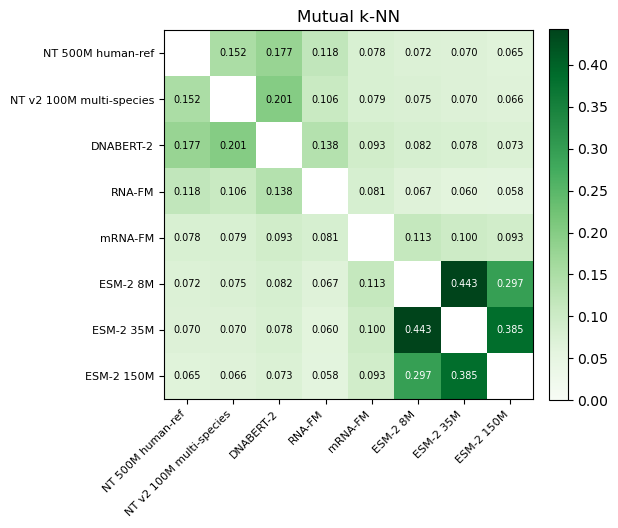

In [31]:
similarity["Mutual k-NN"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.mutual_knn_alignment(EMBEDDINGS[a], EMBEDDINGS[b], k=10)
)
print(f"Chance level for k = 10 among {len(kept_seqs)} rows: about {10 / (len(kept_seqs) - 1):.4f}")
analysis.plot_matrices({"Mutual k-NN": similarity["Mutual k-NN"]}, LABELS, fmt="{:.3f}")

**Results.** Neighborhood overlap with $k=10$ on all 981 rows, where chance is about 0.0102:

| Group of pairs | Mutual $k$-NN |
|---|---:|
| Within protein | 0.297 to 0.443 |
| Within DNA | 0.152 to 0.201 |
| Within RNA | 0.081 |
| DNA with RNA-FM | 0.106 to 0.138 |
| DNA with mRNA-FM | 0.078 to 0.093 |
| mRNA-FM with protein | 0.093 to 0.113 |
| DNA or RNA-FM with protein | 0.058 to 0.082 |

**Interpretation.** Every pair shares far more neighbors than chance, from about 6 to 43 times. The ordering largely follows CKA, with one exception: mRNA-FM, whose global geometry agrees least with the protein encoders, shares more local neighborhoods with them than any other nucleotide encoder does. Two encoders can therefore agree on which sequences are near each other while their spaces differ overall. Most neighbors still differ between any two encoders, even the ESM-2 models, which share at most 44%.

#### Canonical correlation and cross-modal retrieval

The previous metrics compare the representations without learning a cross-modal projection. Canonical correlation analysis (CCA) instead fits linear combinations of features that vary together across matched examples of two representations. The cell fits a separate CCA for every pair of encoders, querying with the encoder that comes first in `ENCODER_KEYS` and searching the second; the matrices show each pair's value in both positions. The explanation below uses the first encoder's representation as $X$ and the second's as $Y$. It can reveal correspondence in selected directions even when a whole-matrix comparison is modest.

**1. Fit the transformations on training rows.**

`splits.holdout_split` divides the matched row indices into 70% training and 30% test rows using `SEED`. The same indices select every encoder's matrix, so every pair uses the same training and test rows. Write $n_{\mathrm{train}}$ for the number of training pairs and $n_{\mathrm{test}}$ for the number of test pairs; $p$ and $q$ are the embedding widths of the pair's first and second encoders.

Each encoder's representation receives a separate principal component analysis (PCA), fitted only on its training matrix, retaining 50 components. PCA supplies a smaller feature space using directions of large training-set variation. The implementation centers features without standardizing their variances before PCA. See [the PCA definition and implementation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

The code then fits `CCA(n_components=10)` on the two reduced training matrices, using CCA's default input scaling. It applies the fitted PCA and CCA transformations to test rows without refitting them. The shape changes make the roles of 50 and 10 explicit:

| Code operation | Input shape → output shape | Meaning |
|---|---|---|
| `pca_a.transform(X_a[test_idx])` | `(n_test, p)` → `(n_test, 50)` | Express the first encoder's test rows using the 50 PCA directions learned from its training rows. |
| `pca_b.transform(X_b[test_idx])` | `(n_test, q)` → `(n_test, 50)` | Express the matched rows of the second encoder using its separately fitted PCA. |
| `cca.transform(...)` on the two reduced test matrices | Two `(n_test, 50)` matrices → two `(n_test, 10)` matrices | Produce canonical coordinates for both encoders using the fitted CCA transformations. |

In the table, `n_test` means $n_{\mathrm{test}}$. The training PCA outputs similarly have shape `(n_train, 50)` before CCA is fitted.

**2. Understand one canonical pair.**

CCA starts by seeking one weighted combination of the first modality's reduced features and one of the second modality's reduced features. For the first pair, write the two projected vectors as

$$
\mathbf u = \widetilde X_{\mathrm{train}}\mathbf a.
$$

The corresponding projection of the second modality is:

$$
\mathbf v = \widetilde Y_{\mathrm{train}}\mathbf b.
$$

In this notation:

- $n_{\mathrm{train}}$ and $n_{\mathrm{test}}$ count the paired training and test examples. The subscripts identify their partitions.
- $p$ and $q$ are the respective original embedding widths of the first and second encoders, before PCA reduces each to 50 features.
- $\widetilde X_{\mathrm{train}}$ and $\widetilde Y_{\mathrm{train}}$ are the first and second encoders' training matrices after PCA reduction and CCA's internal centering and scaling. Each has shape `(n_train, 50)`.
- The tilde, read as “X tilde” or “Y tilde,” marks these processed matrices. It does not mean an approximation here. The subscript “train” identifies their training rows.
- $\mathbf a$ and $\mathbf b$ are coefficient vectors with 50 entries each: one coefficient for each PCA feature in the respective representation. Bold lowercase symbols here represent vectors.
- Matrix-vector multiplication, such as $\widetilde X_{\mathrm{train}}\mathbf a$, multiplies each row's 50 feature values by the corresponding 50 coefficients and adds them. It produces one number per training row.
- $\mathbf u$ and $\mathbf v$ are therefore vectors of length $n_{\mathrm{train}}$, containing one canonical coordinate per training example in each representation. They are not the 50 coefficients themselves.

For a small illustration with only two features, a processed row `[2, 3]` and coefficients `[0.5, -1]` give the single coordinate $2(0.5)+3(-1)=-2$. The actual calculation combines 50 features per row. These illustrative values are not fitted notebook results.

The first-pair objective is

$$
(\mathbf a^\star,\mathbf b^\star)
=
\underset{\mathbf a,\mathbf b}{\operatorname{arg\,max}}\;
\operatorname{corr}\!\left(\widetilde X_{\mathrm{train}}\mathbf a,\,
                          \widetilde Y_{\mathrm{train}}\mathbf b\right).
$$

In this notation:

- $\operatorname{corr}$ means Pearson correlation across paired training rows: it measures how the two projected vectors vary together. Both projected vectors must have nonzero variance for this correlation to be defined.
- $\operatorname{arg\,max}$ means “find coefficient vectors that make the correlation as large as possible.” It returns the coefficient choices, rather than the maximum correlation value.
- The $\mathbf a,\mathbf b$ below the operator identify the quantities being chosen; the processed training matrices remain fixed.
- The stars in $\mathbf a^\star$ and $\mathbf b^\star$ label optimizing coefficient vectors. They do not mean multiplication or another power. Each selected vector still has 50 entries.

This equation describes the first-pair mathematical objective behind the library method. The notebook delegates fitting to `CCA.fit`; it does not implement this optimization itself. The library learns subsequent pairs after removing previously captured variation and constructs the transformations used by `CCA.transform`. Requesting 10 components therefore yields 10 coordinates per example in each representation, with each coordinate formed from the 50 input features. A canonical coordinate is a learned numerical combination, not an identified biological mechanism. See [CCA](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.CCA.html) and the [cross-decomposition guide](https://scikit-learn.org/stable/modules/cross_decomposition.html#canonical-correlation-analysis).

`analysis.cca_retrieval` measures test correlations by applying `np.corrcoef` to corresponding columns of the two test coordinate matrices, pairing the same test rows. It returns these test coordinates as `cca_results[(a, b)]["test_coords"]` for the [sample-level alignment diagnostic](#Sample-level-alignment-and-prediction-error). Test correlations need not decrease with component index: the component order was learned from the training rows.

**3. Retrieve the matched row of the second encoder for each test row of the first.**

Each test vector of the first encoder queries the test vectors of the second by Euclidean distance in the resulting 10-dimensional coordinates. Its designated correct match is the row of the second encoder with the same test-set index. The code measures

$$
\operatorname{Recall@}k
=
\frac{1}{n_{\mathrm{test}}}
\sum_{i=1}^{n_{\mathrm{test}}}
\mathbf{1}\!\left\{i\in R_k(i)\right\}.
$$

In this notation:

- $k$ is the number of retrieved candidates considered per query. The notebook reports 1, 5 and 10; the formula assumes $1\le k\le n_{\mathrm{test}}$.
- $i$ identifies a paired test row, from 1 through $n_{\mathrm{test}}$ in the equation. Python uses indices 0 through `n_test - 1`. These are positions within the test arrays, not the original dataset's row numbers.
- $R_k(i)$ is the set of the first $k$ indices of the second encoder returned for query $i$; the subscript $k$ records the chosen candidate count.
- $\in$ means “belongs to,” also read as “is an element of” or “is a member of.” These are equivalent expressions for set membership. Thus, $i\in R_k(i)$ asks whether the designated row index belongs to the retrieved candidate set.
- $\mathbf{1}\{\cdot\}$ is an indicator: it returns the scalar 1 if the statement in braces is true and 0 otherwise. This bold 1 is not an embedding vector.
- $\sum_{i=1}^{n_{\mathrm{test}}}$ adds the successful-match indicators, and division by $n_{\mathrm{test}}$ gives the fraction of successful queries.
- $\operatorname{Recall@}k$ names that fraction, read as “recall at k.” There is one designated correct match per query here.

**Plain-English interpretation.** Take each test entry of the first encoder in turn and retrieve the $k$ nearest test entries of the second encoder using their coordinates from the fitted CCA transformations. Check whether the entry from the same test row appears among those candidates. Count one success if it appears and zero otherwise, then divide the total successes by the number of test queries. The result is the fraction of queries whose designated partner appears within the first $k$ positions. A different row containing an identical sequence does not count as that designated partner.

For example, if query 4 returns protein indices `[8, 4, 2]`, it fails at $k=1$ but succeeds at $k=3$. In the code, `i in neighbors[i, :k]` performs the membership check, and the mean over queries gives the reported fraction. Tied distances at the cutoff inherit the library's returned ordering.

**The chance reference is a ranking calculation.** A uniformly random ranking has expected success $k/n_{\mathrm{test}}$ for $k\le n_{\mathrm{test}}$: the one designated match has $k$ successful positions among $n_{\mathrm{test}}$ possible positions. For 295 test rows, the count produced by a 30% split of 981 rows, top-1 chance is $1/295\approx0.0034$, or about **0.34%**. This is a ranking reference, not a $p$-value.

Training the transformations only on training rows avoids fitting those transformations to test rows. This is still a row-level split: it does not ensure that duplicate or biologically related sequences stay in the same partition. Neither CCA fitting nor retrieval uses the stability labels.

In [32]:
show_source(splits.holdout_split, analysis.cca_retrieval)

```python
def holdout_split(n, test_size=0.3, seed=42):
    """Return (train, test) row indices for the CCA and retrieval analyses.

    This reproduces the Stage 1 split, which is random by row rather than grouped, so
    copies of a duplicated sequence can fall on both sides.
    """
    return train_test_split(np.arange(n), test_size=test_size, random_state=seed)
```

```python
def cca_retrieval(X_a, X_b, train_idx, test_idx, seed, n_pca=50, n_cca=10, ks=(1, 5, 10)):
    """Fit PCA then CCA on training rows; return held-out correlations and retrieval.

    The procedure uses PCA with 50 components per space, CCA with 10 components,
    correlations of each component pair on the test rows, and Recall@k for querying the
    second space with the first in the CCA space.
    """
    n_pca = min(n_pca, len(train_idx) - 1, X_a.shape[1], X_b.shape[1])
    pca_a = PCA(n_components=n_pca, random_state=seed).fit(X_a[train_idx])
    pca_b = PCA(n_components=n_pca, random_state=seed).fit(X_b[train_idx])
    cca = CCA(n_components=n_cca).fit(pca_a.transform(X_a[train_idx]), pca_b.transform(X_b[train_idx]))
    a_c, b_c = cca.transform(pca_a.transform(X_a[test_idx]), pca_b.transform(X_b[test_idx]))
    corrs = np.array([np.corrcoef(a_c[:, i], b_c[:, i])[0, 1] for i in range(n_cca)])
    n_test = len(test_idx)
    neighbors = NearestNeighbors(n_neighbors=min(max(ks), n_test)).fit(b_c).kneighbors(
        a_c, return_distance=False
    )
    recall = {k: np.mean([i in neighbors[i, :k] for i in range(n_test)]) for k in ks}
    return {"correlations": corrs, "recall": recall, "test_coords": (a_c, b_c)}
```

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


686 training rows, 295 test rows; Recall@1 chance 0.0034.


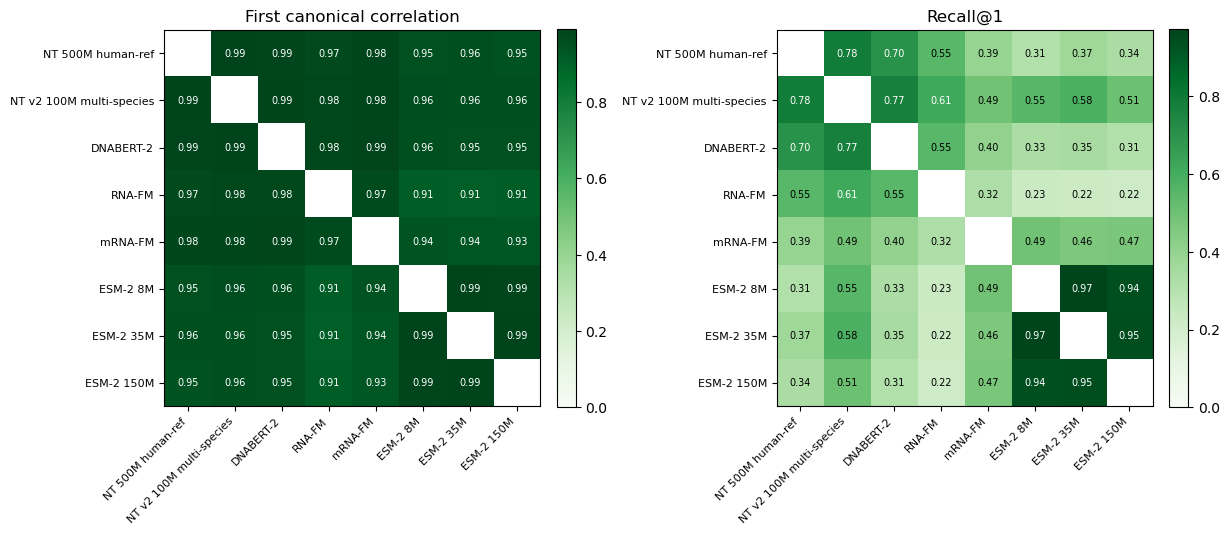

In [33]:
train_idx, test_idx = splits.holdout_split(len(kept_seqs), seed=SEED)
cca_results = {
    (a, b): analysis.cca_retrieval(EMBEDDINGS[a], EMBEDDINGS[b], train_idx, test_idx, SEED)
    for a, b in PAIRS
}


def from_cca(extract):
    """Turn a summary of one pair's CCA result into a function of the two encoder keys."""
    return lambda a, b: extract(cca_results[(a, b)])


similarity["First canonical correlation"] = analysis.pairwise_matrix(
    ENCODER_KEYS, from_cca(lambda r: r["correlations"][0])
)
similarity["Mean canonical correlation"] = analysis.pairwise_matrix(
    ENCODER_KEYS, from_cca(lambda r: r["correlations"].mean())
)
for k in (1, 5, 10):
    similarity[f"Recall@{k}"] = analysis.pairwise_matrix(ENCODER_KEYS, from_cca(lambda r, k=k: r["recall"][k]))

print(f"{len(train_idx)} training rows, {len(test_idx)} test rows; Recall@1 chance {1 / len(test_idx):.4f}.")
analysis.plot_matrices({name: similarity[name] for name in ["First canonical correlation", "Recall@1"]}, LABELS)

**Results.** CCA fitted on 686 rows and evaluated on 295 held-out rows, where Recall@1 chance is 0.0034:

| Group of pairs | First canonical correlation | Recall@1 |
|---|---:|---:|
| Within protein | 0.987 to 0.992 | 0.936 to 0.973 |
| Within DNA | 0.988 to 0.992 | 0.702 to 0.783 |
| Within RNA | 0.966 | 0.322 |
| DNA with RNA-FM | 0.972 to 0.978 | 0.549 to 0.614 |
| DNA with mRNA-FM | 0.982 to 0.985 | 0.393 to 0.492 |
| DNA with protein | 0.950 to 0.960 | 0.308 to 0.580 |
| RNA-FM with protein | 0.908 to 0.912 | 0.217 to 0.234 |
| mRNA-FM with protein | 0.932 to 0.942 | 0.458 to 0.492 |

The warnings printed by this cell come from the CCA fits for ESM-2 8M with ESM-2 150M and ESM-2 35M with ESM-2 150M, which reached scikit-learn's iteration limit. Their reduced spaces are nearly redundant, and their retrieval is near the ceiling either way.

**Interpretation.** After fitting linear projections, every pair shares a strongly correlated low-dimensional subspace: the first canonical direction correlates above 0.9 on held-out rows for all 28 pairs. Retrieval separates the pairs more clearly. The protein encoders identify each other's sequences almost perfectly, and the DNA encoders identify each other's 70% to 78% of the time. Among nucleotide encoders, Nucleotide Transformer v2 and mRNA-FM find a sequence's protein partner most often, about half the time or 135 to 171 times chance, despite their low CKA with the protein encoders. RNA-FM finds its protein partner least often of all nucleotide encoders; it is the only encoder that reads a truncated sequence, which is a consistent explanation for weaker correspondence with encoders that read the whole sequence.

High retrieval can coexist with modest CKA because CCA selects a few directions that agree and ignores the rest. The split assigns rows rather than sequences, but the 981 retained rows contain 964 distinct sequences, so at most 17 test rows can have an identical copy on the training side. The [composition control](#Composition-control) below shows how much of this correspondence remains once letter, codon, and amino-acid frequencies are removed. Retrieval measures correspondence between representations, not stability prediction, and does not show that a learned fusion method will help.

#### Composition control

The [layer-wise CKA](#Layerwise-representation-similarity:-linear-CKA) and [GC-content](#GC-content-prediction) results suggest a hypothesis: the representations may agree largely because each tracks sequence composition. This analysis tests that hypothesis by removing composition from every embedding and repeating two of the comparisons above.

**1. Describe each sequence by its composition.**

$$
\mathbf f(s) = \big(\mathrm{GC}(s),\ \mathrm{GC3}(s),\ \log L(s),\ c_1(s),\ldots,c_{64}(s),\ a_1(s),\ldots,a_{20}(s)\big).
$$

In this notation:

- $s$ is one retained coding sequence, and $L(s)$ is its length in nucleotides.
- $\mathrm{GC}(s)$ and $\mathrm{GC3}(s)$ are the GC fractions over the whole sequence and over third codon positions, as defined in [GC-content prediction](#GC-content-prediction) and [GC3 prediction](#GC3-prediction).
- $\log$ is the natural logarithm.
- $c_k(s)$ is the frequency of codon $k$, for the 64 possible codons in a fixed order, among the sequence's complete codons. The 64 frequencies sum to 1.
- $a_m(s)$ is the frequency of amino acid $m$, for the 20 standard amino acids, in the translated protein.
- $\mathbf f(s)$ is the resulting vector of 87 features. Stacking one row per retained sequence gives the matrix `composition` with shape `(n, 87)`.

These features contain no learned representation: they are what any encoder could learn from letter, codon, and amino-acid counts alone.

**2. Remove the part of each embedding that composition predicts linearly.**

$$
X^{\perp} = X - F_s\,\hat B.
$$

In this notation:

- $X$ is one encoder's $n \times d$ embedding matrix, such as `EMBEDDINGS["nt500m"]`.
- $F_s$ is the $n \times 88$ matrix of standardized composition features plus a column of ones for the intercept.
- $\hat B$ is the least-squares coefficient matrix, with one column per embedding coordinate.
- $X^{\perp}$ is the residual embedding, with the same shape as $X$. Each of its columns is uncorrelated with every composition feature.

The share of embedding variance that composition explains is

$$
R^2_{\mathrm{comp}}(X) = 1 - \frac{\lVert X^{\perp}\rVert_F^2}{\lVert X - \bar X\rVert_F^2},
$$

where $\lVert\cdot\rVert_F^2$ sums the squares of every entry and $\bar X$ repeats the column means in every row. This is an in-sample fit: 88 predictors unrelated to the embedding would explain about $88/n \approx 0.09$ of its variance by chance with $n = 981$.

**3. Repeat the comparisons on the residuals.**

For every pair of encoders, the cell reports linear CKA and CCA Recall@1 before and after residualization. Recall@1 uses the same PCA-CCA pipeline and the same `train_idx` and `test_idx` rows as [Canonical correlation and cross-modal retrieval](#Canonical-correlation-and-cross-modal-retrieval), so its "before" value should match the Recall@1 printed there.

**Interpretation.** Agreement between two residual embeddings cannot come from shared linear composition. A large drop after residualization means that the comparison above mostly reflected composition; agreement that remains points to shared information beyond letter, codon, and amino-acid frequencies.

**Connection to the code.** `sequences.composition_features` computes one row of $\mathbf f(s)$, counting non-overlapping codons from the first nucleotide to match `translate_cds`. `analysis.residualize` fits the least-squares regression on all retained rows and returns $X^{\perp}$, and `analysis.composition_share` computes $R^2_{\mathrm{comp}}$. The regression uses composition only, never stability labels. It is linear, so nonlinear functions of composition can remain in the residuals.

In [34]:
show_source(sequences.composition_features, analysis.residualize, analysis.composition_share)

```python
def composition_features(seq):
    """Return GC, GC3, log length, 64 codon frequencies, and 20 amino-acid frequencies."""
    dna = rna_to_dna(seq)
    protein = translate_cds(seq)
    codons = [dna[i:i + 3] for i in range(0, len(dna) - 2, 3)]
    codon_counts = pd.Series(codons).value_counts()
    codon_freq = [codon_counts.get(c, 0) / len(codons) for c in CODONS]
    aa_freq = [protein.count(a) / max(len(protein), 1) for a in AMINO_ACIDS]
    return [gc_content(dna), gc3_content(dna), np.log(len(dna))] + codon_freq + aa_freq
```

```python
def residualize(X, F):
    """Remove the least-squares fit on standardized F, with an intercept, from every column of X."""
    F_s = StandardScaler().fit_transform(F)
    design = np.column_stack([np.ones(len(F_s)), F_s])
    coef, *_ = np.linalg.lstsq(design, X, rcond=None)
    return X - design @ coef
```

```python
def composition_share(X, X_residual):
    """Share of an embedding's total variance explained by the composition fit (in sample)."""
    total = ((X - X.mean(axis=0)) ** 2).sum()
    return 1 - (X_residual ** 2).sum() / total
```

In [35]:
composition = np.array([sequences.composition_features(s) for s in kept_seqs])
RESIDUALS = {k: analysis.residualize(X, composition) for k, X in EMBEDDINGS.items()}

n_predictors = composition.shape[1] + 1  # composition features plus the intercept
print(
    f"Chance level for {n_predictors} predictors on {len(kept_seqs)} rows: "
    f"about {n_predictors / len(kept_seqs):.3f}"
)
pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "share of variance explained by composition": [
         analysis.composition_share(EMBEDDINGS[k], RESIDUALS[k]) for k in ENCODER_KEYS
     ]},
    index=[LABELS[k] for k in ENCODER_KEYS],
).round(3)

Chance level for 88 predictors on 981 rows: about 0.090


,modality,share of variance explained by composition
NT 500M human-ref,DNA,0.618
NT v2 100M multi-species,DNA,0.804
DNABERT-2,DNA,0.610
RNA-FM,RNA,0.677
mRNA-FM,RNA,0.296
ESM-2 8M,protein,0.479
ESM-2 35M,protein,0.446
ESM-2 150M,protein,0.437


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


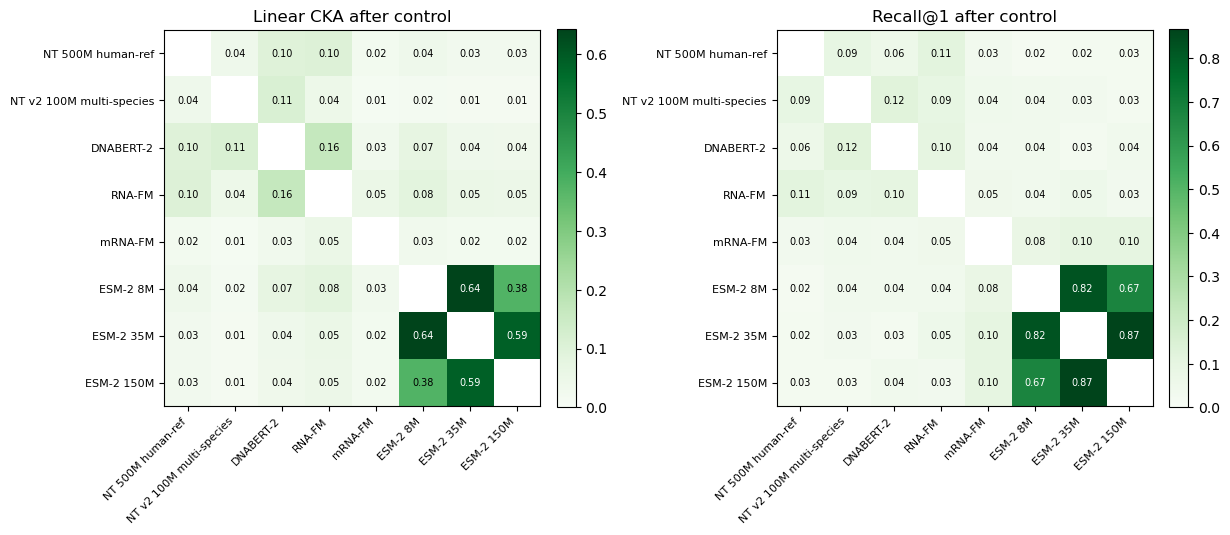

,comparison,CKA before,CKA after,Recall@1 before,Recall@1 after,CKA reduction
pair,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,0.398,0.038,0.783,0.092,0.904
NT 500M human-ref / DNABERT-2,within DNA,0.608,0.097,0.702,0.058,0.840
NT 500M human-ref / RNA-FM,across modalities,0.530,0.101,0.549,0.112,0.810
NT 500M human-ref / mRNA-FM,across modalities,0.087,0.021,0.393,0.034,0.763
NT 500M human-ref / ESM-2 8M,across modalities,0.163,0.039,0.308,0.017,0.759
NT 500M human-ref / ESM-2 35M,across modalities,0.128,0.027,0.366,0.024,0.792
NT 500M human-ref / ESM-2 150M,across modalities,0.131,0.025,0.336,0.027,0.807
NT v2 100M multi-species / DNABERT-2,within DNA,0.270,0.113,0.769,0.122,0.582
NT v2 100M multi-species / RNA-FM,across modalities,0.171,0.044,0.614,0.092,0.743


In [36]:
similarity["Linear CKA after control"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.linear_cka(RESIDUALS[a], RESIDUALS[b])
)
similarity["Recall@1 after control"] = analysis.pairwise_matrix(
    ENCODER_KEYS,
    lambda a, b: analysis.cca_retrieval(RESIDUALS[a], RESIDUALS[b], train_idx, test_idx, SEED)["recall"][1],
)
analysis.plot_matrices(
    {name: similarity[name] for name in ["Linear CKA after control", "Recall@1 after control"]}, LABELS
)

composition_control = analysis.pair_table(
    {
        "CKA before": similarity["Linear CKA"],
        "CKA after": similarity["Linear CKA after control"],
        "Recall@1 before": similarity["Recall@1"],
        "Recall@1 after": similarity["Recall@1 after control"],
    },
    PAIRS, LABELS, MODALITY,
)
composition_control["CKA reduction"] = 1 - composition_control["CKA after"] / composition_control["CKA before"]
composition_control.round(3)

**Results.** Share of embedding variance explained by composition, in sample, where 88 unrelated predictors would explain about 0.090:

| Encoder | Modality | $R^2_{\mathrm{comp}}$ |
|---|---|---:|
| NT 500M human-ref | DNA | 0.618 |
| NT v2 100M multi-species | DNA | 0.804 |
| DNABERT-2 | DNA | 0.610 |
| RNA-FM | RNA | 0.677 |
| mRNA-FM | RNA | 0.296 |
| ESM-2 8M | Protein | 0.479 |
| ESM-2 35M | Protein | 0.446 |
| ESM-2 150M | Protein | 0.437 |

Agreement before and after removing composition, where Recall@1 chance is about 0.0034:

| Group of pairs | CKA before | CKA after | Recall@1 before | Recall@1 after |
|---|---:|---:|---:|---:|
| Within protein | 0.553 to 0.744 | 0.376 to 0.643 | 0.936 to 0.973 | 0.671 to 0.868 |
| Within DNA | 0.270 to 0.608 | 0.038 to 0.113 | 0.702 to 0.783 | 0.058 to 0.122 |
| Within RNA | 0.126 | 0.055 | 0.322 | 0.047 |
| DNA with RNA-FM | 0.171 to 0.613 | 0.044 to 0.164 | 0.549 to 0.614 | 0.092 to 0.112 |
| DNA with mRNA-FM | 0.030 to 0.087 | 0.012 to 0.031 | 0.393 to 0.492 | 0.034 to 0.044 |
| DNA with protein | 0.067 to 0.163 | 0.013 to 0.072 | 0.308 to 0.580 | 0.017 to 0.041 |
| RNA-FM with protein | 0.199 to 0.255 | 0.050 to 0.085 | 0.217 to 0.234 | 0.034 to 0.054 |
| mRNA-FM with protein | 0.037 to 0.046 | 0.021 to 0.028 | 0.458 to 0.492 | 0.078 to 0.102 |

**Interpretation.** Composition is a large part of most pooled embeddings: letter, codon, and amino-acid frequencies explain 61% to 80% of the variance in the DNA embeddings and in RNA-FM's, and 44% to 48% in the protein embeddings, several times the chance level. mRNA-FM is the exception at 30%, the only encoder below the protein encoders.

Removing composition removes most of the agreement involving a nucleotide encoder. Across those pairs, CKA falls by 38% to 90% and Recall@1 to between 0.017 and 0.122. Agreement among the protein encoders survives: CKA after the control remains 0.38 to 0.64 and Recall@1 0.67 to 0.87, because the three ESM-2 models share far more than amino-acid frequencies.

The nucleotide-protein pairing that keeps the most correspondence is mRNA-FM with a protein encoder. After the control, it still retrieves its protein partner 8% to 10% of the time, about 23 to 30 times chance, more than any other nucleotide encoder (at most 0.054). This residual is the part that could reflect shared information beyond composition, such as the order of codons and amino acids along the sequence, which frequency features do not describe; nonlinear composition effects are not excluded by this linear control.

The encoders with the most stability signal in Track A, mRNA-FM and the protein encoders, are also the least composition-dominated, but the relationship is not monotonic: Nucleotide Transformer v2 has the largest composition share and the highest stability score among the other nucleotide encoders.

For the project's definition of alignment, this means raw similarity between frozen pooled embeddings is a weak target: most agreement involving nucleotide encoders can be reproduced from counts alone. Comparisons of alignment methods or fusion models should report agreement both before and after a composition control like this one.

#### Summary of Track B metrics for every pair

The table collects the geometry metrics above for each pair of encoders and labels whether the two encoders share a modality. Within-modality pairs are the reference for reading pairs across modalities.

In [37]:
track_b_summary = analysis.pair_table(
    {name: similarity[name] for name in [
        "Linear CKA", "Mutual k-NN", "First canonical correlation", "Mean canonical correlation",
        "Recall@1", "Recall@5", "Recall@10", "Linear CKA after control", "Recall@1 after control",
    ]},
    PAIRS, LABELS, MODALITY,
)
track_b_summary.round(3)

,comparison,Linear CKA,Mutual k-NN,First canonical correlation,Mean canonical correlation,Recall@1,Recall@5,Recall@10,Linear CKA after control,Recall@1 after control
pair,,,,,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,0.398,0.152,0.989,0.879,0.783,0.973,0.993,0.038,0.092
NT 500M human-ref / DNABERT-2,within DNA,0.608,0.177,0.988,0.868,0.702,0.929,0.959,0.097,0.058
NT 500M human-ref / RNA-FM,across modalities,0.530,0.118,0.972,0.832,0.549,0.800,0.892,0.101,0.112
NT 500M human-ref / mRNA-FM,across modalities,0.087,0.078,0.982,0.765,0.393,0.695,0.827,0.021,0.034
NT 500M human-ref / ESM-2 8M,across modalities,0.163,0.072,0.951,0.736,0.308,0.583,0.712,0.039,0.017
NT 500M human-ref / ESM-2 35M,across modalities,0.128,0.070,0.955,0.753,0.366,0.614,0.759,0.027,0.024
NT 500M human-ref / ESM-2 150M,across modalities,0.131,0.065,0.950,0.737,0.336,0.620,0.739,0.025,0.027
NT v2 100M multi-species / DNABERT-2,within DNA,0.270,0.201,0.992,0.886,0.769,0.959,0.993,0.113,0.122
NT v2 100M multi-species / RNA-FM,across modalities,0.171,0.106,0.978,0.829,0.614,0.864,0.922,0.044,0.092


#### Two-dimensional UMAP views

UMAP provides a visual summary of neighborhoods in each final-layer embedding matrix. Each plotted point represents one retained row, and the two coordinates are fitted visualization coordinates. The code fits one projection per encoder; their axes do not form a shared coordinate system, even though their rows correspond. Points are colored by the encoder's modality.

Every projection uses `random_state=SEED`. Fixing the random state supports repeatability of this stochastic projection, while the neighborhood and spacing settings still affect its appearance. See the [UMAP parameter guide](https://umap-learn.readthedocs.io/en/latest/parameters.html) and [reproducibility documentation](https://umap-learn.readthedocs.io/en/latest/reproducibility.html).

Use these plots to suggest examples or groups for further inspection. A two-dimensional layout does not preserve every relationship in the original space, and it does not replace the quantitative comparisons above.

In [38]:
show_source(analysis.plot_umap)

```python
def plot_umap(embeddings, labels, modality, seed=42, n_cols=4):
    """Fit and draw a separate two-dimensional UMAP layout for each embedding matrix."""
    import matplotlib.pyplot as plt
    import umap

    keys = list(embeddings)
    n_rows = -(-len(keys) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows), squeeze=False)
    for ax, key in zip(axes.flat, keys):
        coords = umap.UMAP(random_state=seed).fit_transform(embeddings[key])
        ax.scatter(coords[:, 0], coords[:, 1], s=8, color=MODALITY_COLORS.get(modality[key], "gray"))
        ax.set_title(labels[key], fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in list(axes.flat)[len(keys):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
```

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

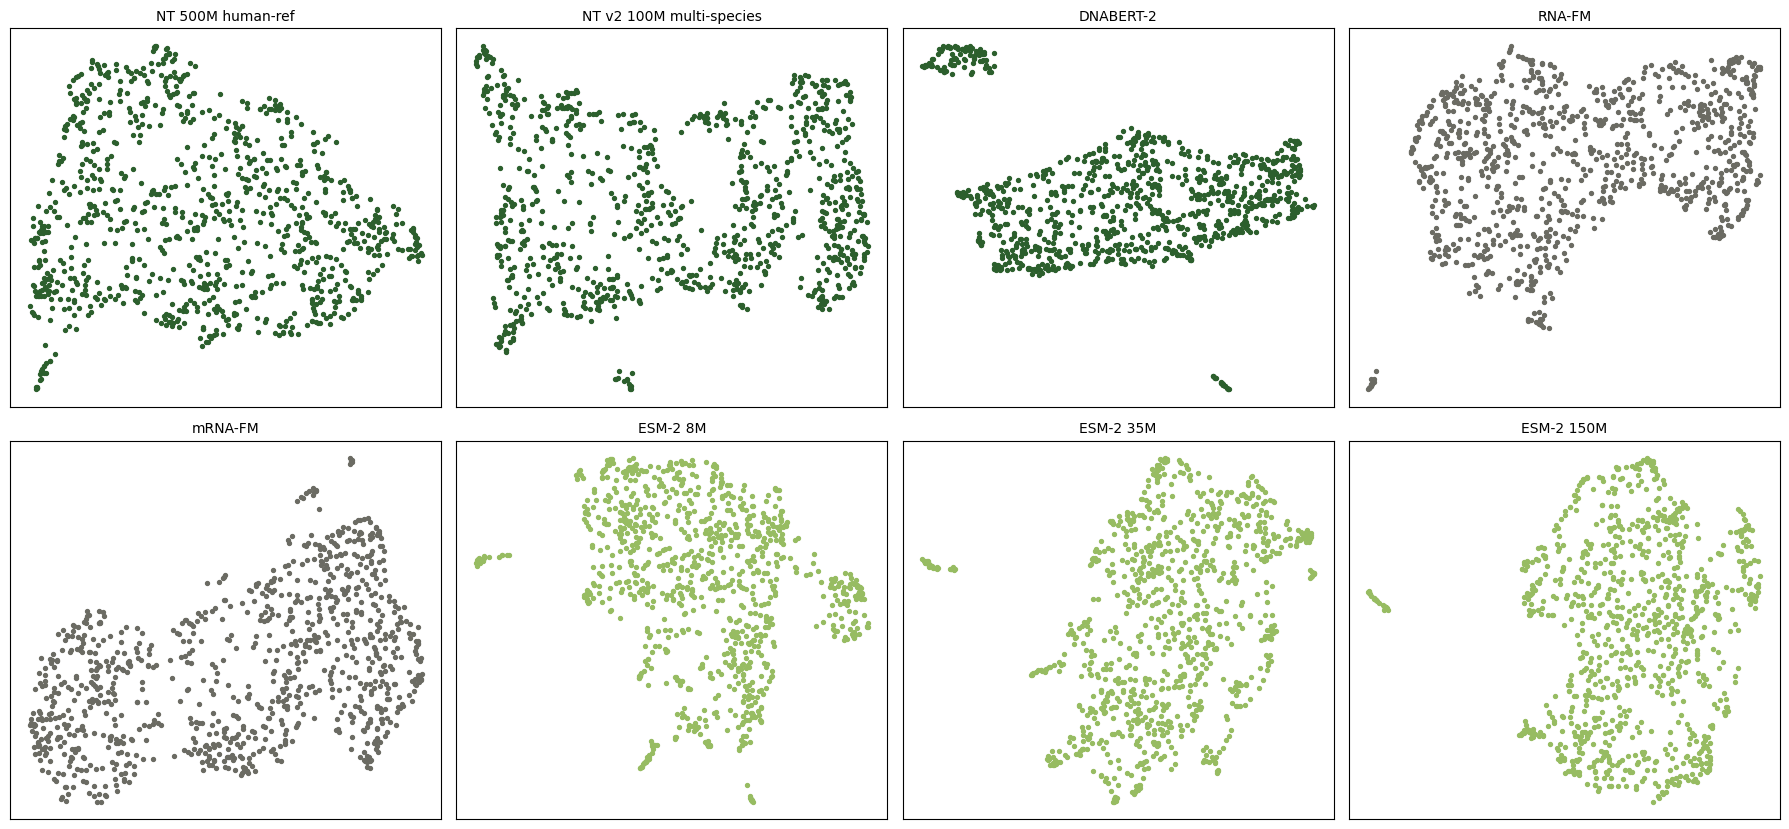

In [39]:
analysis.plot_umap(EMBEDDINGS, LABELS, MODALITY, seed=SEED)

**Reading the plots.** Most layouts show one broad cloud plus one or two small, tightly packed groups separated from it, as at the lower left of the Nucleotide Transformer 500M and RNA-FM layouts, below the Nucleotide Transformer v2 layout, and at the left of the three ESM-2 layouts. DNABERT-2 separates a larger group at the upper left. mRNA-FM is the only layout whose main cloud divides into two large lobes.

The small separated groups are candidates for sequences that differ systematically from the rest, such as unusual lengths, compositions, or source organisms. Their similar appearance across layouts does not establish that they contain the same rows, because each layout is fitted separately and the plots do not label points. Tracing the grouped points back to their rows, and checking their length, GC content, and source species, would test that; the same check would show what separates mRNA-FM's two lobes. The figures are exploratory and do not establish any biological grouping.

---

### Pipeline control: synonymous recoding

The `mRFP_Expression` control asks whether the pipeline behaves as expected when different nucleotide sequences encode the same protein. A synonymous recoding changes codons while retaining the amino-acid sequence. Identical translated strings should therefore give every protein encoder the same input, while the DNA and RNA encoders receive different inputs.

The code loads `CONTROL_DATASET` with `datasets.load_dataset`, which removes rows with missing sequences, samples `N_ROWS` rows with `SEED`, and applies the sequence filters. It then counts distinct translated protein strings among the retained rows, embeds the rows with every encoder, and examines each encoder's matrix separately to measure how spread out its rows are.

**1. Find the centroid: the average embedding.**

Treat each embedding as a point whose coordinates are its numerical features. The centroid is the average of those points, calculated one feature at a time:

$$
\bar{\mathbf z}
= \frac{1}{n}\sum_{i=1}^{n}\mathbf z_i.
$$

In this notation:

- $Z$ denotes the control embedding matrix of the encoder being examined, `CONTROL_EMBEDDINGS[key]`. Its shape is `(n, d)`.
- $n$ is the number of retained control rows in that matrix.
- $d$ is the number of embedding features in each row; the encoders have different feature counts.
- $i$ identifies an example row, from 1 through $n$ in the equation. Python indexes those same rows from 0 through `n - 1`.
- $\mathbf z_i$, read as "bold z sub i," is the embedding vector in row $i$. Bold symbols here represent vectors with $d$ coordinates.
- $\bar{\mathbf z}$, read as "z bar," is the centroid vector. The bar denotes the average across rows.
- $\sum_{i=1}^{n}$ means to add the row vectors coordinate by coordinate. Dividing by $n$ takes the average for each feature.

**2. Measure each embedding's distance from the centroid.**

Subtract the centroid from a row, then measure the length of that difference vector:

$$
r_i = \left\|\mathbf z_i-\bar{\mathbf z}\right\|_2.
$$

In this notation:

- $r_i$ is a single nonnegative number: the distance of row $i$ from the centroid.
- $\mathbf z_i-\bar{\mathbf z}$ subtracts the centroid's value from each corresponding feature in that row.
- $\|\cdot\|_2$ denotes Euclidean length: square each coordinate of the vector inside the bars, add the squares, and take the square root. The subscript 2 identifies this choice of norm; it does not mean the embedding has two features.

An embedding at the centroid has distance zero. A larger distance means that embedding lies farther from the average within this representation space.

**3. Average the distances to obtain one spread value.**

$$
\operatorname{spread}(Z)
= \frac{1}{n}\sum_{i=1}^{n}r_i.
$$

In this notation:

- $\operatorname{spread}(Z)$ names the mean distance for matrix $Z$. It is one scalar, not another embedding vector or a variance.
- $n$, $i$ and the summation have the same meanings as above; this time the quantities being averaged are the scalar distances $r_i$.

**Connection to the code.**

These equations describe the NumPy calculation in `analysis.centroid_spread`. There is no fitted model. The mathematical names for the centroid and individual distances explain intermediate results that the function calculates in one expression.

For one encoder's matrix `Z`, the calculation performs the following operations in order.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `Z.mean(axis=0)` | `(n, d)` → `(d,)` | Average down the example rows to obtain the centroid $\bar{\mathbf z}$. |
| `Z - Z.mean(axis=0)` | `(n, d)` → `(n, d)` | Subtract that same centroid from every row. |
| `np.linalg.norm(..., axis=1)` | `(n, d)` → `(n,)` | Combine the feature differences within each row into its distance $r_i$. |
| The final `.mean()` | `(n,)` → scalar | Average the distances to obtain $\operatorname{spread}(Z)$. |

The `...` in the table stands for the centered matrix from the preceding row. NumPy applies the centroid subtraction to every row automatically. With `axis=1` and the default norm setting, `np.linalg.norm` calculates Euclidean length across each row's features; see [NumPy's norm definition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html).

**Small worked example.**

Suppose there are two embeddings, $(1,2)$ and $(5,2)$, so $n=2$ and $d=2$.

1. Their centroid is $(3,2)$: each coordinate is the average of that feature's two values.
2. Subtracting the centroid gives $(-2,0)$ and $(2,0)$. Each difference vector has Euclidean length 2.
3. The spread is therefore $(2+2)/2=2$.

These are illustrative numbers, not encoder outputs.

**What this control can establish.**

Identical vectors have zero spread in exact arithmetic. Near-zero protein spread together with one distinct translated protein is consistent with the expected behavior for synonymous recodings; nonzero DNA and RNA spread shows variation among the nucleotide representations. Compare each matrix with its own centroid. Because the spaces have different dimensions and scales, their raw spread values do not form a normalized comparison of information content. This control checks this particular translation/embedding relationship, not every assumption or analysis elsewhere in the notebook.

In [40]:
show_source(analysis.centroid_spread)

```python
def centroid_spread(Z):
    """Mean Euclidean distance of the rows of Z from their centroid."""
    return np.linalg.norm(Z - Z.mean(axis=0), axis=1).mean()
```

In [41]:
control = datasets.load_dataset(CONTROL_DATASET, n_rows=N_ROWS, seed=SEED)
control_proteins = {sequences.translate_cds(s) for s in control.sequences}
print(
    f"Retained {len(control.sequences)} of {control.n_sampled} sampled control rows; "
    f"distinct translated proteins: {len(control_proteins)}."
)

CONTROL_EMBEDDINGS = {}
for encoder in ENCODERS:
    CONTROL_EMBEDDINGS[encoder.key], _ = embeddings.embed_with_cache(
        encoder, control.sequences, CONTROL_EMBEDDING_DIR, DEVICE
    )

pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "mean distance to centroid": [analysis.centroid_spread(CONTROL_EMBEDDINGS[k]) for k in ENCODER_KEYS]},
    index=[LABELS[k] for k in ENCODER_KEYS],
).round(5)

Retained 1000 of 1000 sampled control rows; distinct translated proteins: 1.


,modality,mean distance to centroid
NT 500M human-ref,DNA,4.72361
NT v2 100M multi-species,DNA,1.26535
DNABERT-2,DNA,0.74851
RNA-FM,RNA,0.81823
mRNA-FM,RNA,1.74951
ESM-2 8M,protein,0.00004
ESM-2 35M,protein,0.00004
ESM-2 150M,protein,0.00006


**Results.** All 1,000 retained variants translate to one identical protein.

| Encoder | Modality | Mean distance to centroid |
|---|---|---:|
| NT 500M human-ref | DNA | 4.72361 |
| NT v2 100M multi-species | DNA | 1.26535 |
| DNABERT-2 | DNA | 0.74851 |
| RNA-FM | RNA | 0.81823 |
| mRNA-FM | RNA | 1.74951 |
| ESM-2 8M | Protein | 0.00004 |
| ESM-2 35M | Protein | 0.00004 |
| ESM-2 150M | Protein | 0.00006 |

**Interpretation.** The pipeline behaves as expected for synonymous recodings. The embeddings of all three ESM-2 models are identical up to numerical rounding because every variant gives them the same input, while all five nucleotide encoders produce clearly different embeddings for different codon choices. This confirms that the protein branch is insensitive to synonymous changes by construction, and that every nucleotide branch responds to them.

The raw spreads cannot be compared across encoders, since the spaces have different widths and scales; only the contrast between near-zero protein spread and clearly nonzero nucleotide spread is meaningful. This control checks one translation and embedding behavior; it does not validate the reading-frame assumption or labels on the main dataset.

---

### Track C: Attention and exploratory diagnostics

Track A asks which targets a simple model can recover from the frozen embeddings. Track B compares the geometry of final-layer and intermediate representations. Track C examines a selected summary of attention in the nucleotide encoders listed in `ATTENTION_ENCODERS`, at candidate RNA motif positions, followed by exploratory alignment-error and representation-distance diagnostics for every pair of encoders.

Protein encoders are not included in the attention analysis because the candidate patterns are defined on nucleotide positions. An encoder whose model code does not return attention weights is reported and skipped. The attention analysis follows a sequence of transformations for each nucleotide encoder: extract self-attention weights, summarize them by token, map those summaries to nucleotide positions, scan the input for candidate patterns, and compare scores inside and outside the matched spans. The resulting plots and statistics describe the selected model behavior. A pattern match is not a validated regulatory site, and attention is not a direct assay of regulatory function.

These diagnostics can motivate specific follow-up experiments. An alignment-error correlation does not measure the effect of adding an alignment loss, and the observations do not select a fusion architecture by themselves.

#### Extracting self-attention from the frozen nucleotide encoders

The previous analyses used extracted representations, including those from intermediate layers. Here, `embeddings.attention_maps` requests `output_attentions=True` for one nucleotide sequence from one encoder at a time. These are **self-attention** weights: query and key positions belong to the same sequence and the same encoder, rather than to separate modalities.

Each layer returns an array with shape `(1, H, T, T)`. The leading 1 is the one-sequence batch size. Removing that axis leaves `(H, T, T)`: heads, query positions and key positions.

In this notation:

- $H$ is the number of attention heads in this layer. A head is one of the parallel attention computations.
- $T$ is the number of processed input tokens, including special tokens.
- $h$ identifies a head, while $q$ and $k$ identify a query and a key token position. The equations below count heads from 1 through $H$ and positions from 1 through $T$; NumPy indexes their axes from zero.
- $A^{(h)}_{qk}$ is one scalar weight assigned by query position $q$ to key position $k$ in head $h$. The parenthesized superscript selects a head; it is not a power. The two subscripts select a row and column of that head's attention matrix.

**Connection to the code.** Inside `attention_maps`, the model output's `attentions` holds the per-layer arrays. Indexing `[0]` removes the batch axis, and `.float().cpu().numpy()` returns that layer's weights as a NumPy array. `layers` selects which layers to convert; the analysis below requests only the final layer, which keeps memory use low for long inputs. The returned list preserves layer order, and the token strings come from the same model call. These weights participate in a weighted combination of value vectors; they are not a complete decomposition of the final representation or a direct measure of biological importance. See the attention construction in [Vaswani et al. (2017), Section 3.2](https://arxiv.org/html/1706.03762v7#S3.SS2) and the [ESM output definitions](https://huggingface.co/docs/transformers/en/model_doc/esm#transformers.EsmModel). RNA-FM, loaded through `multimolecule`, returns attention arrays with the same layout.

`encoders.load_encoder(encoder, device, eager_attention=True)` loads an encoder with `attn_implementation="eager"` to obtain the explicit attention weights used below; encoders built from their own model code use that code's attention implementation. This is a choice for attention inspection in this pipeline; support for returning weights depends on the model and attention backend. The [Transformers attention-backend documentation](https://huggingface.co/docs/transformers/en/attention_interface) explains how that argument selects the implementation. The embeddings computed earlier are unaffected.

Each loaded model is placed in evaluation mode, and inference runs inside `torch.no_grad()`. No parameter update is performed. Tokenization uses `truncation=True` with the same token limit as embedding extraction, the encoder's `max_len` in the registry. The returned token list describes this model call's processed input and may cover less than the full sequence; its coverage must be checked rather than assumed to match earlier extraction.


Loading an encoder with eager attention can print the same kind of weight report described in [Interpreting the loading messages](#Interpreting-the-loading-messages). Pooler parameters reported as newly initialized do not affect this analysis, which reads `outputs.attentions` and does not use a pooled output. The report should be interpreted in relation to the outputs consumed here, rather than treated as a general confirmation that every model component has pretrained weights.

In [42]:
show_source(embeddings.attention_maps)

```python
@torch.no_grad()
def attention_maps(text, tokenizer, model, device, max_len, layers=None):
    """Return self-attention arrays and token strings for one input string.

    Each array has shape (heads, query_tokens, key_tokens). layers selects which layers
    to return, all by default; converting only the needed layers saves memory for long
    inputs. The model must be loaded with eager attention so that it returns weights.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)
    attentions = model(**inputs, output_attentions=True).attentions
    chosen = range(len(attentions)) if layers is None else layers
    arrays = [attentions[i][0].float().cpu().numpy() for i in chosen]
    return arrays, tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
```

#### Summarizing attention and mapping tokens to nucleotides

`analysis.aggregate_attention` turns one layer's `(H, T, T)` array into one score per token. With `mode="incoming"`, the score summarizes how much attention a key position receives from all query positions after averaging heads. `layer=-1` selects the final transformer layer; this is the current analysis choice, not evidence that it is the most informative layer.

**1. Average the heads.**

$$
\bar A_{qk}=\frac{1}{H}\sum_{h=1}^{H}A^{(h)}_{qk}.
$$

In this notation:

- $A^{(h)}_{qk}$ is the selected layer's weight from query token $q$ to key token $k$ in head $h$, as defined above.
- $H$ is the number of heads; $h$ runs from 1 through $H$ in the equation.
- $q$ and $k$ each run from 1 through $T$, where $T$ is the processed token count, including special tokens.
- $\bar A$ is a `(T, T)` matrix. The bar means an average across heads at each fixed query/key pair; it does not average token positions.
- $\sum$ adds the $H$ weights for that pair, and division by $H$ gives their mean.

**2. Sum incoming weight for each key token.**

$$
s_k=\sum_{q=1}^{T}\bar A_{qk}.
$$

In this notation:

- $s_k$ is the incoming score for key token $k$ before rescaling.
- The sum varies the query index $q$ while holding $k$ fixed: it adds one column of $\bar A$.
- The full score vector has $T$ entries. It is a summary of attention weights, not an embedding vector of biological features.

**3. Rescale scores within this sequence.**

$$
\widetilde s_k=
\frac{s_k-\min_j s_j}{\max_j s_j-\min_j s_j+\varepsilon}.
$$

In this notation:

- $\widetilde s_k$ is the returned score; the tilde marks the rescaled quantity.
- $j$ ranges over all $T$ token positions. $\min_j s_j$ and $\max_j s_j$ are the smallest and largest incoming scores in this sequence.
- $\varepsilon=10^{-8}$ is the small constant `1e-8` in the code. It prevents division by zero when every score is equal; in that case all returned scores are zero.

This subtraction and division retain the ordering of unequal scores while changing their scale. For nonconstant scores, the maximum is below 1 in exact arithmetic because of the added constant; it approaches 1 when the score range is large relative to that constant. Scores are rescaled separately for each sequence, so equal displayed scores from different sequences are not calibrated to the same amount of incoming attention. Special-token positions participate in all three steps.

**Connection to the code.** These are direct array operations inside `aggregate_attention`; none of the three equations fits a model.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `attentions[layer].mean(axis=0)` | `(H, T, T)` → `(T, T)` | Compute the head average $\bar A$. |
| `layer_att.sum(axis=0)` | `(T, T)` → `(T,)` | Sum query rows to obtain the incoming scores $s_k$. |
| `(score - score.min()) / (score.max() - score.min() + 1e-8)` | `(T,)` → `(T,)` | Return the rescaled scores $\widetilde s_k$. |

The axes have different meanings at each step: after averaging removes the head axis, axis 0 refers to query positions. Any `mode` value other than `"incoming"` selects `sum(axis=1)` instead, producing outgoing row sums; the calls in this notebook use `"incoming"`.

For an illustrative head-averaged matrix with rows `(0.8, 0.2)` and `(0.4, 0.6)`, the incoming scores are `(1.2, 0.8)`. Rescaling gives approximately `(1, 0)`. This example describes the calculation, not an observed model output or a claim that the second token has no biological role.

**Map token scores to nucleotide positions.**

The motif scan uses nucleotide positions rather than token positions. The [Nucleotide Transformer model card](https://huggingface.co/InstaDeepAI/nucleotide-transformer-500m-human-ref#preprocessing) describes six-nucleotide tokens where possible and individual-nucleotide tokens otherwise. RNA-FM uses one token per nucleotide, so each of its token scores maps to exactly one position. DNABERT-2's byte-pair tokens cover a variable number of nucleotides, and mRNA-FM's tokens cover one codon each. `analysis.expand_token_attention_to_nucleotides`:

1. Pairs each token string with its returned score.
2. Skips strings beginning with `<` or `[`, the helper's rule for special tokens.
3. Repeats each remaining score once per character in that token and appends the copies in token order.

For example, if `ACGTAC` is the first retained DNA-encoder token and has score 0.25, expanded positions 0 through 5 all receive 0.25. This copies one token score onto six positions; it does not estimate six independent nucleotide scores. For RNA-FM, a token `A` with score 0.25 fills only position 0. No further normalization occurs after removing special tokens.

The mapping assumes the retained token strings spell the covered nucleotides in order. It is not a general mapping for arbitrary tokenizers or unknown-token behavior, and it cannot restore positions removed by truncation. RNA-FM's token limit covers at most 1,022 nucleotides, so its expanded array is shorter than the sequence for most inputs; pattern matches beyond that point are clipped by the comparison below. The example execution prints sequence and expanded-array lengths as a diagnostic; it does not enforce equality.

In [43]:
show_source(analysis.aggregate_attention, analysis.expand_token_attention_to_nucleotides, embeddings.nucleotide_attention)

```python
def aggregate_attention(attentions, layer=-1, mode="incoming"):
    """Summarize one layer and min-max rescale its token-position scores.

    Incoming scores sum over queries after averaging heads. Other mode values
    use row sums. Special-token positions remain included at this step.
    """
    layer_att = attentions[layer].mean(axis=0)  # (query_tokens, key_tokens)
    score = layer_att.sum(axis=0) if mode == "incoming" else layer_att.sum(axis=1)
    score = (score - score.min()) / (score.max() - score.min() + 1e-8)
    return score
```

```python
def expand_token_attention_to_nucleotides(attn_score, tokens):
    """Repeat scores by token-string length after excluding special tokens.

    Assumes retained token strings spell the covered nucleotides in order.
    The expansion cannot restore sequence positions removed by truncation.
    """
    expanded = []
    for score, tok in zip(attn_score, tokens):
        if tok.startswith("<") or tok.startswith("["):
            continue
        expanded.extend([score] * len(tok))
    return np.array(expanded)
```

```python
def nucleotide_attention(seq, encoder, tokenizer, model, device, layer=-1):
    """Return one layer's incoming attention, min-max scaled and expanded to nucleotides."""
    arrays, tokens = attention_maps(
        encoder_input(encoder, seq), tokenizer, model, device, encoder.max_len, layers=[layer]
    )
    return expand_token_attention_to_nucleotides(aggregate_attention(arrays, layer=0), tokens)
```

#### Scanning candidate RNA stability-associated patterns

The scan creates **candidate sequence-pattern annotations** for the attention comparison. It searches the input sequence for three RNA-relevant patterns; it does not measure binding, modification, or a change in stability.

| Pattern | What the scan identifies | Interpretation limit |
|---|---|---|
| AUUUA | ARE-associated pentamer | A match alone does not establish an active AU-rich element or altered stability. |
| UUAUUUAUU | ARE-associated nonamer | Contains the pentamer; these are related patterns rather than independent mechanistic classes. |
| DRACH | Consensus associated with candidate m6A sites | D = A/G/U, R = A/G, H = A/C/U. The central A is a potential methylation site; a match does not establish methylation. |

The ARE patterns have experimental precedent in [Zubiaga et al. (1995)](https://pmc.ncbi.nlm.nih.gov/articles/PMC230450/). Single-nucleotide mapping shows that only a subset of DRACH candidates are methylated; see [Linder et al. (2015)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4487409/). Motif occurrence, molecular modification or binding, and a functional effect on stability are distinct claims.

`sequences.iupac_to_regex` converts each IUPAC symbol to its permitted letters in the DNA alphabet. For example, DRACH becomes `[AGT][AG]AC[ACT]`, with U represented as T to match the converted sequence. `sequences.find_iupac_matches` uses a regex lookahead to include overlapping occurrences. It returns zero-based, end-exclusive intervals: `start` is covered and `end` is the first position after the match. `sequences.scan_sequence_for_motifs` adds the pattern name to each span. Subsequent masks cover the entire matched span, including all five DRACH positions, rather than only its central A.

These annotations depend only on sequence and require no external database call. The [CodonBERT source repository](https://github.com/Sanofi-Public/CodonBERT) links the stability task to [iCodon](https://www.nature.com/articles/s41598-022-15526-7), which studies coding-sequence codon composition. The exact region and label mapping for the local CSV still need verification; its columns do not establish UTR coverage. Presence or absence of these patterns therefore needs interpretation in the context of the sequence region.

In [44]:
show_source(sequences.iupac_to_regex, sequences.find_iupac_matches, sequences.scan_sequence_for_motifs)

```python
def iupac_to_regex(pattern):
    """Convert an IUPAC consensus pattern to a regex on the DNA alphabet."""
    return "".join(_IUPAC[b] for b in pattern.upper())
```

```python
def find_iupac_matches(sequence, iupac_pattern):
    """Return all matching zero-based, end-exclusive spans, including overlaps."""
    seq = sequence.upper().replace("U", "T")
    regex = iupac_to_regex(iupac_pattern)
    length = len(iupac_pattern)
    return [
        (m.start(), m.start() + length)
        for m in re.finditer(f"(?={regex})", seq)
    ]
```

```python
def scan_sequence_for_motifs(sequence, motifs=STABILITY_MOTIFS):
    """Return (start, end, motif_name) for each consensus match, including overlaps.

    Spans are zero-based and end-exclusive; a match is a candidate annotation, not a
    validated regulatory site.
    """
    return [
        (start, end, name)
        for name, pattern in motifs.items()
        for start, end in find_iupac_matches(sequence, pattern)
    ]
```

#### Comparing attention at matched and other positions

`analysis.attention_motif_overlap` compares expanded attention scores at candidate-pattern positions with scores at the other covered positions in the same sequence. It forms the union of matched spans for the pooled comparison, counting each position once, then repeats the comparison separately for each pattern name. Match ends are clipped to the attention array's length. For a per-pattern comparison, the other-position group can include positions matching a different pattern.

**1. Average the scores at matched positions.**

$$
\bar\alpha_M=\frac{1}{n_M}\sum_{p\in M}\alpha_p.
$$

In this notation:

- $L$ is the length of `attention_score`, the expanded array. Its Python positions run from 0 through `L - 1`; this need not cover the full original sequence after truncation.
- $p$ is one nucleotide-array position, rather than an example row or a p-value.
- $\alpha_p$ is the expanded attention score at position $p$. The Greek letter alpha names the value; it is not a biological measurement or a fitted coefficient.
- $M$ is the set of positions inside at least one of the spans being compared; $n_M=|M|$ is its size. The bars count distinct positions, so overlaps do not increase the count twice.
- $p\in M$ means that $p$ belongs to that set. The summation adds the scores at those positions, and division by $n_M$ takes their mean.
- $\bar\alpha_M$ is the resulting scalar mean. The bar denotes an average, and subscript $M$ identifies the group.

**2. Average the scores at the other positions.**

$$
\bar\alpha_O=\frac{1}{n_O}\sum_{p\in O}\alpha_p.
$$

In this notation:

- $O$ is the complement of $M$ within the expanded array: every covered position that is not in $M$.
- $n_O=|O|$ counts those other positions; together, $n_M+n_O=L$.
- $\bar\alpha_O$ is their scalar mean. The summation and bar have the same meanings as in step 1, applied to the other group.

Both means require a nonempty group. The nested `_test` helper returns `None` if either group is empty. That marks an unavailable comparison, not a zero effect; an unavailable pooled comparison makes the outer function return `None` too.

**3. Distinguish the mean gap from the rank test.**

The two returned means also define a descriptive difference:

$$
\Delta=\bar\alpha_M-\bar\alpha_O.
$$

In this notation:

- $\Delta$, read as “delta,” is the matched-minus-other mean gap. Positive values mean the matched group has a larger average score; negative values mean it has a smaller one.
- The two mean symbols refer to steps 1 and 2. Their difference is in the same rescaled score units, rather than a probability.

For example, matched scores `(0.2, 0.4)` have mean 0.3, while other scores `(0.1, 0.1)` have mean 0.1. Their gap is 0.2. This illustrative calculation does not determine the rank test's p-value.

The one-sided Mann-Whitney U call uses `alternative="greater"` to examine a tendency toward larger scores in the matched group. It compares ranks/distributions, rather than directly testing whether $\Delta$ is positive. The standard null is equality of the two underlying distributions, with an alternative of stochastically greater matched scores; see [SciPy's Mann-Whitney U documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

**Connection to the code.** The means are calculated now; the subtraction is performed later in the multi-sequence summary.

| Code operation | Result | Connection to the calculation |
|---|---|---|
| `_test`: select `at` and `off` from `attention_score` | Arrays with shapes `(n_M,)` and `(n_O,)` | Gather the scores in $M$ and its complement $O$. |
| `at.mean()` and `off.mean()` | Two scalars stored in the returned dictionary | Compute $\bar\alpha_M$ and $\bar\alpha_O$. |
| `mannwhitneyu(at, off, alternative="greater")` | A U statistic and a nominal p-value | SciPy performs the rank test; the dictionary retains its p-value. |
| Later, in `analysis.attention_summary` | One difference per usable sequence, followed by an average | Subtract the dictionary's two mean fields to compute each $\Delta$. |

There is no returned `Delta` field or separate gap function in `attention_motif_overlap`. The equation names a quantity formed from its outputs by `attention_summary` in [Running the attention-motif analysis](#Running-the-attention-motif-analysis).

Treat the p-values as **nominal**: they are the test's reported values without calibration for this positional setting. Expanding token scores repeats values; neighboring positions are dependent; patterns can overlap; and many sequence/pattern comparisons are performed without multiplicity correction. Sequence composition and tokenization can also affect both masks and scores. A small p-value or positive mean gap identifies a candidate association for follow-up, not evidence that the encoder learned functional RNA regulation. Calibrated null models and experimentally supported annotations require a separate methodological decision.

In [45]:
show_source(analysis.attention_motif_overlap)

```python
def attention_motif_overlap(attention_score, motif_hits):
    """Return descriptive means and nominal one-sided rank-test p-values.

    Compare the union of covered positions with its complement, then repeat
    by pattern. Return None when the pooled comparison has an empty group.
    """
    def _test(positions):
        """Compare one position set with all other positions in the array."""
        non_positions = set(range(len(attention_score))) - positions
        if not positions or not non_positions:
            return None
        at = attention_score[list(positions)]
        off = attention_score[list(non_positions)]
        stat, pval = mannwhitneyu(at, off, alternative="greater")
        return {
            "mean_attention_at_motifs": at.mean(),
            "mean_attention_elsewhere": off.mean(),
            "n_motif_positions": len(positions),
            "p_value": pval,
        }

    all_positions = set()
    by_name = {}
    for start, end, name in motif_hits:
        positions = set(range(start, min(end, len(attention_score))))
        all_positions.update(positions)
        by_name.setdefault(name, set()).update(positions)

    result = _test(all_positions)
    if result is None:
        return None
    result["by_motif"] = {
        name: _test(positions) for name, positions in by_name.items()
    }
    return result
```

#### Plotting attention and candidate pattern spans

`analysis.plot_attention_with_motifs` combines the expanded attention array and the sequence-pattern matches in one figure. The black line shows the rescaled attention summary at each covered nucleotide index. Colored bands show matched spans, with one legend entry per pattern type. A token's repeated score can produce a flat segment across several nucleotide positions.

The plot is a qualitative companion to the numerical comparison: it makes peaks and candidate spans visible on the same coordinate axis. Visual overlap alone does not establish regulatory function or a statistically calibrated association. The plotting code draws the supplied spans as given, so interpreting the full sequence requires that attention coverage and motif coordinates agree.

In [46]:
show_source(analysis.plot_attention_with_motifs)

```python
def plot_attention_with_motifs(attention_score, motif_hits, title=""):
    """Plot expanded attention scores and candidate sequence-pattern spans."""
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(attention_score, color="black", linewidth=1)
    ax.fill_between(
        range(len(attention_score)), attention_score, color="gray", alpha=0.15
    )
    seen = set()
    for start, end, name in motif_hits:
        color = MOTIF_COLORS.get(name, "gray")
        ax.axvspan(
            start, end, color=color, alpha=0.35,
            label=name if name not in seen else None,
        )
        seen.add(name)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Attention score (normalized)")
    ax.set_title(title)
    if seen:
        ax.legend(loc="upper right", fontsize=8, ncol=len(seen))
    plt.tight_layout()
    plt.show()
```

#### Running the attention-motif analysis

The first execution follows one retained sequence through the complete pipeline for each nucleotide encoder in `ATTENTION_ENCODERS`: convert its alphabet for that encoder, extract attention, summarize the final layer, expand token scores, scan candidate patterns, compare groups, and plot the result. `embeddings.nucleotide_attention` performs the first four steps. The printed sequence and attention-array lengths help inspect coverage, but they are not an assertion that the coordinates agree for every input.

The second execution, `embeddings.attention_motif_tests`, repeats the attention extraction and pattern comparisons for the **first `ATTENTION_N_ROWS` retained sequences**, currently 100, separately for each encoder, and keeps rows with an available pooled comparison. `analysis.attention_summary` then calculates two summaries per encoder and pattern. The results are stored in `attention_results`. The equations below describe this second execution, the code cell after the single-example result.

**1. Count nominal threshold crossings.**

$$
f_{0.05}=\frac{1}{m}\sum_{i=1}^{m}\mathbf{1}\{p_i<0.05\}.
$$

In this notation:

- $m$ is the number of sequences with a usable comparison, and must be greater than zero for this calculation.
- $i$ indexes those usable sequences from 1 through $m$. It does not index nucleotide positions within one sequence.
- $p_i$ is the nominal Mann-Whitney p-value returned for sequence $i$.
- $\mathbf{1}\{p_i<0.05\}$ is an indicator: 1 if that p-value is below 0.05, otherwise 0. The braces state the condition being counted.
- $\sum$ adds these zeros and ones; dividing by $m$ gives the fraction $f_{0.05}$. Its subscript identifies the chosen threshold, not a sequence position.

**2. Average the per-sequence mean gaps.**

$$
\overline{\Delta}=\frac{1}{m}\sum_{i=1}^{m}\Delta_i.
$$

In this notation:

- $\Delta_i$ is the matched-minus-other mean attention gap for sequence $i$, as defined in the comparison section. It is calculated from that sequence's two returned mean fields.
- $\overline{\Delta}$ is the mean of those gaps; the bar marks the average across sequences.
- $m$, $i$ and the summation refer to the same usable sequence set as in step 1. Each sequence has equal weight, irrespective of its number of nucleotide positions or matches.

For example, if three usable sequences have p-values `(0.01, 0.20, 0.04)` and gaps `(0.02, -0.01, 0.05)`, the threshold fraction is $2/3$ and the mean gap is $0.06/3=0.02$. These are illustrative values. The fraction is not itself a p-value, and the average gap is not a test pooling all nucleotide positions across sequences.

**Connection to the code.** These are direct summaries of the dictionaries collected in `attention_results`.

| Code operation | Result | Connection to the mathematics |
|---|---|---|
| `attention_motif_tests` appends a result when it is not `None` | A list of usable comparison dictionaries per encoder | Determines the included sequence set and $m$ for that encoder. |
| `np.mean([g["p_value"] < 0.05 for g in group])` | The `fraction with nominal p < 0.05` column | NumPy counts `True` as 1 and `False` as 0, implementing $f_{0.05}$. |
| Subtract the two mean fields inside the `mean gap` list comprehension | One gap per dictionary | Computes each $\Delta_i$. |
| `np.mean(...)` around that list | The `mean gap` column | Computes $\overline{\Delta}$. |

Each pattern row repeats these operations using only dictionaries with an available comparison for that pattern. Its usable count can differ from the pooled count or another pattern's count. A pattern with no usable comparison appears with zero sequences and empty summary columns.

The table's label “fraction with nominal p < 0.05” refers only to crossing the unadjusted 0.05 threshold. They do not establish calibrated statistical significance under the dependence and multiple-comparison limitations described above. The single example illustrates the calculation; the 100-sequence summary describes the selected sample under the same procedure.

In [47]:
show_source(embeddings.attention_motif_tests, analysis.attention_summary)

```python
def attention_motif_tests(encoder, seqs, device, layer=-1):
    """Run attention_motif_overlap on each sequence for one nucleotide encoder.

    Returns the usable results (sequences with an available pooled comparison). The
    encoder is loaded with eager attention and released afterwards.
    """
    tokenizer, model = load_encoder(encoder, device, eager_attention=True)
    results = []
    for seq in seqs:
        attention = nucleotide_attention(seq, encoder, tokenizer, model, device, layer=layer)
        result = attention_motif_overlap(attention, scan_sequence_for_motifs(seq))
        if result is not None:
            results.append(result)
    del model, tokenizer
    free_memory()
    return results
```

```python
def attention_summary(results_by_encoder, labels, motifs):
    """Return one row per encoder and pattern: usable sequences, nominal p < 0.05 share, mean gap.

    results_by_encoder maps an encoder key to its list of attention_motif_overlap results.
    The pooled row uses every result; each pattern row uses only the results with an
    available comparison for that pattern.
    """
    rows = []
    for key, results in results_by_encoder.items():
        groups = {"All patterns pooled": results}
        for motif in motifs:
            groups[motif] = [r["by_motif"][motif] for r in results if r["by_motif"].get(motif)]
        for motif, group in groups.items():
            row = {"encoder": labels[key], "pattern": motif, "sequences with hits": len(group)}
            if group:
                row["fraction with nominal p < 0.05"] = np.mean([g["p_value"] < 0.05 for g in group])
                row["mean gap"] = np.mean(
                    [g["mean_attention_at_motifs"] - g["mean_attention_elsewhere"] for g in group]
                )
            rows.append(row)
    return pd.DataFrame(rows).set_index(["encoder", "pattern"])
```

Example sequence: 2556 nucleotides, 63 candidate matches.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NT 500M human-ref: 2556 positions covered, 311 matched; mean attention at matches 0.00310, elsewhere 0.00325, nominal p 0.603


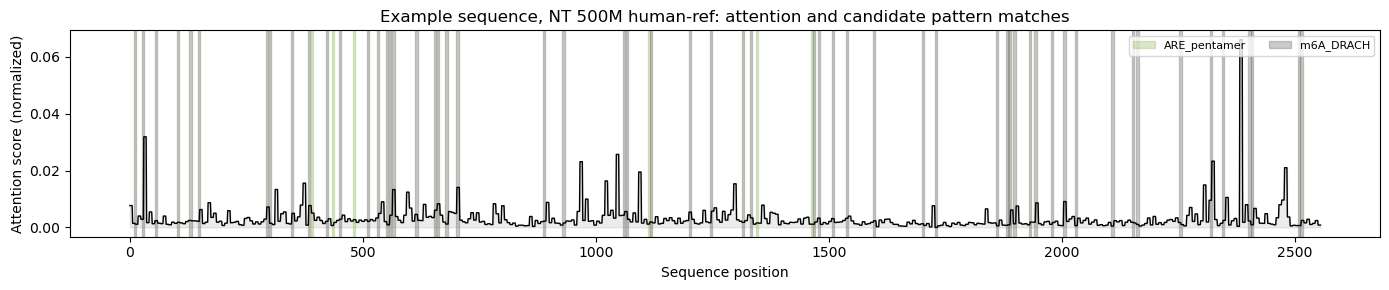

NT v2 100M multi-species: 2556 positions covered, 311 matched; mean attention at matches 0.13401, elsewhere 0.11912, nominal p 0.000


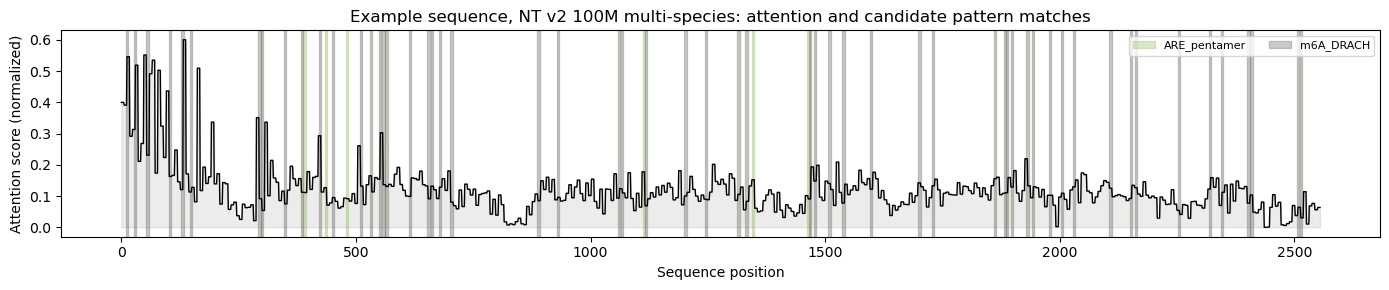

/Users/julianmckinley/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT_hyphen_2_hyphen_117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


DNABERT-2: attention weights unavailable (AttributeError: 'tuple' object has no attribute 'attentions')


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/rnafm
Key                                 | Status     | 
------------------------------------+------------+-
ss_head.decoder.bias                | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RNA-FM: 1022 positions covered, 135 matched; mean attention at matches 0.01722, elsewhere 0.01375, nominal p 0.068


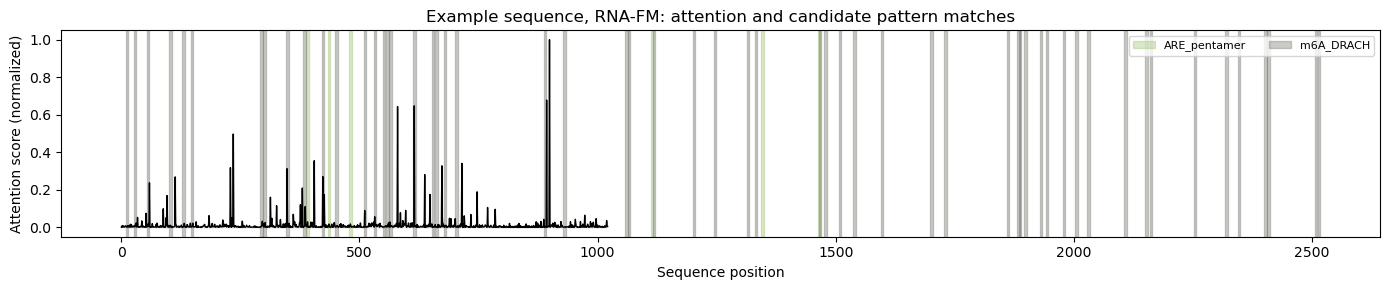

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/mrnafm
Key                                 | Status     | 
------------------------------------+------------+-
ss_head.decoder.bias                | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mRNA-FM: 2556 positions covered, 311 matched; mean attention at matches 0.00179, elsewhere 0.00123, nominal p 0.000


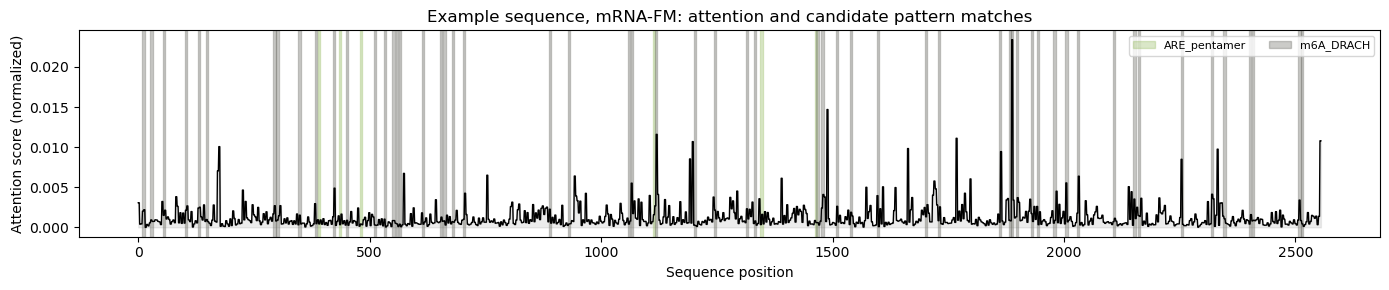

In [48]:
sample_seq = kept_seqs[0]
motif_hits = sequences.scan_sequence_for_motifs(sample_seq)
print(f"Example sequence: {len(sample_seq)} nucleotides, {len(motif_hits)} candidate matches.")

for key in ATTENTION_ENCODERS:
    encoder = encoders.ENCODERS[key]
    tokenizer, model = encoders.load_encoder(encoder, DEVICE, eager_attention=True)
    try:
        attention = embeddings.nucleotide_attention(sample_seq, encoder, tokenizer, model, DEVICE)
    except Exception as error:
        print(f"{encoder.label}: attention weights unavailable ({type(error).__name__}: {error})")
        continue
    finally:
        del model, tokenizer
        encoders.free_memory()
    result = analysis.attention_motif_overlap(attention, motif_hits)
    if result is None:
        print(f"{encoder.label}: no usable comparison for this sequence")
        continue
    print(
        f"{encoder.label}: {len(attention)} positions covered, {result['n_motif_positions']} matched; "
        f"mean attention at matches {result['mean_attention_at_motifs']:.5f}, "
        f"elsewhere {result['mean_attention_elsewhere']:.5f}, nominal p {result['p_value']:.3f}"
    )
    analysis.plot_attention_with_motifs(
        attention, motif_hits, title=f"Example sequence, {encoder.label}: attention and candidate pattern matches"
    )

**Results.** The example sequence is 2,556 nucleotides long with 63 candidate matches covering 311 positions.

| Encoder | Positions covered | Matched positions | Mean attention at matches | Mean elsewhere | Nominal $p$ |
|---|---:|---:|---:|---:|---:|
| NT 500M human-ref | 2,556 | 311 | 0.00310 | 0.00325 | 0.603 |
| NT v2 100M multi-species | 2,556 | 311 | 0.13401 | 0.11912 | below 0.001 |
| RNA-FM | 1,022 | 135 | 0.01722 | 0.01375 | 0.068 |
| mRNA-FM | 2,556 | 311 | 0.00179 | 0.00123 | below 0.001 |

DNABERT-2's model code returns its outputs as a tuple without attention weights, so it is reported as unavailable and left out of the attention analysis.

**Interpretation.** Coverage follows the tokenizers. Both Nucleotide Transformer models and mRNA-FM cover the whole sequence, because each token spells up to six nucleotides or one codon, while RNA-FM covers only its first 1,022 nucleotides and excludes the matches beyond them. For this sequence, Nucleotide Transformer 500M attends slightly less to matched positions than to others and RNA-FM slightly more, with neither difference reaching the nominal 0.05 threshold. Nucleotide Transformer v2 and mRNA-FM give more attention to matched positions, with very small nominal $p$-values.

The plots show why those $p$-values need care. Nucleotide Transformer v2's attention is highest over roughly the first 200 nucleotides and lower afterwards, so matches near the start gain attention from position alone. mRNA-FM's attention is concentrated in a few sharp peaks, and each codon's score is repeated over its three positions. A single example illustrates the calculation; it does not establish a biological association, and the positional test has the dependence and calibration limitations described above.

In [49]:
attention_results = {}
for key in ATTENTION_ENCODERS:
    try:
        attention_results[key] = embeddings.attention_motif_tests(
            encoders.ENCODERS[key], kept_seqs[:ATTENTION_N_ROWS], DEVICE
        )
    except Exception as error:
        print(f"{LABELS[key]}: attention weights unavailable ({type(error).__name__}: {error})")
        encoders.free_memory()

analysis.attention_summary(attention_results, LABELS, sequences.STABILITY_MOTIFS).round(4)

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DNABERT-2: attention weights unavailable (AttributeError: 'tuple' object has no attribute 'attentions')


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/rnafm
Key                                 | Status     | 
------------------------------------+------------+-
ss_head.decoder.bias                | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/mrnafm
Key                                 | Status     | 
------------------------------------+------------+-
ss_head.decoder.bias                | UNEXPECTED | 
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


sequences with hits  \
encoder                  pattern                                    
NT 500M human-ref        All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
NT v2 100M multi-species All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
RNA-FM                   All patterns pooled                  100   
                         ARE_pentamer                          33   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   
mRNA-FM                  All patterns pooled                  100   
                         ARE_pentamer                          41   
                         ARE_nonamer                            0   
                         m6A_DRACH                            100   

                                              fraction with nominal p < 0.05  \
encoder                  pattern                                               
NT 500M human-ref        All patterns pooled                          0.0700   
                         ARE_pentamer                                 0.0488   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.0800   
NT v2 100M multi-species All patterns pooled                          0.1500   
                         ARE_pentamer                                 0.3415   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.1400   
RNA-FM                   All patterns pooled                          0.0900   
                         ARE_pentamer                                 0.1212   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.0800   
mRNA-FM                  All patterns pooled                          0.9300   
                         ARE_pentamer                                 0.0976   
                         ARE_nonamer                                     NaN   
                         m6A_DRACH                                    0.9200   

                                              mean gap  
encoder                  pattern                        
NT 500M human-ref        All patterns pooled   -0.0009  
                         ARE_pentamer          -0.0027  
                         ARE_nonamer               NaN  
                         m6A_DRACH             -0.0009  
NT v2 100M multi-species All patterns pooled   -0.0042  
                         ARE_pentamer           0.0110  
                         ARE_nonamer               NaN  
                         m6A_DRACH             -0.0051  
RNA-FM                   All patterns pooled   -0.0015  
                         ARE_pentamer          -0.0006  
                         ARE_nonamer               NaN  
                         m6A_DRACH             -0.0016  
mRNA-FM                  All patterns pooled    0.0014  
                         ARE_pentamer          -0.0011  
                         ARE_nonamer               NaN  
                         m6A_DRACH              0.0015

**Results.** First 100 retained sequences; every sequence had at least one usable match, and none contained the ARE nonamer.

| Encoder | Pattern | Sequences with hits | Fraction with nominal $p<0.05$ | Mean gap |
|---|---|---:|---:|---:|
| NT 500M human-ref | All patterns pooled | 100 | 0.07 | $-0.0009$ |
| NT 500M human-ref | ARE pentamer | 41 | 0.05 | $-0.0027$ |
| NT 500M human-ref | m6A DRACH | 100 | 0.08 | $-0.0009$ |
| NT v2 100M multi-species | All patterns pooled | 100 | 0.15 | $-0.0042$ |
| NT v2 100M multi-species | ARE pentamer | 41 | 0.34 | $+0.0110$ |
| NT v2 100M multi-species | m6A DRACH | 100 | 0.14 | $-0.0051$ |
| RNA-FM | All patterns pooled | 100 | 0.09 | $-0.0015$ |
| RNA-FM | ARE pentamer | 33 | 0.12 | $-0.0006$ |
| RNA-FM | m6A DRACH | 100 | 0.08 | $-0.0016$ |
| mRNA-FM | All patterns pooled | 100 | 0.93 | $+0.0014$ |
| mRNA-FM | ARE pentamer | 41 | 0.10 | $-0.0011$ |
| mRNA-FM | m6A DRACH | 100 | 0.92 | $+0.0015$ |

**Interpretation.** Nucleotide Transformer 500M and RNA-FM show no higher final-layer incoming attention at these candidate stability patterns: their mean gaps are slightly negative, and their threshold fractions stay between 5% and 12%, near the 5% expected if attention and pattern positions were unrelated; the highest, RNA-FM's ARE pentamer fraction, rests on 4 of 33 sequences.

Two encoders depart from that rate, in ways that call for controls before any biological reading. Nucleotide Transformer v2 gives more attention to ARE pentamers in 14 of 41 sequences, with a positive mean gap, while its pooled and DRACH gaps are negative; its attention also concentrates near the start of each sequence, so a pattern's position can produce this result. mRNA-FM crosses the nominal threshold in 93 of 100 sequences, almost entirely through DRACH matches, but its mean gap is only 0.0015 on a zero-to-one scale. With about 2,500 positions per sequence and each codon score repeated over three positions, the rank test detects very small systematic shifts, and DRACH matches constrain which codons they overlap, so codon composition alone could produce this shift. Testing either result needs a null that preserves position or codon composition, such as comparing against shuffled pattern positions within the same codon classes.

The results are limited to these candidate patterns, 100 sequences, and final-layer incoming attention averaged over heads. They do not establish whether the encoders represent regulatory elements: attention in other layers or heads, or information carried in hidden states rather than attention weights, is not tested. The threshold fractions are not calibrated tests, because of positional dependence, repeated token scores, and multiple comparisons.

#### Sample-level alignment and prediction error

This diagnostic asks whether examples whose representations in two modalities are more similar also tend to be easier to predict. It is run once for every pair of encoders. It is an **exploratory sample-level adaptation** inspired by [Tjandrasuwita et al. (ICML 2025), Sections 5-6](https://proceedings.mlr.press/v267/tjandrasuwita25a.html). The paper studies relationships across models/configurations and a contrastive-training intervention; this code compares examples from one fixed encoder pair at a time. It does not reproduce those experiments.

For each pair `(a, b)`, the later call supplies the two coordinate matrices stored in `cca_results[(a, b)]["test_coords"]` and `labels[test_idx]`: matched CCA coordinates and stability labels from the earlier CCA test subset. Corresponding rows must identify the same examples. The encoder weights and the earlier fitted PCA/CCA transformations remain fixed here; the new models fitted in this diagnostic are ordinary linear regressions.

**1. Compare the directions of each example's paired CCA vectors.**

For nonzero vectors, cosine similarity is:

$$
c_i = \frac{\mathbf u_i^\top\mathbf v_i}
{\|\mathbf u_i\|_2\,\|\mathbf v_i\|_2}.
$$

In this notation:

- $n$ is the number of paired examples supplied to this diagnostic; each input coordinate matrix has shape `(n, d)`.
- $i$ identifies one example, from 1 through $n$ in the equations. Python indexes those rows from 0 through `n - 1`.
- $d$ is the number of CCA coordinates per vector, currently 10.
- $\mathbf u_i$ and $\mathbf v_i$ are the CCA vectors of the pair's first and second encoders for example $i$. Bold symbols denote vectors; each has $d$ coordinates. The mathematics treats them as column vectors even though the NumPy matrices store examples in rows.
- $\top$ means transpose: it turns the mathematical column $\mathbf u_i$ into a row so that $\mathbf u_i^\top\mathbf v_i$ is a dot product. This multiplies corresponding coordinates and sums those products, giving one scalar.
- $\|\mathbf u_i\|_2$ and $\|\mathbf v_i\|_2$ are Euclidean lengths: square the coordinates, add them, and take the square root. The subscript 2 names the norm, not the number of coordinates.
- $c_i$ is one cosine score, between $-1$ and $1$ for nonzero vectors. A larger value means their directions are more similar in the fitted CCA coordinates. It is a chosen per-example alignment score, not a biological measurement.

The notebook delegates this calculation to [scikit-learn's `cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html). Each `i:i+1` slice retains shape `(1, d)`; the resulting `(1, 1)` similarity matrix contains one score, selected by `[0, 0]`. The displayed ratio is undefined for a zero vector, whereas the library returns zero for a comparison involving a zero vector; that value does not define its direction.

**2. Combine the coordinates and obtain an error from a model that did not train on that row.**

Concatenation appends the second encoder's coordinates after the first encoder's coordinates:

$$
\mathbf z_i = [\mathbf u_i;\mathbf v_i].
$$

In this notation:

- $\mathbf z_i$ is the combined feature vector for example $i$, with $2d$ coordinates, currently 20.
- The brackets and semicolon mean to append the two vectors' coordinates in the stated order. They do not average or multiply the vectors.
- The NumPy array `fused` stores these combined vectors as rows, with shape `(n, 2d)`.

The code divides these $n$ examples into five shuffled folds using `SEED`. For each fold, scikit-learn's `LinearRegression().fit(...)` fits an intercept and coefficients on the other folds by ordinary least squares. Its `.predict(...)` call predicts the held-out fold. The notebook then calculates each row's absolute error:

$$
e_i = \left|y_i - \hat f_{-F(i)}(\mathbf z_i)\right|.
$$

In this notation:

- $y_i$ is the observed stability label for example $i$, a scalar.
- $F(i)$ identifies the set of rows in the held-out regression fold containing example $i$.
- $\hat f_{-F(i)}$ is the regression predictor fitted using all the other folds. The hat marks a fitted predictor; the subscript $-F(i)$ means that this fold was excluded from fitting, not that a negative function was calculated.
- $\hat f_{-F(i)}(\mathbf z_i)$ is the scalar prediction obtained by giving that predictor the combined vector for row $i$.
- $e_i$ is the absolute prediction error. The single vertical bars mean absolute value: predictions equally far above and below the observed label have equal error. They are different from the double bars used for vector norms above.

The mathematical name $\hat f_{-F(i)}$ describes each fitted `reg` object; there is no Python function with that name. This diagnostic fits its regression folds within the earlier CCA test subset. Those rows were held out when PCA and CCA were fitted, and each is held out again from its own regression fit. No PCA or CCA refitting occurs inside the regression loop.

**3. Relate alignment ranks to error ranks.**

$$
\rho_s = \operatorname{corr}\!\left(
\operatorname{rank}(\mathbf c),\operatorname{rank}(\mathbf e)
\right).
$$

In this notation:

- $\mathbf c$ collects the $n$ scores $c_i$ in row order, stored as `local_alignment` with shape `(n,)`.
- $\mathbf e$ collects the matching $n$ errors $e_i$, stored as `errors` with shape `(n,)`.
- $\operatorname{rank}$ replaces values by their positions when sorted from smallest to largest, retaining the original row order. Ties receive their average rank; for example, values `(4, 4, 9)` have ranks `(1.5, 1.5, 3)`.
- $\operatorname{corr}$ denotes Pearson correlation between the two rank vectors. Applying it to ranks produces Spearman correlation.
- $\rho_s$, read as "rho sub s," is the resulting scalar Spearman coefficient; the subscript identifies the rank-correlation statistic.

SciPy's [`spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) performs the ranking and correlation and returns a coefficient and nominal p-value. The notebook does not separately create rank arrays. If all alignment scores or all errors are equal, their rank correlation is undefined; SciPy returns `NaN` with a constant-input warning. A negative coefficient means higher alignment tends to accompany smaller errors; a near-zero coefficient indicates little rank association in this sample. `analysis.alignment_error_association` returns this coefficient and its nominal p-value; it does not fit or return a regression slope between alignment and error.

**Small worked illustration.** Suppose three examples have cosine scores `(0.2, 0.5, 0.9)` and held-out absolute errors `(0.8, 0.4, 0.1)`. Their ranks are `(1, 2, 3)` and `(3, 2, 1)`, so the Spearman coefficient is $-1$: higher alignment accompanies lower error in this illustrative ordering. These are invented scores, not a three-row execution of the five-fold procedure.

The earlier CCA split and these regression folds operate on rows, without the sequence grouping used by the Track A probes. Shared fitted transformations, overlapping training folds, and repeated sequences limit a simple independent-observation interpretation of the p-value. No result here estimates the effect of training with an alignment loss or establishes modality uniqueness; those questions require separate controlled comparisons.

In [50]:
show_source(analysis.alignment_error_association)

```python
def alignment_error_association(cca_a, cca_b, stability_labels, n_folds=5, seed=42):
    """Correlate sample-level CCA cosine similarity with out-of-fold error.

    Inputs are matched CCA-projected rows of two modalities and their stability labels.
    This exploratory rank association adapts the paper's motivation; it is
    not its across-model alignment-performance slope or an alignment-loss test.
    """
    # Compare paired rows in the existing CCA coordinate system.
    local_alignment = np.array([
        cosine_similarity(cca_a[i:i+1], cca_b[i:i+1])[0, 0]
        for i in range(len(stability_labels))
    ])

    # Fit ordinary linear regression and collect held-out absolute errors.
    fused = np.concatenate([cca_a, cca_b], axis=1)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    errors = np.zeros(len(stability_labels))
    for train_idx, test_idx in kf.split(fused):
        reg = LinearRegression().fit(fused[train_idx], stability_labels[train_idx])
        errors[test_idx] = np.abs(reg.predict(fused[test_idx]) - stability_labels[test_idx])

    rho, p_value = spearmanr(local_alignment, errors)
    return {"spearman": rho, "p_value": p_value}
```

#### Representational similarity analysis

Representational similarity analysis (RSA) asks whether pairs of examples that are dissimilar within one representation also tend to be dissimilar within the other. For every pair of encoders, the later call supplies the two original final-layer matrices from `EMBEDDINGS`, rather than the CCA projections. Corresponding rows must identify the same examples in the same order; the feature counts can differ. This diagnostic fits no predictor or projection.

**1. Center each example across its own features.**

For one embedding of the pair's first modality, first find its mean feature value:

$$
\bar x_i = \frac{1}{p}\sum_{k=1}^{p}x_{ik}.
$$

In this notation:

- $X$ is the first encoder's embedding matrix with shape `(n, p)`; $Y$ is the second encoder's embedding matrix with shape `(n, q)`. For Nucleotide Transformer 500M and ESM-2 35M, for example, these are `EMBEDDINGS["nt500m"]` and `EMBEDDINGS["esm2_35m"]`.
- $n$ is the number of matched examples, while $p$ and $q$ are the two encoders' feature counts. The latter may differ.
- $i$ identifies an example row, from 1 through $n$ in the equations. Python indexes those same rows from 0 through `n - 1`.
- $k$ identifies a feature of $X$, from 1 through $p$; $x_{ik}$ is the scalar value of feature $k$ in example $i$. Python feature indices begin at 0.
- $\bar x_i$, read as "x bar sub i," is the mean of the feature values within row $i$, a scalar. The bar marks that average.
- $\sum_{k=1}^{p}$ adds this row's $p$ feature values, and dividing by $p$ takes their mean.

Subtract that mean from every coordinate of the row:

$$
\widetilde{\mathbf x}_i
= \mathbf x_i - \bar x_i\mathbf 1_p.
$$

In this notation:

- $\mathbf x_i$ is the full embedding vector of $X$ for example $i$, with $p$ coordinates. Bold symbols denote vectors.
- $\mathbf 1_p$ is a vector of $p$ ones. Multiplying it by the scalar $\bar x_i$ gives a vector with that mean in every coordinate.
- $\widetilde{\mathbf x}_i$, read as "x tilde sub i," is the centered row vector; the tilde distinguishes it from the original embedding. Its length is still $p$ coordinates.
- The subtraction acts coordinate by coordinate. It centers each row across its features, unlike CKA's centering of each feature across example rows.

The same construction applies to a row of $Y$ using its own $q$ coordinates and its own mean. These are explanatory intermediate quantities for the correlation-distance calculation inside SciPy; the notebook does not create variables named `x_bar` or `x_tilde`.

**2. Calculate the correlation distance between two rows of the same representation.**

$$
d_X(i,j)
= 1 - \frac{\widetilde{\mathbf x}_i^\top\widetilde{\mathbf x}_j}
{\|\widetilde{\mathbf x}_i\|_2\,\|\widetilde{\mathbf x}_j\|_2}.
$$

In this notation:

- $i$ and $j$ identify two different examples in $X$; each vector has the same $p$ features within this representation.
- $d_X(i,j)$ is their scalar correlation distance. The subscript $X$ names the representation being compared, and the parentheses identify the pair of rows.
- $\top$ means transpose. Treating the mathematical vectors as columns, it turns the first vector into a row so their product is a dot product: multiply corresponding coordinates and sum the products.
- $\|\cdot\|_2$ is Euclidean length: square the vector's coordinates, sum those squares, and take the square root. The subscript 2 identifies the norm.
- The fraction is the Pearson correlation of the two original feature profiles, calculated by normalizing the centered dot product. Subtracting it from 1 changes similarity into distance.

Correlation 1 gives distance 0, correlation 0 gives distance 1, and correlation $-1$ gives distance 2. A row whose features are all identical becomes a zero vector after centering, making this distance undefined. The helper adds no special handling for that case. See [SciPy's definition](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.correlation.html). Applying the same calculation within $Y$ gives $d_Y(i,j)$, using its $q$ features; no individual feature of $X$ is matched to an individual feature of $Y$.

**3. Collect matching pairs and compare their distance rankings.**

Each representation contributes one distance for every unordered pair of distinct examples. The number of pairs is:

$$
M = \frac{n(n-1)}{2}.
$$

In this notation:

- $M$ is the number of distances in each comparison vector.
- There are $n$ choices for the first example and $n-1$ other examples. Dividing by 2 removes the reversed duplicate of every pair.
- Keeping only $i<j$ selects each distinct pair once and excludes comparisons of a row with itself. For $n=3$, the order is $(1,2)$, $(1,3)$, $(2,3)$; Python labels those pairs `(0, 1)`, `(0, 2)`, `(1, 2)`.

SciPy's [`pdist`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html) returns these values as a one-dimensional condensed distance vector, rather than a square distance matrix. Because the input rows correspond, the two distance vectors use matching pair order. For a 981-row input, each vector contains 480,690 pair distances; those distances are not 480,690 independent examples.

The final statistic compares the ranks of the two distance vectors:

$$
\rho_{\mathrm{RSA}}
= \operatorname{corr}\!\left(
\operatorname{rank}(\mathbf d_X),
\operatorname{rank}(\mathbf d_Y)
\right).
$$

In this notation:

- $\mathbf d_X$ and $\mathbf d_Y$ are the distance vectors of $X$ and $Y$, each with $M$ scalar entries in matching pair order. The code names them `dist_a` and `dist_b`.
- $\operatorname{rank}$ assigns positions from smallest to largest distance, retaining the original pair order and assigning tied distances their average rank.
- $\operatorname{corr}$ denotes Pearson correlation of those rank vectors, which is Spearman correlation.
- $\rho_{\mathrm{RSA}}$, read as "rho sub RSA," is the resulting scalar coefficient. The subscript labels this RSA statistic.

If either distance vector is constant, the rank correlation is undefined and SciPy returns `NaN` with a constant-input warning. This is distinct from a single constant feature profile making its pair distances undefined. A positive coefficient indicates agreement in which pairs are more or less dissimilar. It describes geometry; it does not identify a particular shared subspace or biological mechanism.

**Connection to the code.** `analysis.compute_rsa` is a wrapper around three library calls. The equations explain those library calculations; the code contains no handwritten centering, distance, or ranking implementation.

| Code operation | Input shape → output shape | Connection to the mathematics |
|---|---|---|
| `pdist(embeddings_a, metric="correlation")` | `(n, p)` → `(M,)` | Calculate the first encoder's correlation distances for each distinct pair, producing $\mathbf d_X$. |
| `pdist(embeddings_b, metric="correlation")` | `(n, q)` → `(M,)` | Calculate the second encoder's distances for the same pairs, producing $\mathbf d_Y$. |
| `spearmanr(dist_a, dist_b)` | Two `(M,)` arrays → two scalar results | Rank each distance vector and return their Spearman coefficient and nominal p-value. |

**Small worked illustration.** Rows `(1, 2, 3)` and `(2, 4, 6)` of $X$ have means 2 and 4. Their centered profiles are `(-1, 0, 1)` and `(-2, 0, 2)`: identical directions with different magnitudes, giving correlation 1 and distance 0. Adding a third row `(3, 2, 1)` gives the opposite centered direction, so the pair distances in $X$ are `(0, 2, 2)`. If the corresponding distances in $Y$ are `(0.1, 0.9, 0.9)`, both distance vectors have ranks `(1, 2.5, 2.5)` and RSA is 1. This illustrates agreement in distance rankings without equality of distance values; these are invented numbers, not encoder outputs.

Pairwise distances share examples, so their entries are statistically dependent. The default Spearman p-value is therefore a nominal summary, not a calibrated significance test for this geometry comparison.

**Mantel permutation test.** A permutation test accounts for this dependence. It shuffles which sequence each row of $Y$ belongs to, recomputes the RSA correlation, and counts how often a shuffled value reaches the observed one:

$$
p_{\mathrm{Mantel}} = \frac{1 + \#\{\pi : r_\pi \ge r_{\mathrm{obs}}\}}{P + 1}.
$$

In this notation:

- $r_{\mathrm{obs}}$ is the observed RSA Spearman correlation.
- $\pi$ is one random reordering of the $n$ sequences, applied to the rows and columns of $Y$'s distance matrix, and $r_\pi$ is the RSA correlation after that reordering.
- $P$ is the number of reorderings, 499 here, and $\#\{\cdot\}$ counts the reorderings in the set.
- Adding 1 to the numerator and denominator counts the observed arrangement as one possible arrangement, so the smallest attainable value is $1/500 = 0.002$.

**Interpretation.** Under the null hypothesis that the two distance structures are unrelated, every assignment of sequences to rows is equally likely. Shuffling whole sequences keeps each distance matrix's internal structure intact, which is why this test remains valid when the distances share examples.

**Connection to the code.** `analysis.mantel_p_value` ranks both distance vectors once, then reorders the rows and columns of the second rank matrix for each permutation. Spearman correlation is the Pearson correlation of these ranks, so the observed value equals the one returned by `compute_rsa`. RSA also reuses embeddings examined by the earlier metrics, so it is not independent confirmation of their conclusions.

In [51]:
show_source(analysis.compute_rsa, analysis.mantel_p_value)

```python
def compute_rsa(embeddings_a, embeddings_b):
    """Compare matched pairwise correlation distances using Spearman correlation."""
    return spearmanr(pdist(embeddings_a, metric="correlation"), pdist(embeddings_b, metric="correlation"))
```

```python
def mantel_p_value(embeddings_a, embeddings_b, n_permutations=499, seed=42):
    """Permutation p-value for the RSA correlation, reordering the sequences of embeddings_b."""
    rank_a = rankdata(pdist(embeddings_a, metric="correlation"))
    rank_b = squareform(rankdata(pdist(embeddings_b, metric="correlation")))
    z_a = (rank_a - rank_a.mean()) / rank_a.std()

    def correlation_with_a(rank_matrix):
        r = squareform(rank_matrix, checks=False)
        return np.mean(z_a * (r - r.mean()) / r.std())

    observed = correlation_with_a(rank_b)
    rng = np.random.default_rng(seed)
    exceed = 0
    for _ in range(n_permutations):
        order = rng.permutation(len(rank_b))
        if correlation_with_a(rank_b[np.ix_(order, order)]) >= observed:
            exceed += 1
    return (exceed + 1) / (n_permutations + 1)
```

#### Run and interpret the alignment diagnostics

The loop below runs both diagnostics for every pair of encoders. They use different representations and sets of rows:

| Diagnostic | Inputs | Reported quantity |
|---|---|---|
| Alignment and prediction error | Held-out CCA vectors `cca_results[(a, b)]["test_coords"]`, with the corresponding `labels[test_idx]` | Spearman association between per-example cosine similarity and out-of-fold absolute error |
| RSA | All matched final-layer embeddings, `EMBEDDINGS[a]` and `EMBEDDINGS[b]` | Spearman agreement between within-modality pairwise-distance rankings, with the default and Mantel permutation $p$-values |

The first diagnostic fits its regression folds inside the earlier CCA test subset; that subset was held out when PCA and CCA were fitted. This distinction matters: the same phrase "held out" refers to two different fitting steps. The second diagnostic fits no predictor. Both results summarize the existing procedure and do not select an alignment objective for the next stage.

In [52]:
diagnostic_rows = []
for a, b in PAIRS:
    a_test_c, b_test_c = cca_results[(a, b)]["test_coords"]
    association = analysis.alignment_error_association(a_test_c, b_test_c, labels[test_idx], seed=SEED)
    rsa, rsa_p = analysis.compute_rsa(EMBEDDINGS[a], EMBEDDINGS[b])
    diagnostic_rows.append({
        "pair": f"{LABELS[a]} / {LABELS[b]}",
        "comparison": f"within {MODALITY[a]}" if MODALITY[a] == MODALITY[b] else "across modalities",
        "alignment vs. error, Spearman rho": association["spearman"],
        "nominal p": association["p_value"],
        "RSA": rsa,
        "default p": rsa_p,
        "Mantel p": analysis.mantel_p_value(EMBEDDINGS[a], EMBEDDINGS[b], seed=SEED),
    })

print(f"Bonferroni threshold for {len(PAIRS)} pairs at 0.05: {0.05 / len(PAIRS):.4f}")
pd.DataFrame(diagnostic_rows).set_index("pair").round(4)

Bonferroni threshold for 28 pairs at 0.05: 0.0018


,comparison,"alignment vs. error, Spearman rho",nominal p,RSA,default p,Mantel p
pair,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,-0.0569,0.3299,0.3015,0.0,0.002
NT 500M human-ref / DNABERT-2,within DNA,0.0018,0.9754,0.6981,0.0,0.002
NT 500M human-ref / RNA-FM,across modalities,0.0105,0.8575,0.5480,0.0,0.002
NT 500M human-ref / mRNA-FM,across modalities,0.0193,0.7416,0.0882,0.0,0.002
NT 500M human-ref / ESM-2 8M,across modalities,-0.0320,0.5836,0.2389,0.0,0.002
NT 500M human-ref / ESM-2 35M,across modalities,-0.0129,0.8255,0.2338,0.0,0.002
NT 500M human-ref / ESM-2 150M,across modalities,-0.0758,0.1940,0.2504,0.0,0.002
NT v2 100M multi-species / DNABERT-2,within DNA,-0.0602,0.3024,0.2691,0.0,0.002
NT v2 100M multi-species / RNA-FM,across modalities,-0.1562,0.0072,0.2070,0.0,0.002


**Results.** Alignment against prediction error uses the 295 CCA test rows; RSA uses all 981 rows.

- **Alignment against error.** Spearman $\rho$ ranges from $-0.156$ to $+0.117$ across the 28 pairs. Five pairs have a nominal $p$ below 0.05, the smallest 0.007 for Nucleotide Transformer v2 with RNA-FM; none is below the Bonferroni threshold of 0.0018.
- **RSA.** Every default $p$ prints as 0.

| Group of pairs | RSA | Mantel $p$ |
|---|---:|---:|
| Within protein | 0.616 to 0.818 | 0.002 |
| Within DNA | 0.269 to 0.698 | 0.002 |
| Within RNA | 0.080 | 0.002 |
| DNA with RNA-FM | 0.207 to 0.627 | 0.002 |
| DNA or RNA-FM with protein | 0.031 to 0.281 | 0.002 to 0.016 |
| mRNA-FM with DNA or protein | 0.041 to 0.097 | 0.002 to 0.056 |

**Interpretation.** How well a sequence's two representations align has no detectable relationship with how accurately its stability is predicted, for any pair: the few nominal associations are weak, run in both directions, and do not survive correction for testing 28 pairs. These use the 295 CCA test rows, and this is not the paper's across-model slope.

RSA ranks the pairs much as CKA does. The ESM-2 models' distance structures agree most, followed by the encoders that read single letters or short tokens of the same nucleotide sequence. mRNA-FM's distance structure barely resembles any other encoder's, and its agreement with ESM-2 150M does not reach the 0.05 level under the Mantel test ($p = 0.056$), even though mRNA-FM finds protein partners well under CCA. Nucleotide Transformer v2 similarly agrees little with the protein encoders under RSA but well under CCA. Agreement in a few fitted directions and agreement of whole distance structures are therefore different properties.

The default $p$-value prints as 0 because of numerical underflow in an approximation that assumes independent observations. The Mantel permutation test accounts for the dependence between pairwise distances, and 0.002 is the smallest value attainable with 499 permutations. The [composition control](#Composition-control) suggests that much of the shared structure involving nucleotide encoders reflects composition.

Together with the predictive probes, geometry comparisons, and attention summaries, these diagnostics describe the frozen representations. They leave the alignment objective and fusion design open.

---

## Summary

The saved run covers 981 retained mRNA stability sequences and eight frozen encoders: three DNA, two RNA, and three protein.

**What the frozen embeddings make accessible.**

- The protein encoders carry the most linearly accessible stability signal ($R^2$ about 0.12 to 0.14), and mRNA-FM, which reads codons, comes close (0.11 to 0.13). The encoders that read single nucleotides, six-nucleotide tokens, or byte-pair tokens reach 0.03 to 0.08, and sequence length alone predicts nothing.
- Every nucleotide encoder retains synonymous codon usage (GC3 $R^2$ 0.92 to 0.99), which the protein encoders cannot see (0.38 to 0.44).
- Label noise bounds every score: identical sequences in the full file differ by a median standard deviation of 0.49 in stability.

**How the representations relate.**

- Agreement follows tokenization and training more than the modality label. Encoders reading single letters or short tokens of the same sequence agree with each other whether labeled DNA or RNA, mRNA-FM agrees globally with no other encoder, and the three ESM-2 models agree most.
- Most agreement involving a nucleotide encoder is compositional: removing letter, codon, and amino-acid frequencies cuts CKA by 38% to 90%. Agreement among the protein encoders survives the control.
- mRNA-FM is the least composition-dominated encoder and keeps the most correspondence with the protein encoders after the control, about 23 to 30 times chance in retrieval.
- Early layers agree more than final layers, and mRNA-FM's early layers resemble the protein encoders' early layers more than any other nucleotide encoder's do.

**Combining representations.**

- Linear concatenation of mRNA-FM with a protein encoder improves on the better encoder under every fold assignment, by about 0.01 to 0.02. No other combination gains that much, and larger concatenations do not help.

**Diagnostics.**

- Per-sequence alignment does not predict prediction error for any pair after correction.
- The attention summaries show no association with candidate stability patterns for Nucleotide Transformer 500M and RNA-FM. The apparent associations for Nucleotide Transformer v2 and mRNA-FM need positional and codon-composition nulls before they can be interpreted.

**Implications for alignment and fusion.** Raw similarity between frozen pooled embeddings is a weak alignment target, because composition reproduces most of it; alignment and fusion comparisons should report agreement before and after a composition control. Per-sequence alignment does not track prediction error, which is consistent with letting a fusion model learn interactions rather than imposing an explicit alignment loss, although these diagnostics do not test an alignment loss directly. Encoders of the same modality are not interchangeable: RNA-FM and mRNA-FM agree less with each other than many cross-modality pairs do. The pairing of a codon-level RNA encoder with a protein encoder is the clearest candidate for the trained fusion comparisons in the later stages, since it is the only pairing whose linear combination already adds signal.

These are observations on one 981-sequence sample of one dataset, in which every modality derives from one coding sequence. Repeating them on data with distinct DNA input, such as IsoFormer's GTEx transcript-expression set, is the next check.